In [2]:
# importing libraries

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import bioinfokit as bio

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.cluster import KMeans

from collections import Counter
from bioinfokit.visuz import cluster

from statsmodels.graphics.mosaicplot import mosaic
from itertools import product

import warnings
warnings.filterwarnings('ignore')


In [5]:
# peeking at the dataset

data = pd.read_csv('cultural_travel_data.csv')
data.head()


,Age,Budget,TravelFrequency,CulturalInterest,PrefersLocal,TechSavvy,GroupType,SeeksSpirituality,EcoFriendly,Region,EducationLevel,LanguageProficiency,PreferredDestinations,TravelPurpose,TravelCompanion,InternetUsageHours,CulturalEventParticipation,SocialMediaInfluence,HistoricalKnowledge,LocalCuisineInterest
0,56,49417,4,5,0,1,1,1,1,North-East,Master,5,Temples,Photography,Family,3,4,2,3,5
1,46,28938,2,5,1,2,1,1,0,East India,PhD,5,Nature Reserves,Adventure,Solo,3,0,1,5,5
2,32,28664,3,5,0,5,2,1,0,North-East,High School,1,Festivals,Leisure,Family,8,2,5,3,5
3,60,6636,4,3,0,3,4,1,1,South India,Master,3,Monuments,Adventure,Group Tour,8,3,4,3,3
4,25,25080,5,5,0,4,4,1,0,North India,Master,2,Temples,Education,Solo,8,0,1,4,5


In [6]:
# finding the shape

data.shape


(500, 20)

In [7]:
# checking for datatypes and missing values

data.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         500 non-null    int64 
 1   Budget                      500 non-null    int64 
 2   TravelFrequency             500 non-null    int64 
 3   CulturalInterest            500 non-null    int64 
 4   PrefersLocal                500 non-null    int64 
 5   TechSavvy                   500 non-null    int64 
 6   GroupType                   500 non-null    int64 
 7   SeeksSpirituality           500 non-null    int64 
 8   EcoFriendly                 500 non-null    int64 
 9   Region                      500 non-null    object
 10  EducationLevel              500 non-null    object
 11  LanguageProficiency         500 non-null    int64 
 12  PreferredDestinations       500 non-null    object
 13  TravelPurpose               500 non-null    object

In [9]:
# Calculate the mean of numeric columns only
data.select_dtypes(include='number').mean()

Age                              41.432
Budget                        26902.612
TravelFrequency                   3.128
CulturalInterest                  3.096
PrefersLocal                      0.492
TechSavvy                         2.994
GroupType                         2.466
SeeksSpirituality                 0.450
EcoFriendly                       0.462
LanguageProficiency               3.022
InternetUsageHours                4.608
CulturalEventParticipation        2.052
SocialMediaInfluence              3.004
HistoricalKnowledge               2.934
LocalCuisineInterest              3.066
dtype: float64

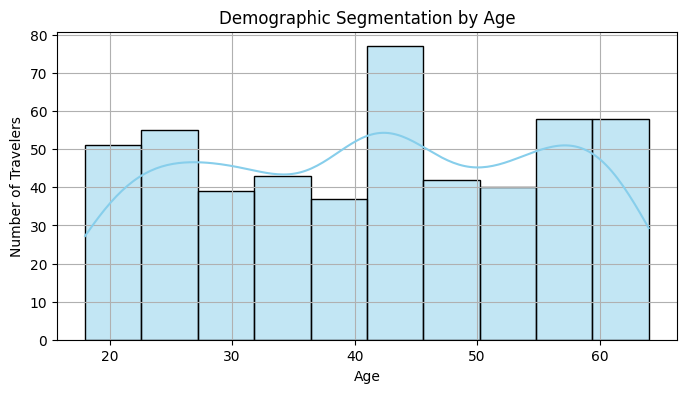

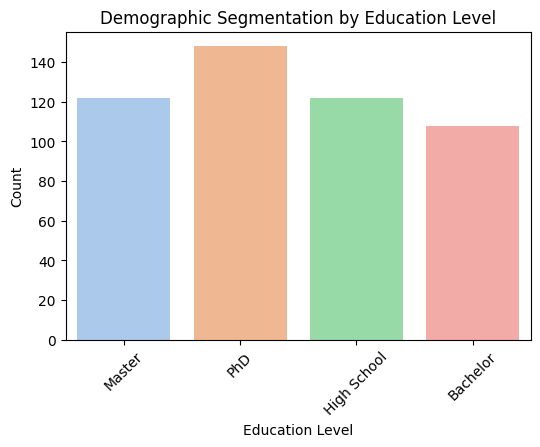

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age segmentation
plt.figure(figsize=(8, 4))
sns.histplot(data['Age'], bins=10, kde=True, color='skyblue')
plt.title('Demographic Segmentation by Age')
plt.xlabel('Age')
plt.ylabel('Number of Travelers')
plt.grid(True)
plt.show()

# Education Level
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='EducationLevel', palette='pastel')
plt.title('Demographic Segmentation by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


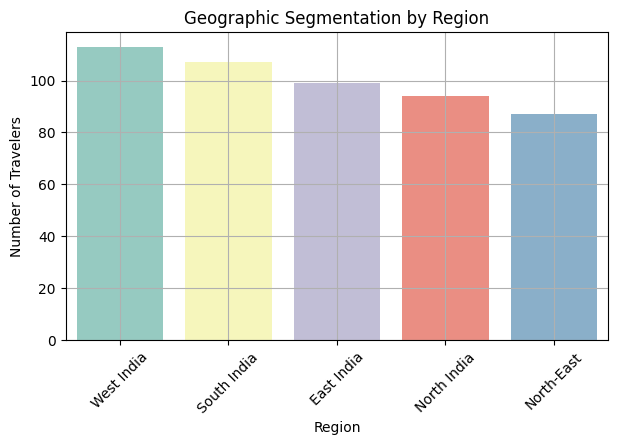

In [ ]:
#Geographicg Segmentation
plt.figure(figsize=(7, 4))
sns.countplot(data=data, x='Region', order=data['Region'].value_counts().index, palette='Set3')
plt.title('Geographic Segmentation by Region')
plt.xlabel('Region')
plt.ylabel('Number of Travelers')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


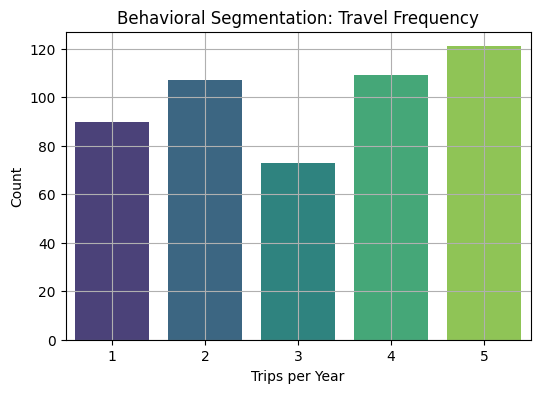

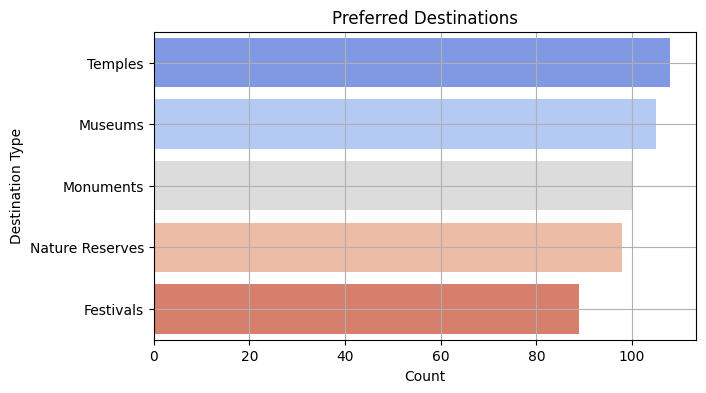

In [17]:
#Behavioral Segmentation
# Travel Frequency
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='TravelFrequency', palette='viridis')
plt.title('Behavioral Segmentation: Travel Frequency')
plt.xlabel('Trips per Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Preferred Destinations
plt.figure(figsize=(7, 4))
sns.countplot(data=data, y='PreferredDestinations', order=data['PreferredDestinations'].value_counts().index, palette='coolwarm')
plt.title('Preferred Destinations')
plt.xlabel('Count')
plt.ylabel('Destination Type')
plt.grid(True)
plt.show()


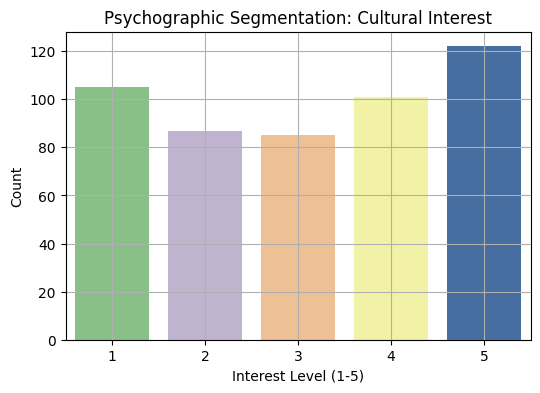

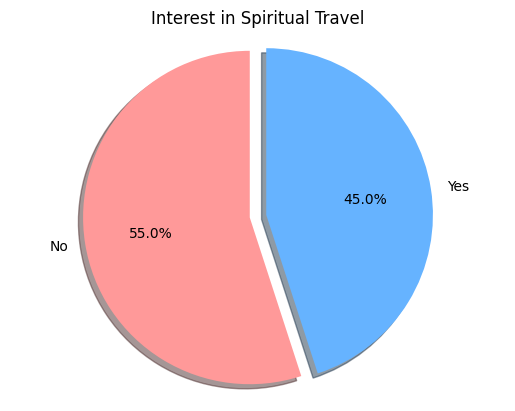

In [20]:
#Psychographic Segmentation
# Cultural Interest Level
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='CulturalInterest', palette='Accent')
plt.title('Psychographic Segmentation: Cultural Interest')
plt.xlabel('Interest Level (1-5)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Seeks Spirituality
spirituality = data['SeeksSpirituality'].value_counts()
labels = ['No', 'Yes']
plt.pie(spirituality, labels=labels, autopct='%.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, explode=[0, 0.1], shadow=True)
plt.title('Interest in Spiritual Travel')
plt.axis('equal')
plt.show()


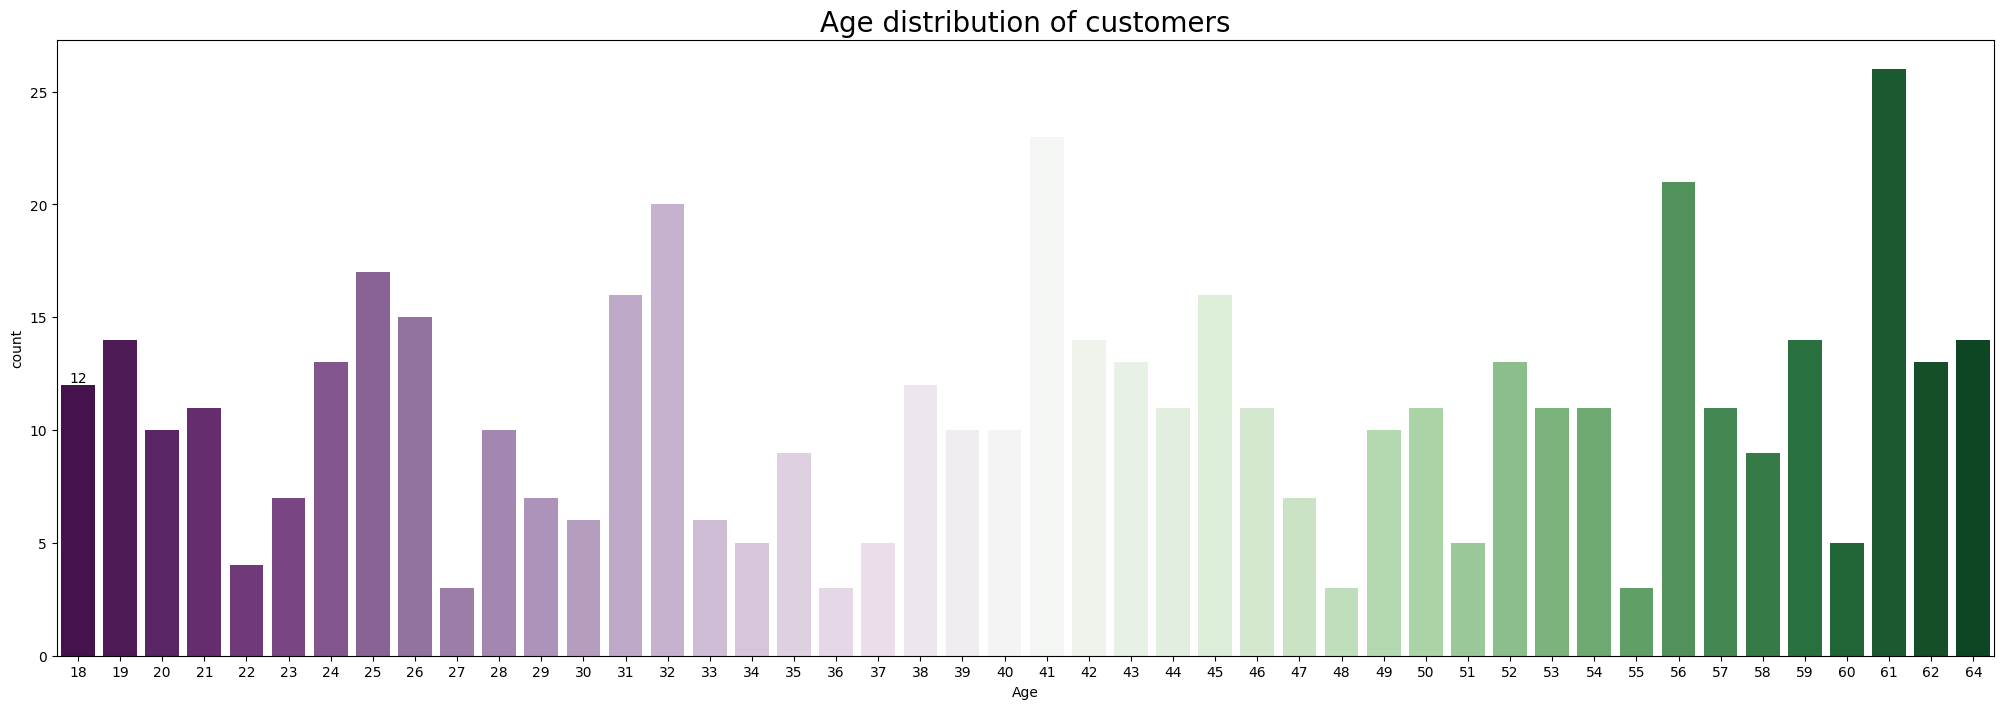

In [22]:
plt.rcParams['figure.figsize'] = (25, 8)
c = sns.countplot(x = data['Age'], palette = 'PRGn')
c.bar_label(c.containers[0])
plt.title('Age distribution of customers', fontsize = 20)
plt.show()

<Figure size 600x500 with 0 Axes>

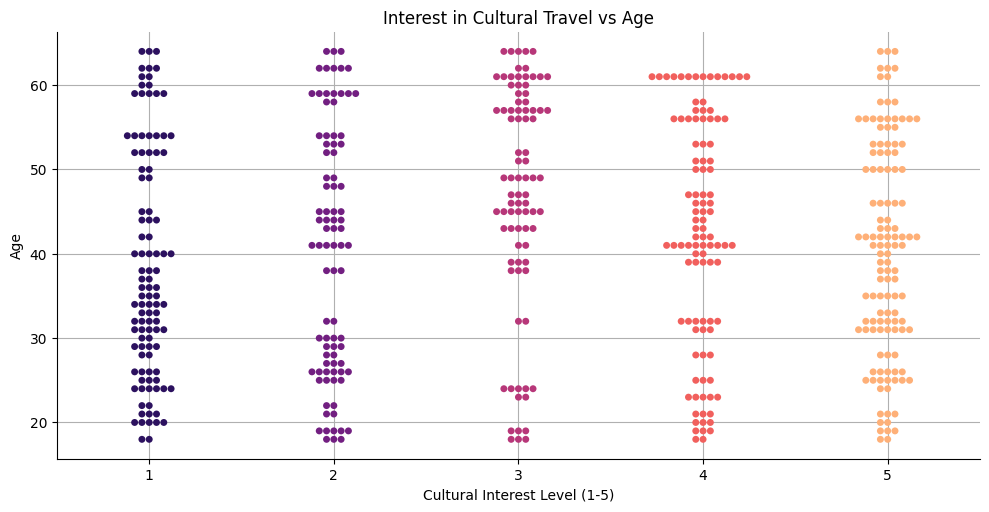

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting Cultural Interest w.r.t Age
plt.figure(figsize=(6, 5))
sns.catplot(data=data, x="CulturalInterest", y="Age", orient="v", height=5, aspect=2, palette="magma", kind="swarm")
plt.title('Interest in Cultural Travel vs Age')
plt.xlabel('Cultural Interest Level (1-5)')
plt.ylabel('Age')
plt.grid(True)
plt.show()


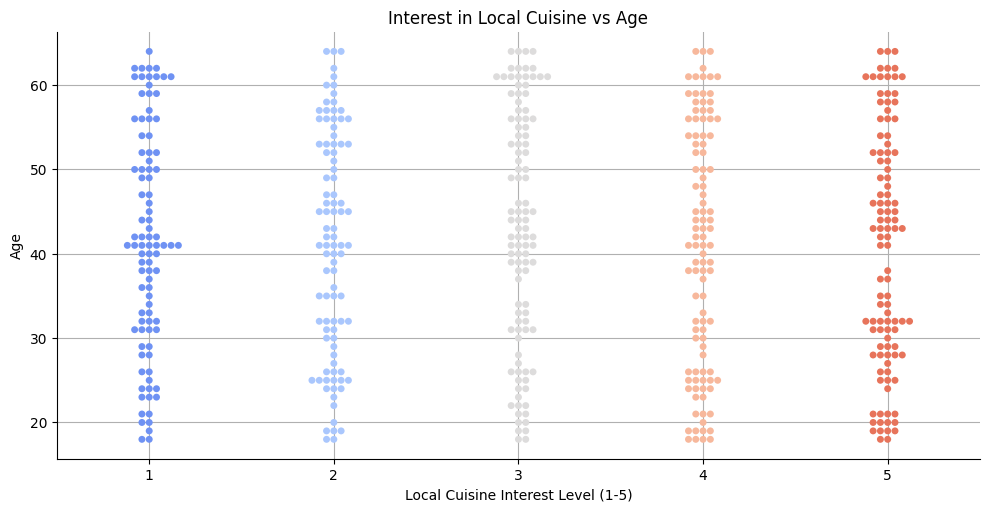

In [29]:
sns.catplot(data=data, x="LocalCuisineInterest", y="Age", orient="v", height=5, aspect=2, palette="coolwarm", kind="swarm")
plt.title('Interest in Local Cuisine vs Age')
plt.xlabel('Local Cuisine Interest Level (1-5)')
plt.ylabel('Age')
plt.grid(True)
plt.show()


In [30]:
#Data Preprocessing
data.dtypes

Age                            int64
Budget                         int64
TravelFrequency                int64
CulturalInterest               int64
PrefersLocal                   int64
TechSavvy                      int64
GroupType                      int64
SeeksSpirituality              int64
EcoFriendly                    int64
Region                        object
EducationLevel                object
LanguageProficiency            int64
PreferredDestinations         object
TravelPurpose                 object
TravelCompanion               object
InternetUsageHours             int64
CulturalEventParticipation     int64
SocialMediaInfluence           int64
HistoricalKnowledge            int64
LocalCuisineInterest           int64
dtype: object

In [32]:
# LabelEncoder will map 'Yes' to 1 and 'No' to 0

le = LabelEncoder()

cols=[
    "CulturalInterest",
    "PrefersLocal",
    "TechSavvy",
    "SeeksSpirituality",
    "EcoFriendly",
    "LanguageProficiency",
    "CulturalEventParticipation",
    "SocialMediaInfluence",
    "HistoricalKnowledge",
    "LocalCuisineInterest"
]
    
for i in cols:
    data[i] = le.fit_transform(data[i])


In [33]:
data

,Age,Budget,TravelFrequency,CulturalInterest,PrefersLocal,TechSavvy,GroupType,SeeksSpirituality,EcoFriendly,Region,EducationLevel,LanguageProficiency,PreferredDestinations,TravelPurpose,TravelCompanion,InternetUsageHours,CulturalEventParticipation,SocialMediaInfluence,HistoricalKnowledge,LocalCuisineInterest
0,56,49417,4,4,0,0,1,1,1,North-East,Master,4,Temples,Photography,Family,3,4,1,2,4
1,46,28938,2,4,1,1,1,1,0,East India,PhD,4,Nature Reserves,Adventure,Solo,3,0,0,4,4
2,32,28664,3,4,0,4,2,1,0,North-East,High School,0,Festivals,Leisure,Family,8,2,4,2,4
3,60,6636,4,2,0,2,4,1,1,South India,Master,2,Monuments,Adventure,Group Tour,8,3,3,2,2
4,25,25080,5,4,0,3,4,1,0,North India,Master,1,Temples,Education,Solo,8,0,0,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,7869,1,0,0,4,1,0,1,South India,Master,4,Nature Reserves,Photography,Solo,2,1,0,3,1
496,26,33643,2,1,0,4,4,0,1,West India,Master,1,Museums,Adventure,Family,9,4,2,3,3
497,41,29736,3,1,1,4,2,0,0,South India,PhD,1,Monuments,Education,Family,2,1,4,0,0
498,18,43467,4,1,1,3,2,0,0,North-East,High School,2,Festivals,Pilgrimage,Friends,8,1,0,3,3


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Budget'}>,
        <Axes: title={'center': 'TravelFrequency'}>,
        <Axes: title={'center': 'CulturalInterest'}>],
       [<Axes: title={'center': 'PrefersLocal'}>,
        <Axes: title={'center': 'TechSavvy'}>,
        <Axes: title={'center': 'GroupType'}>,
        <Axes: title={'center': 'SeeksSpirituality'}>],
       [<Axes: title={'center': 'EcoFriendly'}>,
        <Axes: title={'center': 'LanguageProficiency'}>,
        <Axes: title={'center': 'InternetUsageHours'}>,
        <Axes: title={'center': 'CulturalEventParticipation'}>],
       [<Axes: title={'center': 'SocialMediaInfluence'}>,
        <Axes: title={'center': 'HistoricalKnowledge'}>,
        <Axes: title={'center': 'LocalCuisineInterest'}>, <Axes: >]],
      dtype=object)

<Figure size 2500x2500 with 0 Axes>

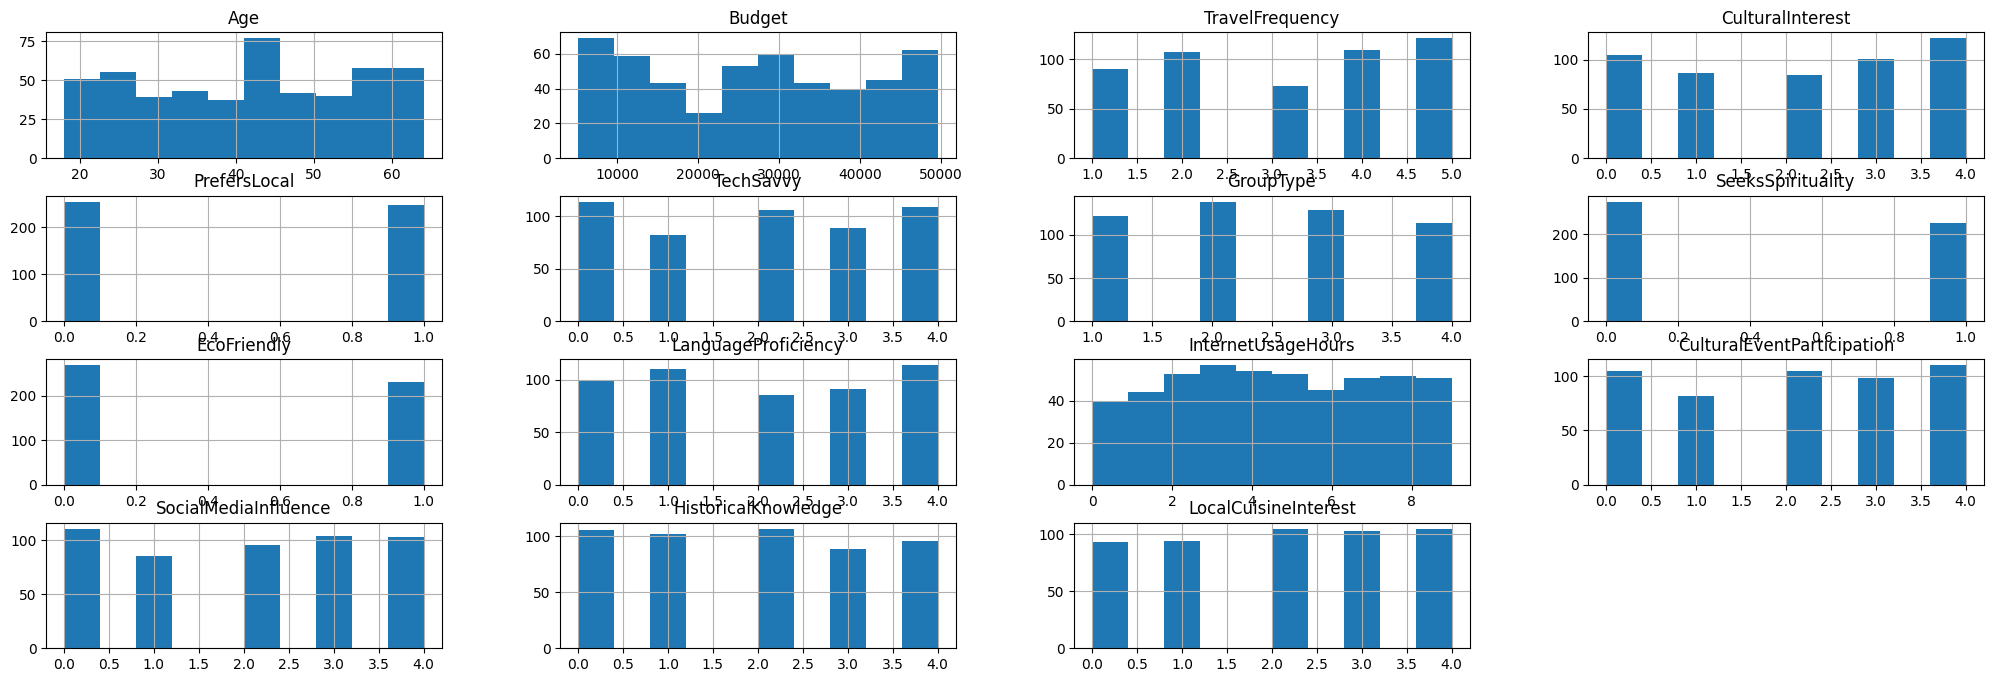

In [34]:
plt.figure(figsize=(25,25))
data.hist()


In [35]:
#Applying PCA
x = data.loc[:, cols]
x

,CulturalInterest,PrefersLocal,TechSavvy,SeeksSpirituality,EcoFriendly,LanguageProficiency,CulturalEventParticipation,SocialMediaInfluence,HistoricalKnowledge,LocalCuisineInterest
0,4,0,0,1,1,4,4,1,2,4
1,4,1,1,1,0,4,0,0,4,4
2,4,0,4,1,0,0,2,4,2,4
3,2,0,2,1,1,2,3,3,2,2
4,4,0,3,1,0,1,0,0,3,4
...,...,...,...,...,...,...,...,...,...,...
495,0,0,4,0,1,4,1,0,3,1
496,1,0,4,0,1,1,4,2,3,3
497,1,1,4,0,0,1,1,4,0,0
498,1,1,3,0,0,2,1,0,3,3


In [38]:
# applying scaling and PCA

pca_data = preprocessing.scale(x)

pca = PCA(n_components = 10)
pc = pca.fit_transform(x)

names = ["pc1", "pc2", "pc3", "pc4", "pc5", "pc6", "pc7", "pc8", "pc9", "pc10"]

pf = pd.DataFrame(data = pc, columns = names)
pf

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10
0,1.041624,-1.381289,3.172020,-0.892973,-0.835185,-0.256179,-2.352844,0.324296,0.684655,0.412517
1,1.069778,0.553791,3.798899,1.916037,-0.585555,-2.187483,0.111092,0.045268,-0.733667,0.548284
2,-0.926036,1.987041,0.081058,0.010598,3.470475,0.149700,-1.614602,0.840474,-0.056455,-0.177444
3,0.161188,-0.313071,-0.074738,-0.633947,0.560255,1.015553,-0.158544,0.596645,0.641232,0.272348
4,-1.311449,1.350486,1.704590,1.894698,0.916111,-2.767010,-0.519308,0.823311,-0.215567,-0.119856
...,...,...,...,...,...,...,...,...,...,...
495,-0.592597,-0.739430,-0.310269,3.469682,-1.970746,0.775533,1.599863,0.019324,0.478128,-0.390456
496,-1.794167,-1.622740,-0.351436,1.020741,1.813154,1.260103,-0.431157,-0.121725,0.759095,-0.370288
497,-0.311432,2.059198,-3.569524,-0.043228,0.150508,1.425108,0.624714,-0.314959,-0.584277,-0.279447
498,-0.763154,-0.813174,0.163677,2.465060,-0.013721,-1.263065,0.558618,-0.523917,-0.673631,-0.190699


In [39]:
# Standard deviation

std_dev = []
for i in names:
    std_dev.append(np.std(pf[i]))
    
print("Standard Deviation :\n", np.array(std_dev))


Standard Deviation :
 [1.53513374 1.52181432 1.48476531 1.44672521 1.42310594 1.36281701
 1.31378181 0.53427143 0.49470823 0.43361523]


In [40]:
# variance (from PC1 to PC11)

pov = pca.explained_variance_ratio_
print("Proportion of Variance : \n", pov)


Proportion of Variance : 
 [0.15406045 0.15139867 0.14411672 0.13682669 0.13239549 0.12141541
 0.11283536 0.01866047 0.01599915 0.01229158]


In [41]:
# cumsum Variance

cp = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Proportion : \n", cp)


Cumulative Proportion : 
 [0.15406045 0.30545912 0.44957584 0.58640253 0.71879802 0.84021343
 0.95304879 0.97170926 0.98770842 1.        ]


In [43]:
components = pca.components_
num_pc = pca.n_components_
pc_name = ["PC" + str(i) for i in range(1, num_pc + 1)]
loadings_df = pd.DataFrame

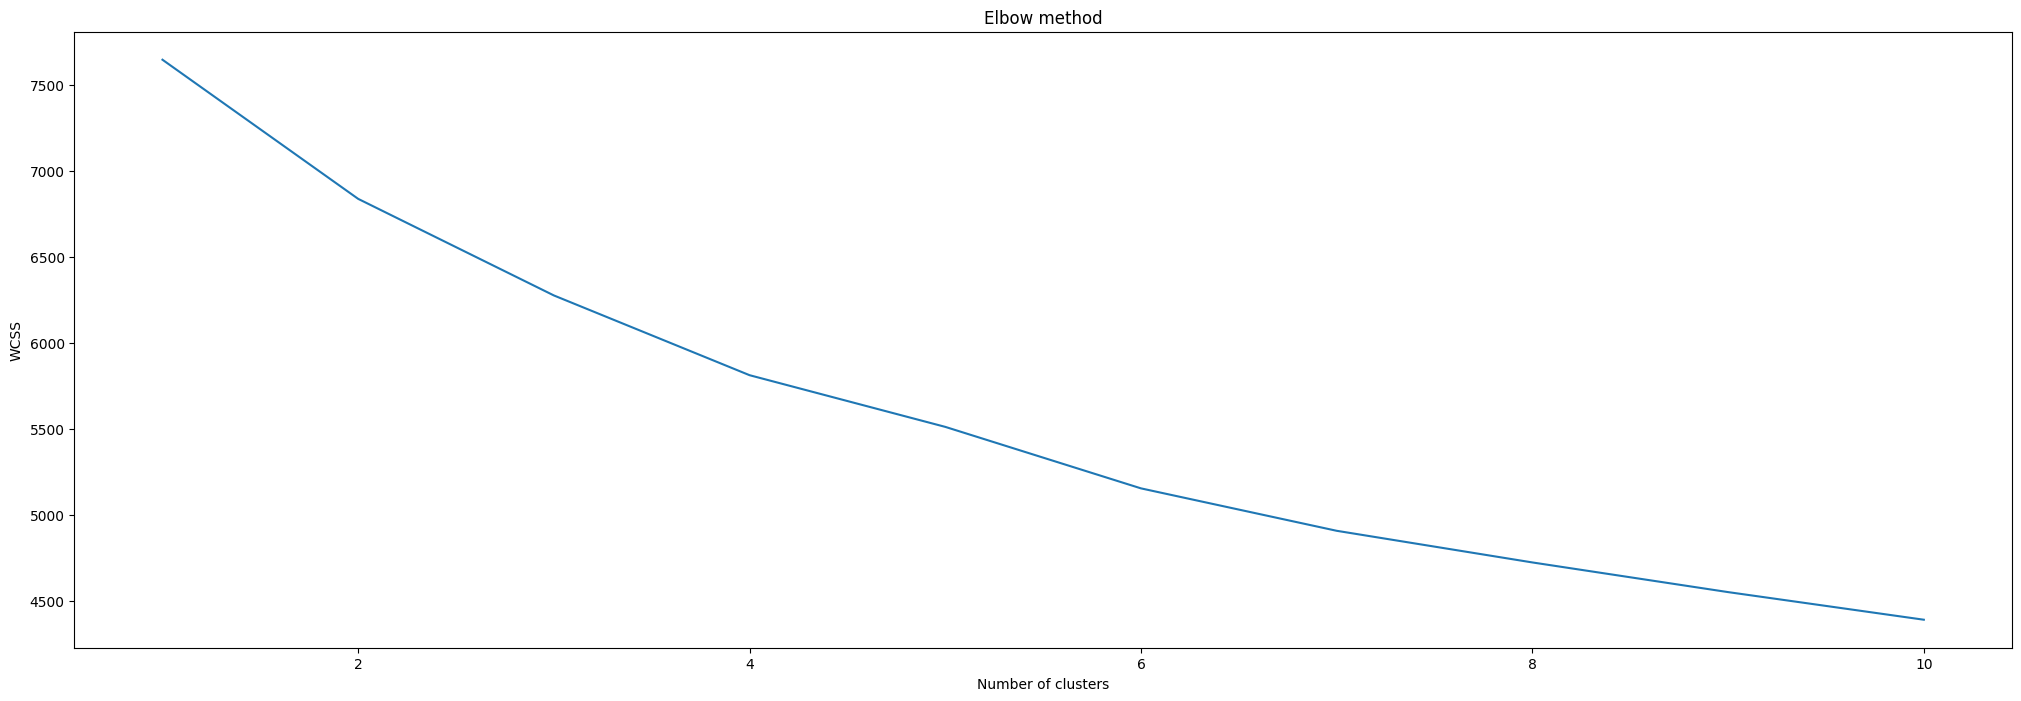

In [44]:
#Applying Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(pf)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [45]:
#K-means clustering 

kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 0).fit(x)
data['cluster_num'] = kmeans.labels_
print (kmeans.labels_)
print (kmeans.inertia_) 
print(kmeans.n_iter_)
print(kmeans.cluster_centers_)

[3 1 1 3 1 0 0 0 3 0 0 2 1 1 0 1 0 0 3 2 1 1 3 0 0 3 2 1 0 1 3 1 0 3 1 1 3
 3 3 0 0 2 0 1 0 0 1 0 1 3 1 2 2 2 3 3 3 1 3 2 3 3 0 2 3 2 0 2 3 0 0 3 0 3
 0 2 2 2 1 1 0 1 1 1 2 0 2 2 2 0 1 2 1 2 0 2 3 3 0 2 2 2 0 1 2 3 0 2 1 1 3
 3 1 2 1 1 1 0 1 2 2 3 0 0 1 0 2 2 2 0 3 1 0 3 3 3 3 3 0 0 1 0 1 2 2 3 1 1
 3 1 0 3 0 1 3 1 3 2 0 3 0 3 1 2 0 1 3 1 1 0 2 1 1 3 1 3 1 2 0 1 1 0 1 3 3
 0 2 0 2 1 2 1 3 0 2 1 0 0 2 3 2 0 1 3 0 3 2 3 3 3 2 0 1 0 2 1 2 1 3 0 1 2
 1 0 1 3 2 2 2 3 3 3 0 1 1 3 0 3 2 0 1 0 2 0 2 3 2 1 0 2 0 3 1 0 1 3 3 3 0
 2 1 3 3 2 3 1 3 2 3 1 1 3 2 2 0 1 3 2 1 0 2 1 0 1 2 1 1 2 2 2 3 2 0 3 2 3
 1 1 3 1 0 0 0 1 2 1 1 2 3 1 2 3 3 0 3 3 0 2 1 2 2 3 2 0 2 0 0 0 1 2 2 3 1
 2 3 3 3 0 2 2 0 0 3 1 3 2 3 0 0 0 0 3 2 1 0 1 1 0 2 1 1 0 3 0 3 1 0 3 1 0
 2 3 3 2 1 1 3 0 2 0 1 3 3 1 1 0 0 1 2 1 2 1 2 1 0 3 0 2 3 3 0 0 2 3 2 1 1
 3 1 2 1 1 2 1 2 2 0 1 3 1 3 0 3 3 1 1 0 0 0 1 3 3 0 3 0 3 3 3 3 0 0 0 2 2
 2 1 2 0 3 2 2 1 3 0 3 3 1 3 0 2 2 1 3 0 3 1 0 0 1 1 1 1 1 0 0 0 2 0 0 3 0
 0 3 3 2 0 3 1 2 1 1 2 1 

In [46]:
Counter(kmeans.labels_)

Counter({np.int32(1): 134,
         np.int32(0): 127,
         np.int32(3): 126,
         np.int32(2): 113})

In [48]:
# correlation coefficient between original variables and the component

loadings = pca.components_
num_pc = pca.n_components_  # Corrected attribute
pc_list = ["PC" + str(i) for i in list(range(1, num_pc + 1))]
loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings)))
loadings_df['variable'] = x.columns.values
loadings_df = loadings_df.set_index('variable')
loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
variable,,,,,,,,,,
CulturalInterest,-0.225863,0.623244,0.591603,-0.302655,-0.022440,-0.077794,-0.328646,-0.023374,0.047386,0.040043
PrefersLocal,0.017005,0.033764,-0.050714,0.012546,0.033652,-0.014977,0.013554,-0.646356,-0.418557,0.633510
TechSavvy,-0.491220,0.297932,-0.217020,0.626353,0.170912,0.410715,-0.176793,0.036139,-0.006750,0.004355
SeeksSpirituality,0.031784,-0.020014,0.010795,-0.013373,0.022831,-0.013212,-0.019004,0.737030,-0.141324,0.658826
EcoFriendly,0.026955,-0.014224,-0.037266,0.047395,-0.020944,0.001319,0.035647,-0.184196,0.894510,0.399561
LanguageProficiency,0.511978,-0.015466,0.366679,0.356617,-0.517874,0.437836,-0.120495,-0.016290,-0.035087,0.010009
CulturalEventParticipation,-0.327497,-0.571227,0.134790,-0.383904,0.039917,0.505432,-0.374221,-0.044748,0.014913,0.039662
SocialMediaInfluence,0.472363,0.319354,-0.174617,-0.298595,0.536468,0.508848,0.083547,0.010923,0.023292,-0.029487
HistoricalKnowledge,-0.154151,-0.188198,0.610946,0.191647,0.360127,0.102427,0.624743,-0.010538,-0.007781,0.013313


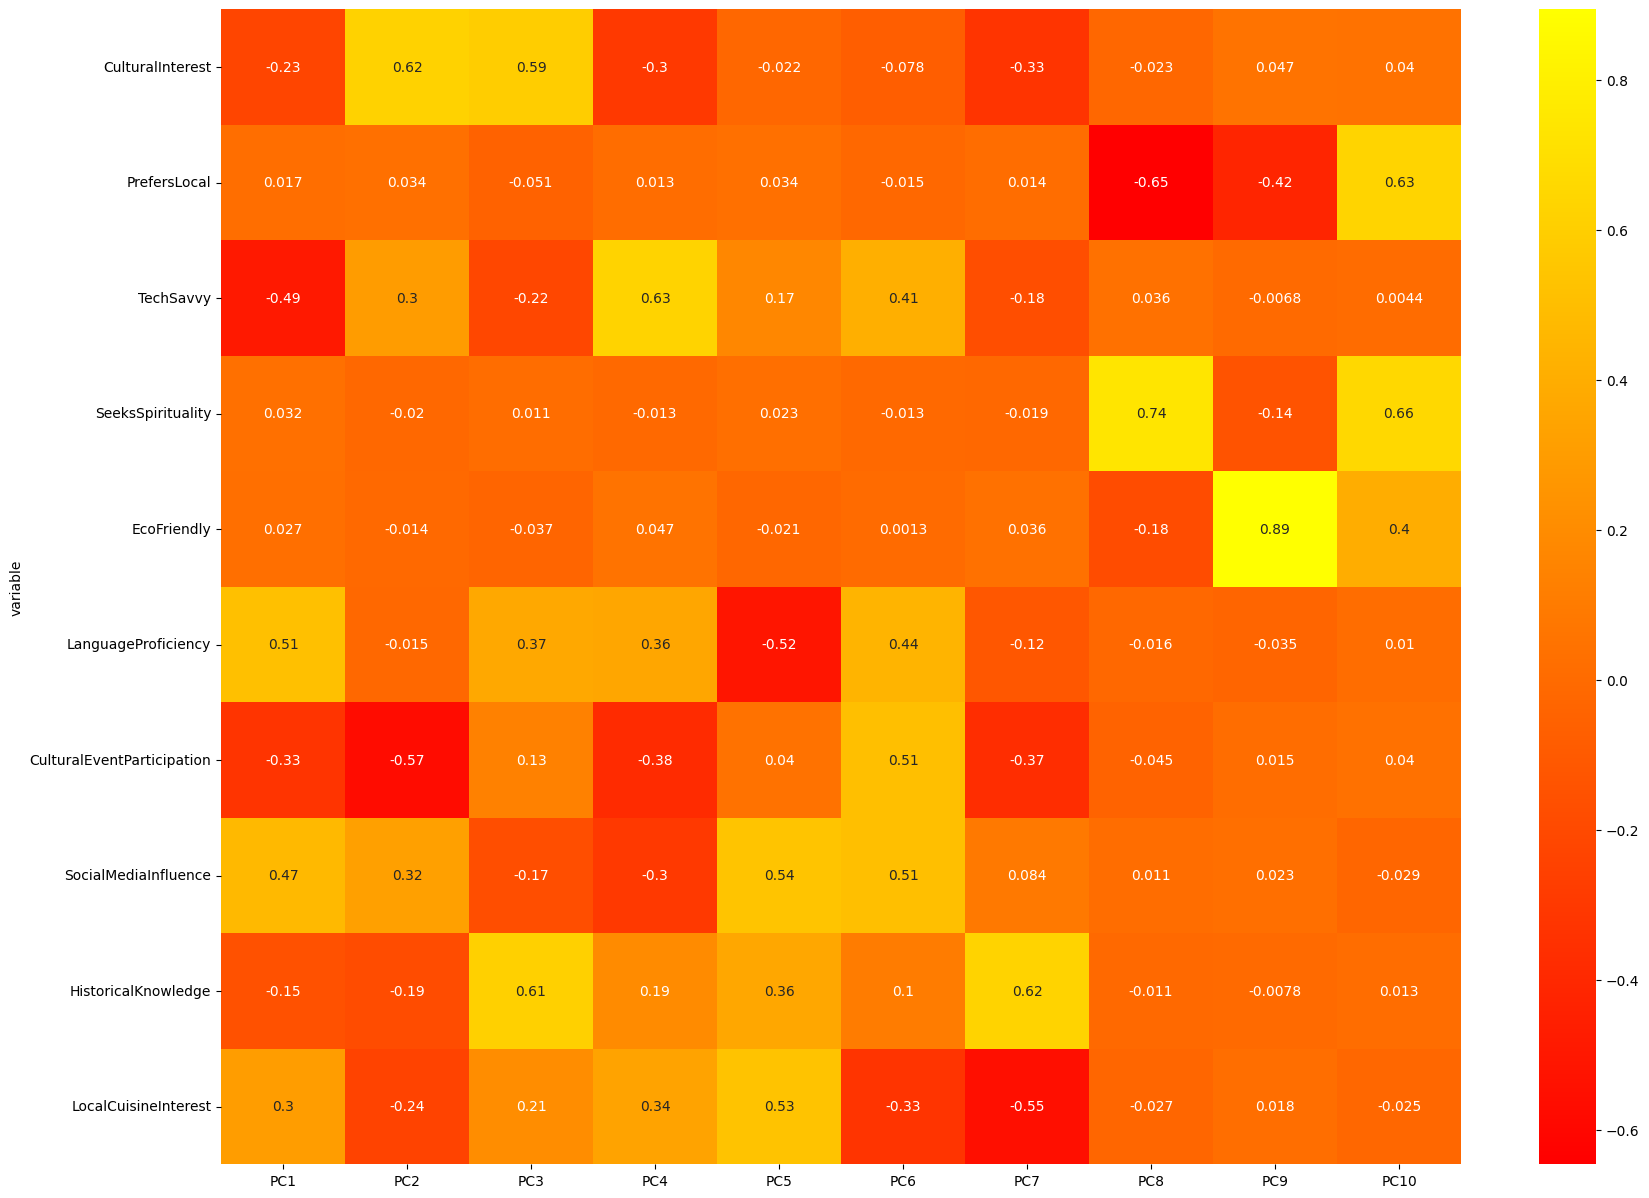

In [49]:
# correlation matrix plot for loadings 
plt.rcParams['figure.figsize'] = (20,15)
ax = sns.heatmap(loadings_df, annot=True, cmap='autumn')
plt.show()

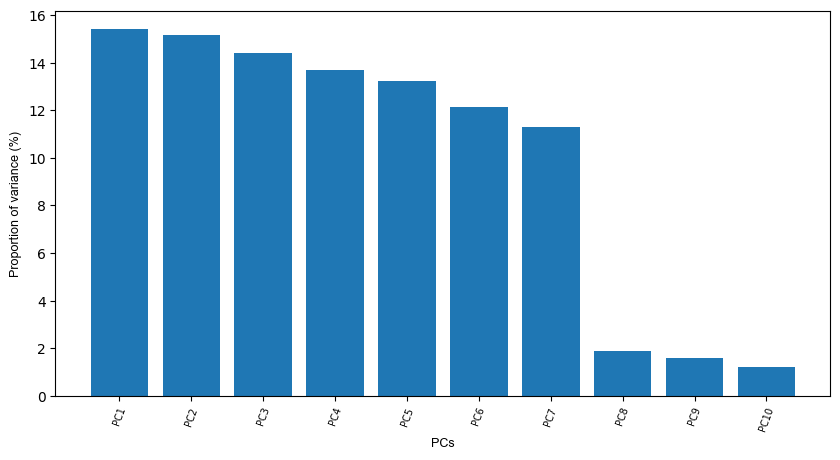

In [50]:
#Scree plot (Elbow test)- PCA

cluster.screeplot(obj = [pc_list, pca.explained_variance_ratio_], show = True, dim = (10,5))
pca_scores = PCA().fit_transform(x)

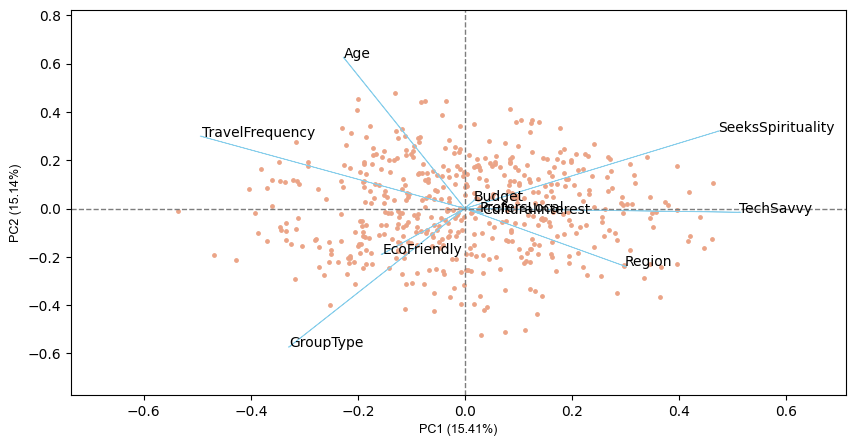

In [51]:
# get 2D biplot
cluster.biplot(cscore = pca_scores, loadings = loadings, labels = data.columns.values, var1 = round(pca.explained_variance_ratio_[0]*100, 2),
    var2 = round(pca.explained_variance_ratio_[1] * 100, 2), show = True, dim = (10,5))

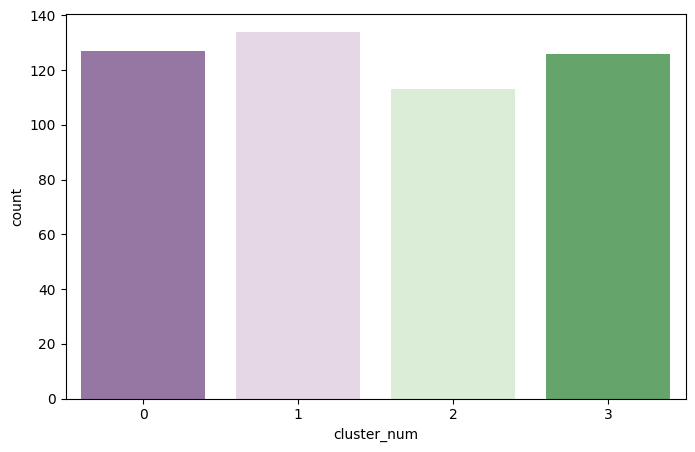

In [52]:
plt.figure(figsize=(8,5))
sns.countplot(x = data["cluster_num"], palette = 'PRGn')
plt.show()

In [53]:
data1 = pd.get_dummies(data, prefix = ['cluster_num'], columns = ['cluster_num'])

In [54]:
data1

,Age,Budget,TravelFrequency,CulturalInterest,PrefersLocal,TechSavvy,GroupType,SeeksSpirituality,EcoFriendly,Region,...,TravelCompanion,InternetUsageHours,CulturalEventParticipation,SocialMediaInfluence,HistoricalKnowledge,LocalCuisineInterest,cluster_num_0,cluster_num_1,cluster_num_2,cluster_num_3
0,56,49417,4,4,0,0,1,1,1,North-East,...,Family,3,4,1,2,4,False,False,False,True
1,46,28938,2,4,1,1,1,1,0,East India,...,Solo,3,0,0,4,4,False,True,False,False
2,32,28664,3,4,0,4,2,1,0,North-East,...,Family,8,2,4,2,4,False,True,False,False
3,60,6636,4,2,0,2,4,1,1,South India,...,Group Tour,8,3,3,2,2,False,False,False,True
4,25,25080,5,4,0,3,4,1,0,North India,...,Solo,8,0,0,3,4,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,7869,1,0,0,4,1,0,1,South India,...,Solo,2,1,0,3,1,False,False,False,True
496,26,33643,2,1,0,4,4,0,1,West India,...,Family,9,4,2,3,3,True,False,False,False
497,41,29736,3,1,1,4,2,0,0,South India,...,Family,2,1,4,0,0,False,False,True,False
498,18,43467,4,1,1,3,2,0,0,North-East,...,Friends,8,1,0,3,3,False,True,False,False


In [56]:
#Region

result=[]
for i in cols:
    Region = data.groupby(['cluster_num'])[i].mean()
    Region = Region.to_frame().reset_index()
    result.append(Region)

In [57]:
for i in range(len(result)):
    print(pd.DataFrame(result[i]))


   cluster_num  CulturalInterest
0            0          2.440945
1            1          1.671642
2            2          3.176991
3            3          1.230159
   cluster_num  PrefersLocal
0            0      0.464567
1            1      0.537313
2            2      0.522124
3            3      0.444444
   cluster_num  TechSavvy
0            0   2.212598
1            1   2.044776
2            2   2.238938
3            3   1.500000
   cluster_num  SeeksSpirituality
0            0           0.488189
1            1           0.440299
2            2           0.398230
3            3           0.468254
   cluster_num  EcoFriendly
0            0     0.377953
1            1     0.485075
2            2     0.424779
3            3     0.555556
   cluster_num  LanguageProficiency
0            0             0.598425
1            1             1.589552
2            2             3.035398
3            3             3.007937
   cluster_num  CulturalEventParticipation
0            0             

In [60]:
data1 = pd.get_dummies(data, prefix = ['TravelFrequency'], columns = ['TravelFrequency'])

In [61]:
data1

,Age,Budget,CulturalInterest,PrefersLocal,TechSavvy,GroupType,SeeksSpirituality,EcoFriendly,Region,EducationLevel,...,CulturalEventParticipation,SocialMediaInfluence,HistoricalKnowledge,LocalCuisineInterest,cluster_num,TravelFrequency_1,TravelFrequency_2,TravelFrequency_3,TravelFrequency_4,TravelFrequency_5
0,56,49417,4,0,0,1,1,1,North-East,Master,...,4,1,2,4,3,False,False,False,True,False
1,46,28938,4,1,1,1,1,0,East India,PhD,...,0,0,4,4,1,False,True,False,False,False
2,32,28664,4,0,4,2,1,0,North-East,High School,...,2,4,2,4,1,False,False,True,False,False
3,60,6636,2,0,2,4,1,1,South India,Master,...,3,3,2,2,3,False,False,False,True,False
4,25,25080,4,0,3,4,1,0,North India,Master,...,0,0,3,4,1,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,7869,0,0,4,1,0,1,South India,Master,...,1,0,3,1,3,True,False,False,False,False
496,26,33643,1,0,4,4,0,1,West India,Master,...,4,2,3,3,0,False,True,False,False,False
497,41,29736,1,1,4,2,0,0,South India,PhD,...,1,4,0,0,2,False,False,True,False,False
498,18,43467,1,1,3,2,0,0,North-East,High School,...,1,0,3,3,1,False,False,False,True,False


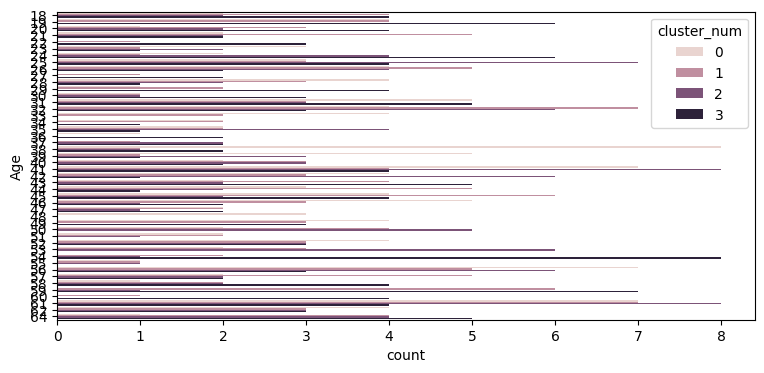

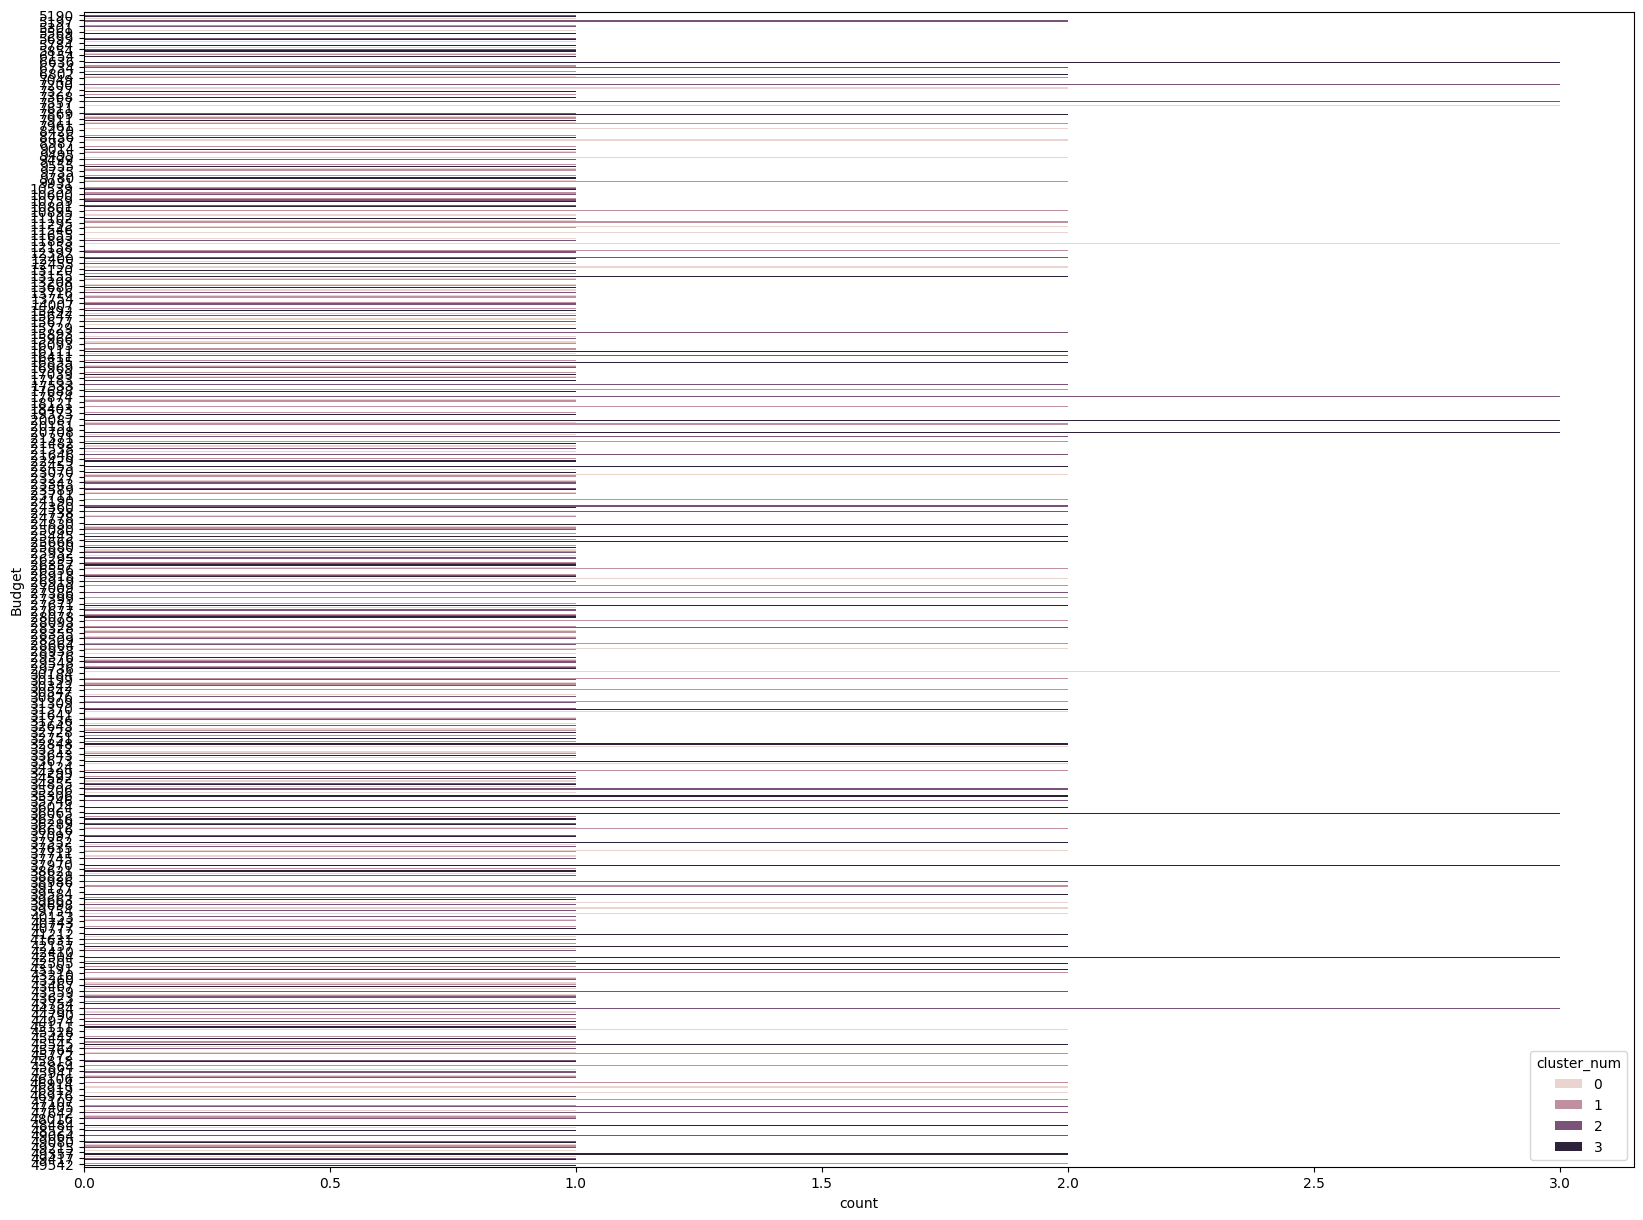

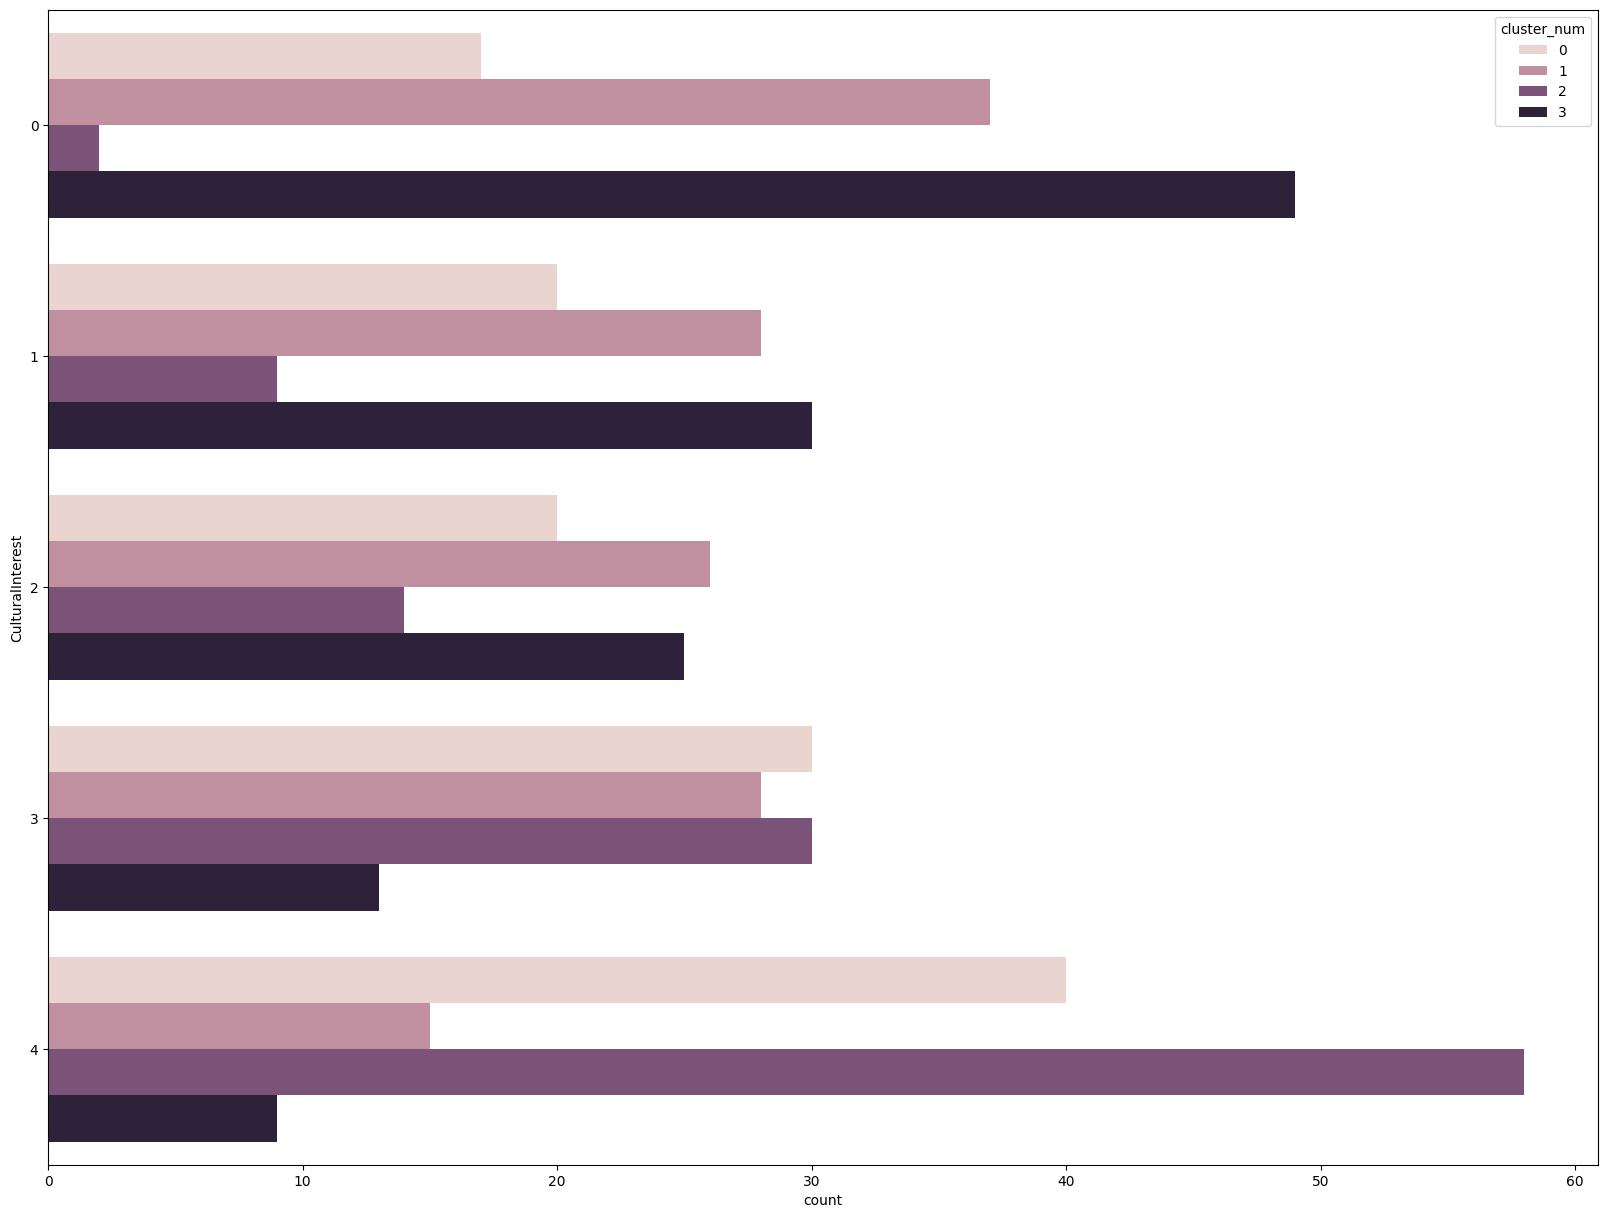

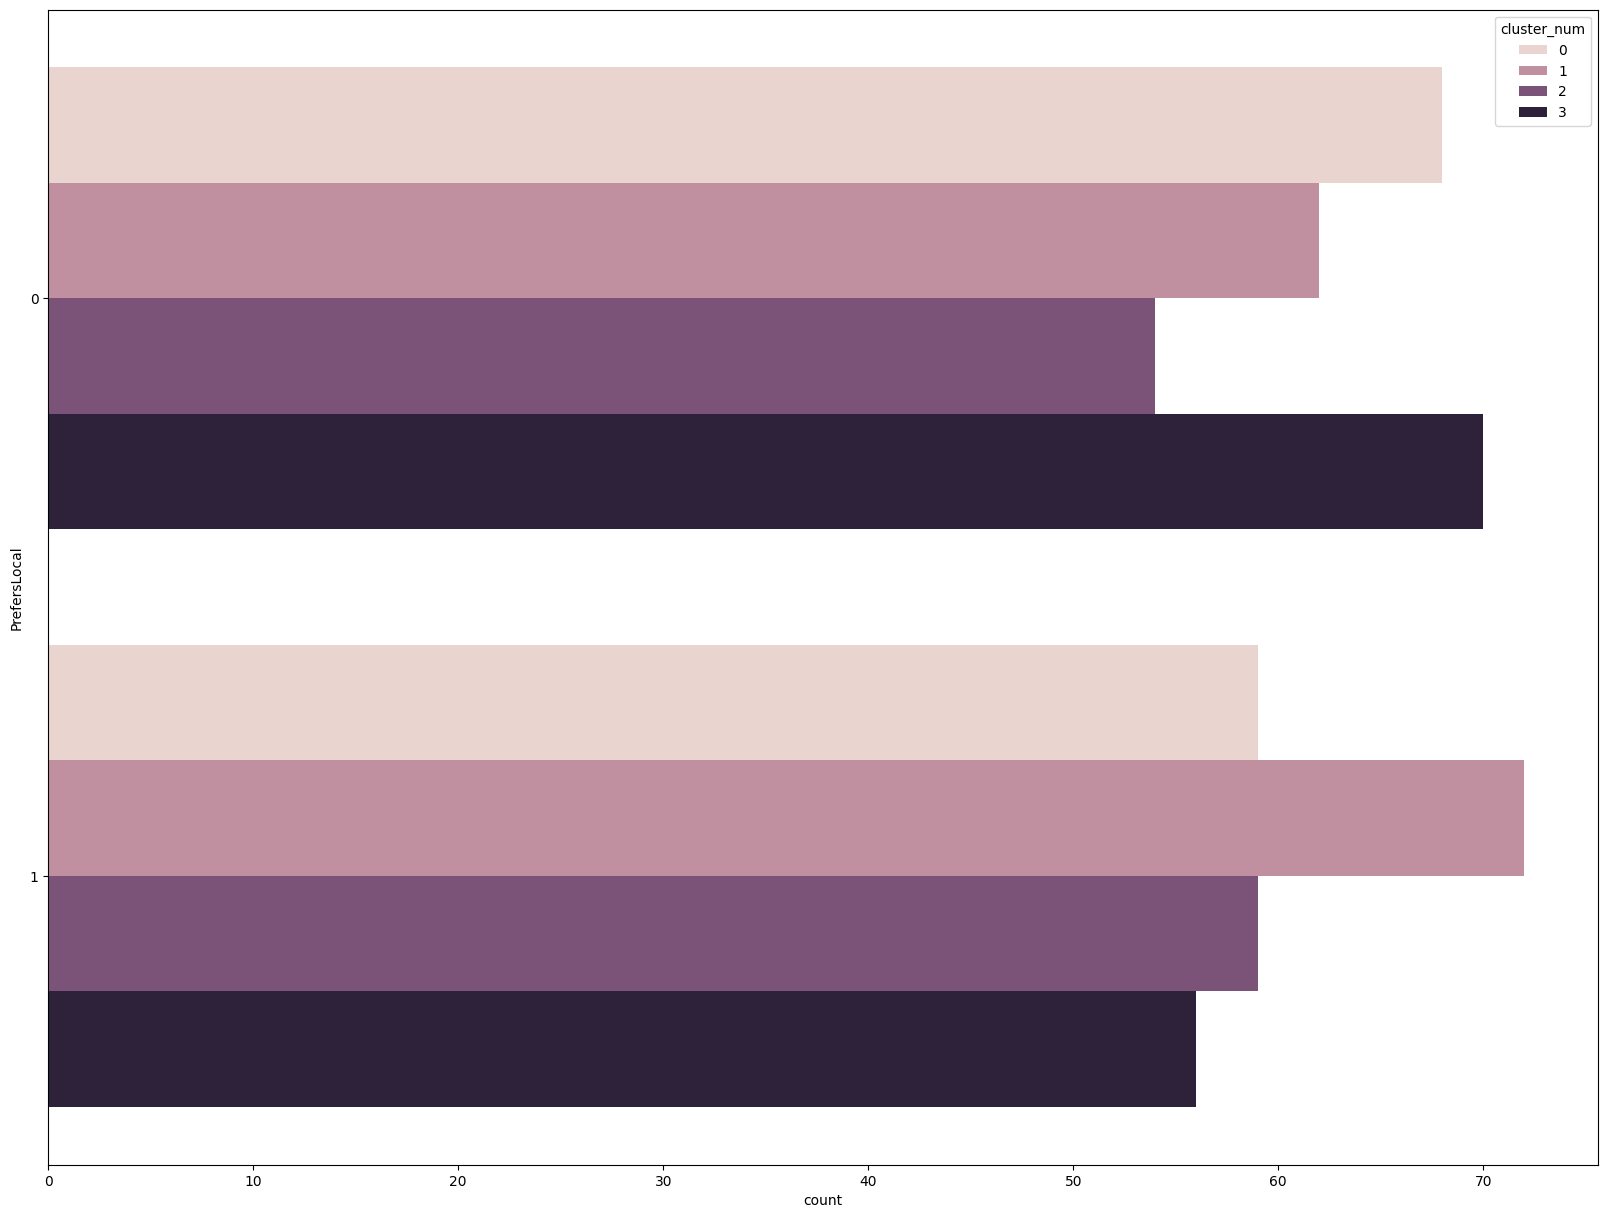

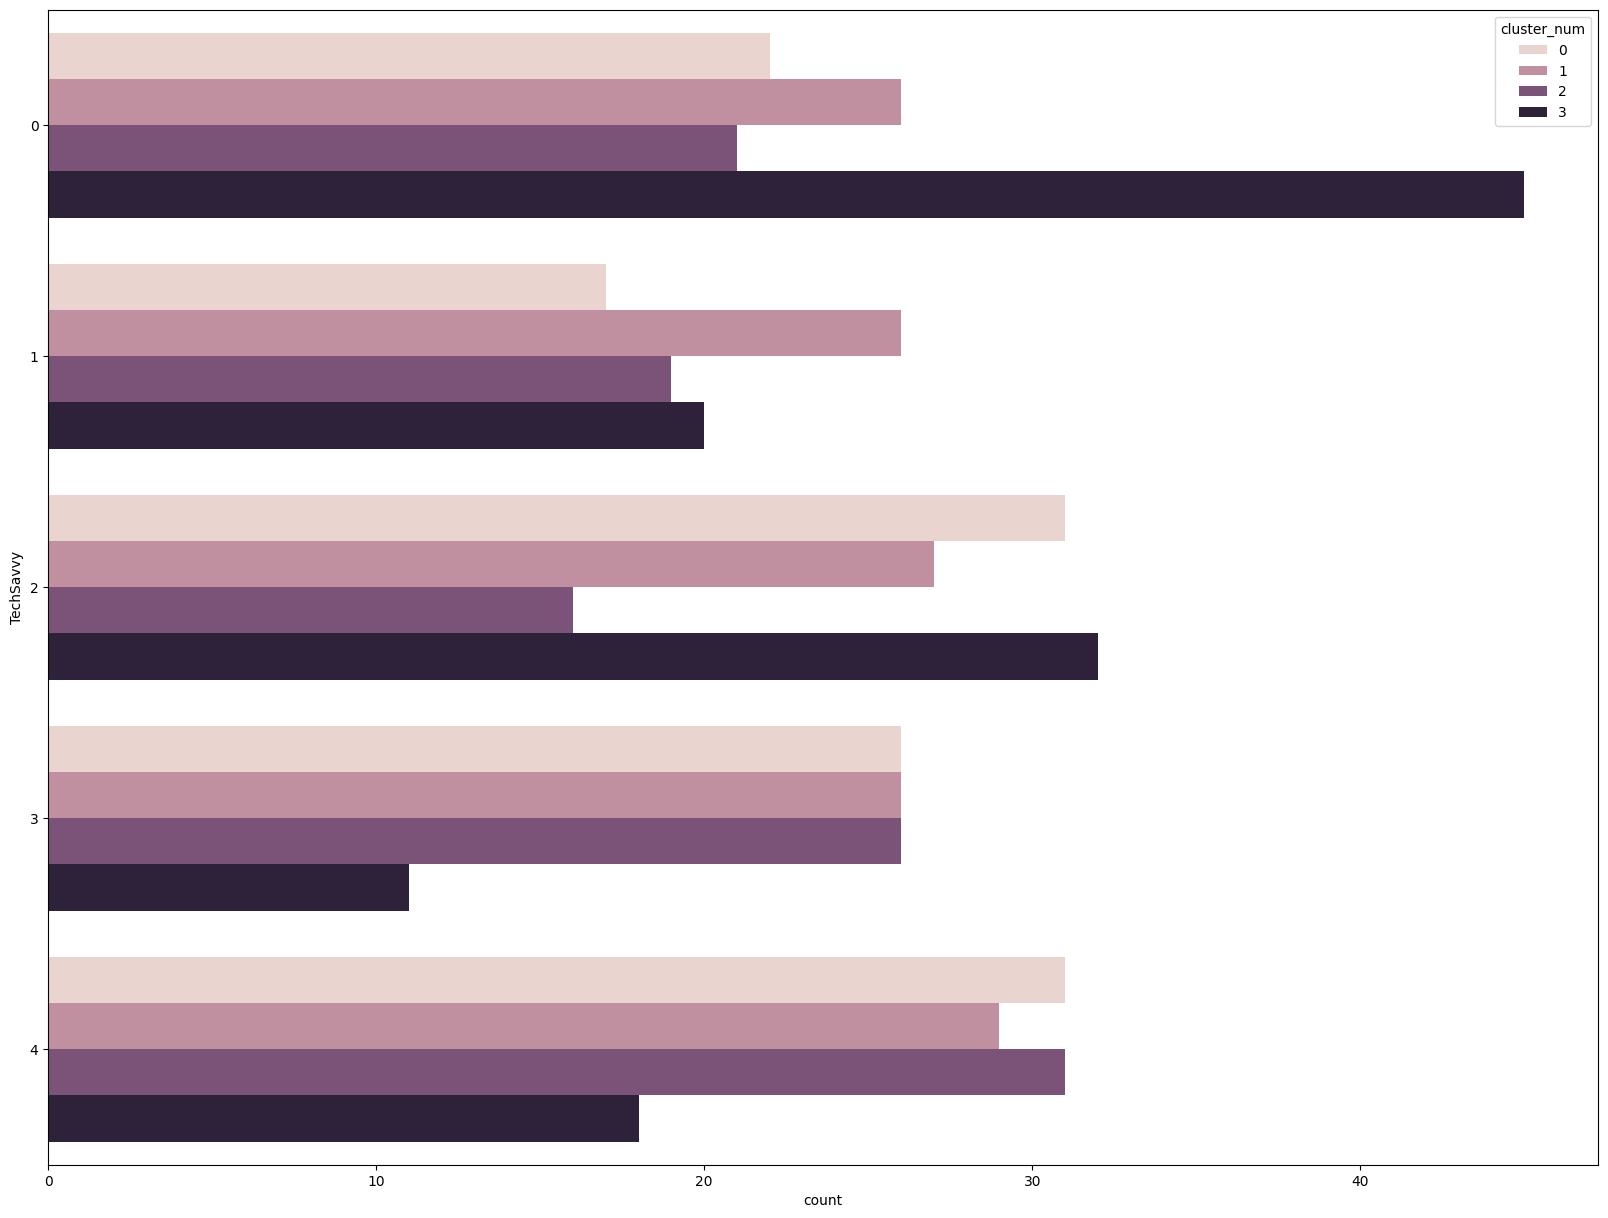

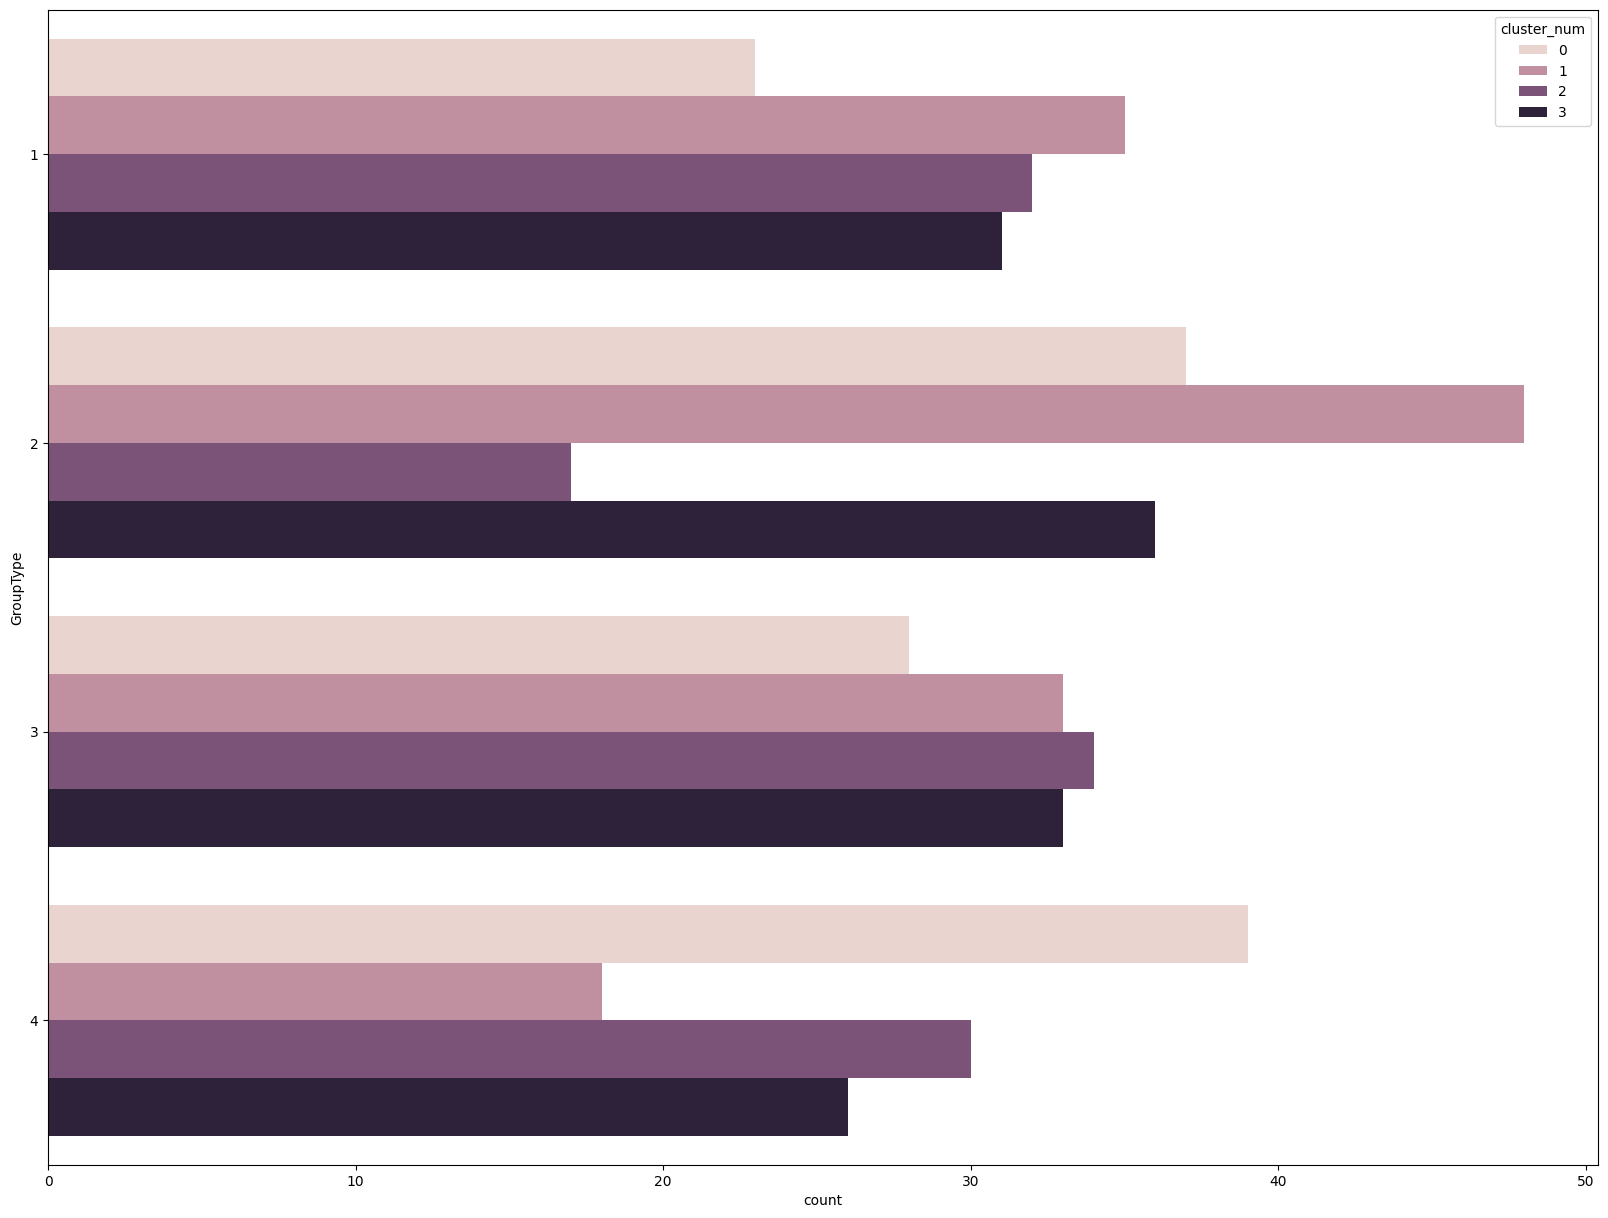

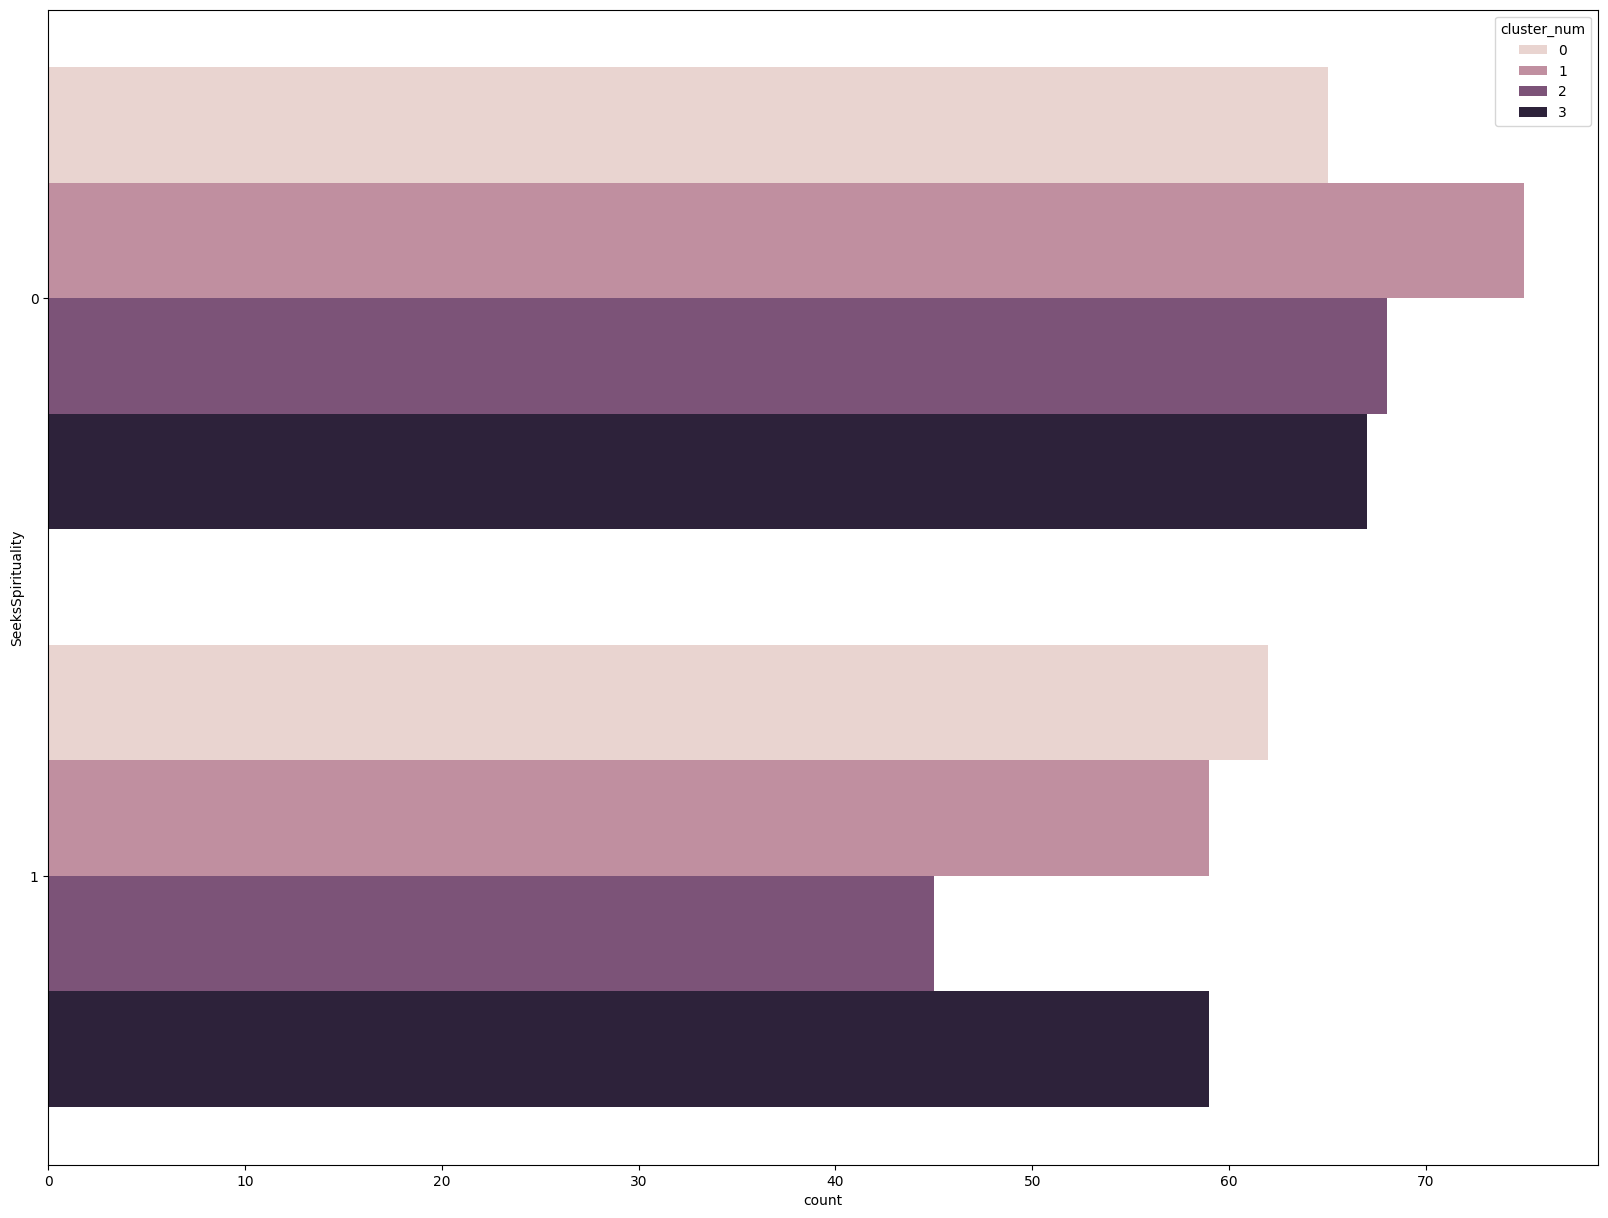

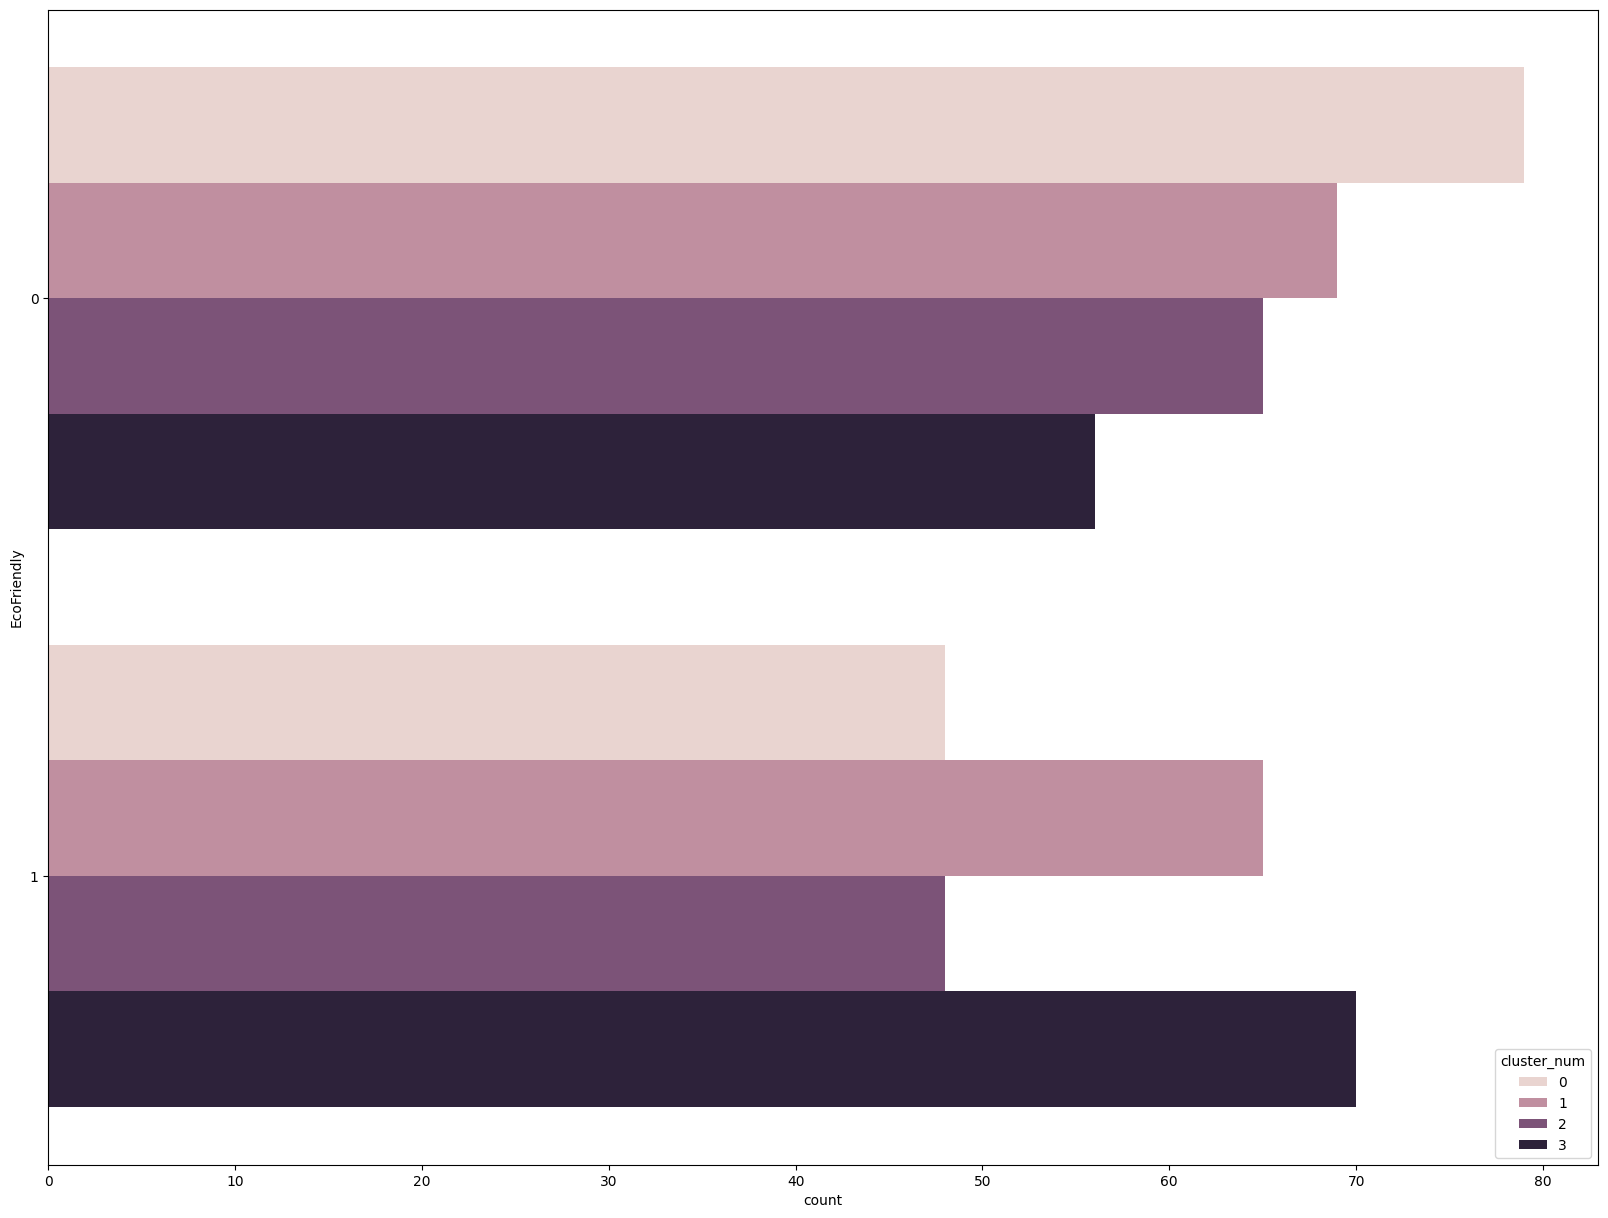

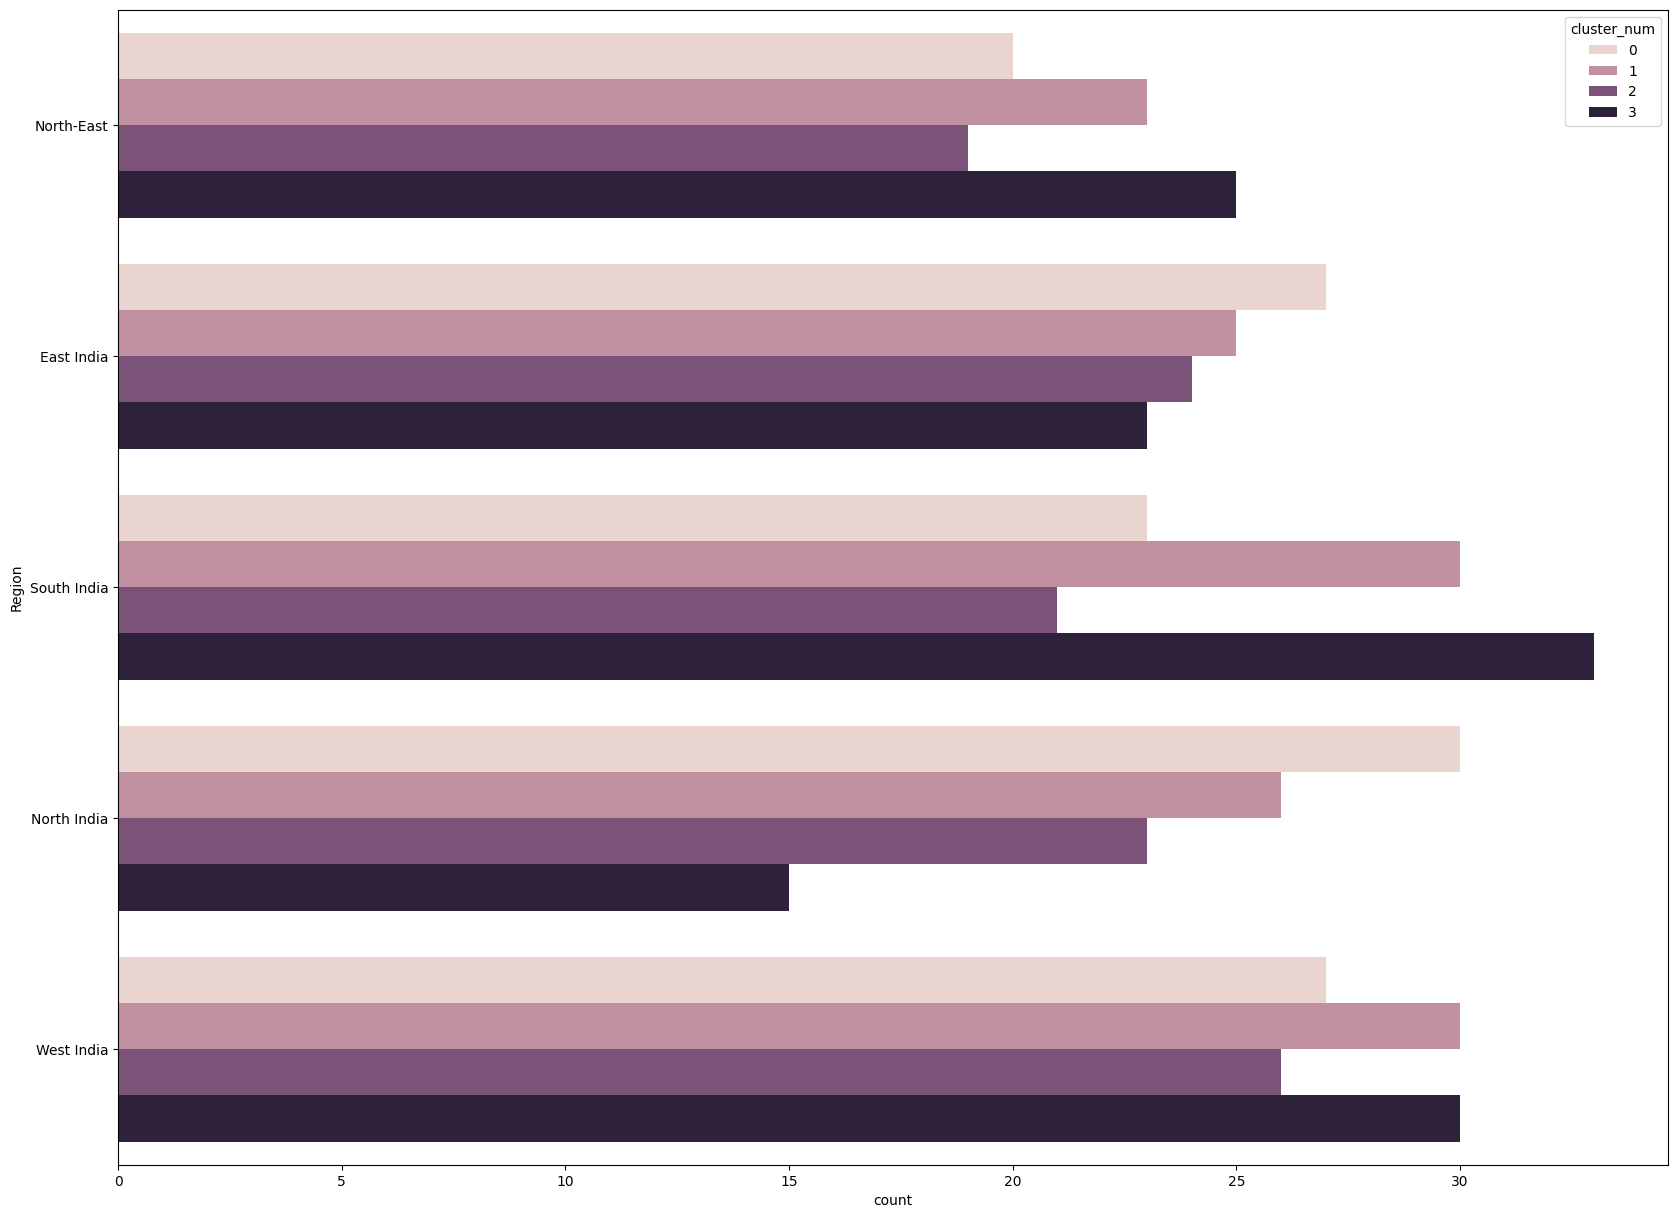

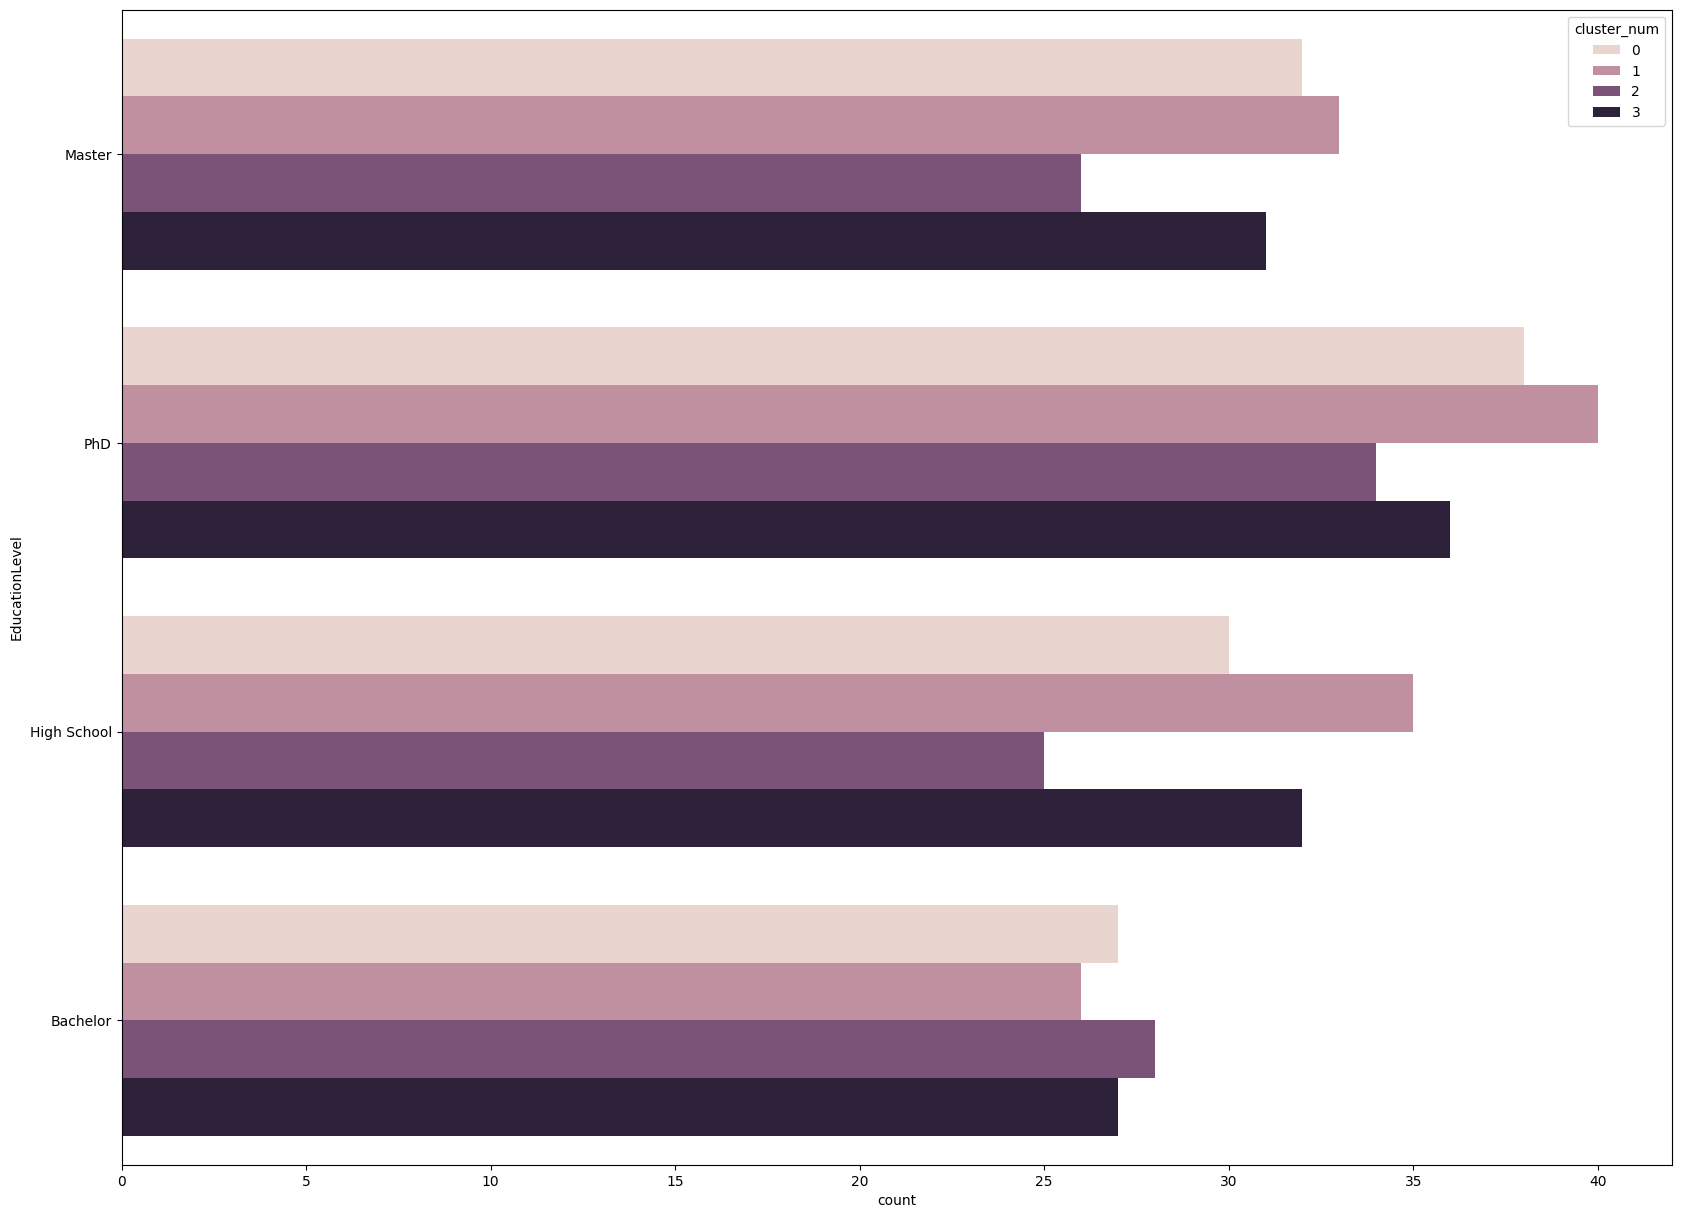

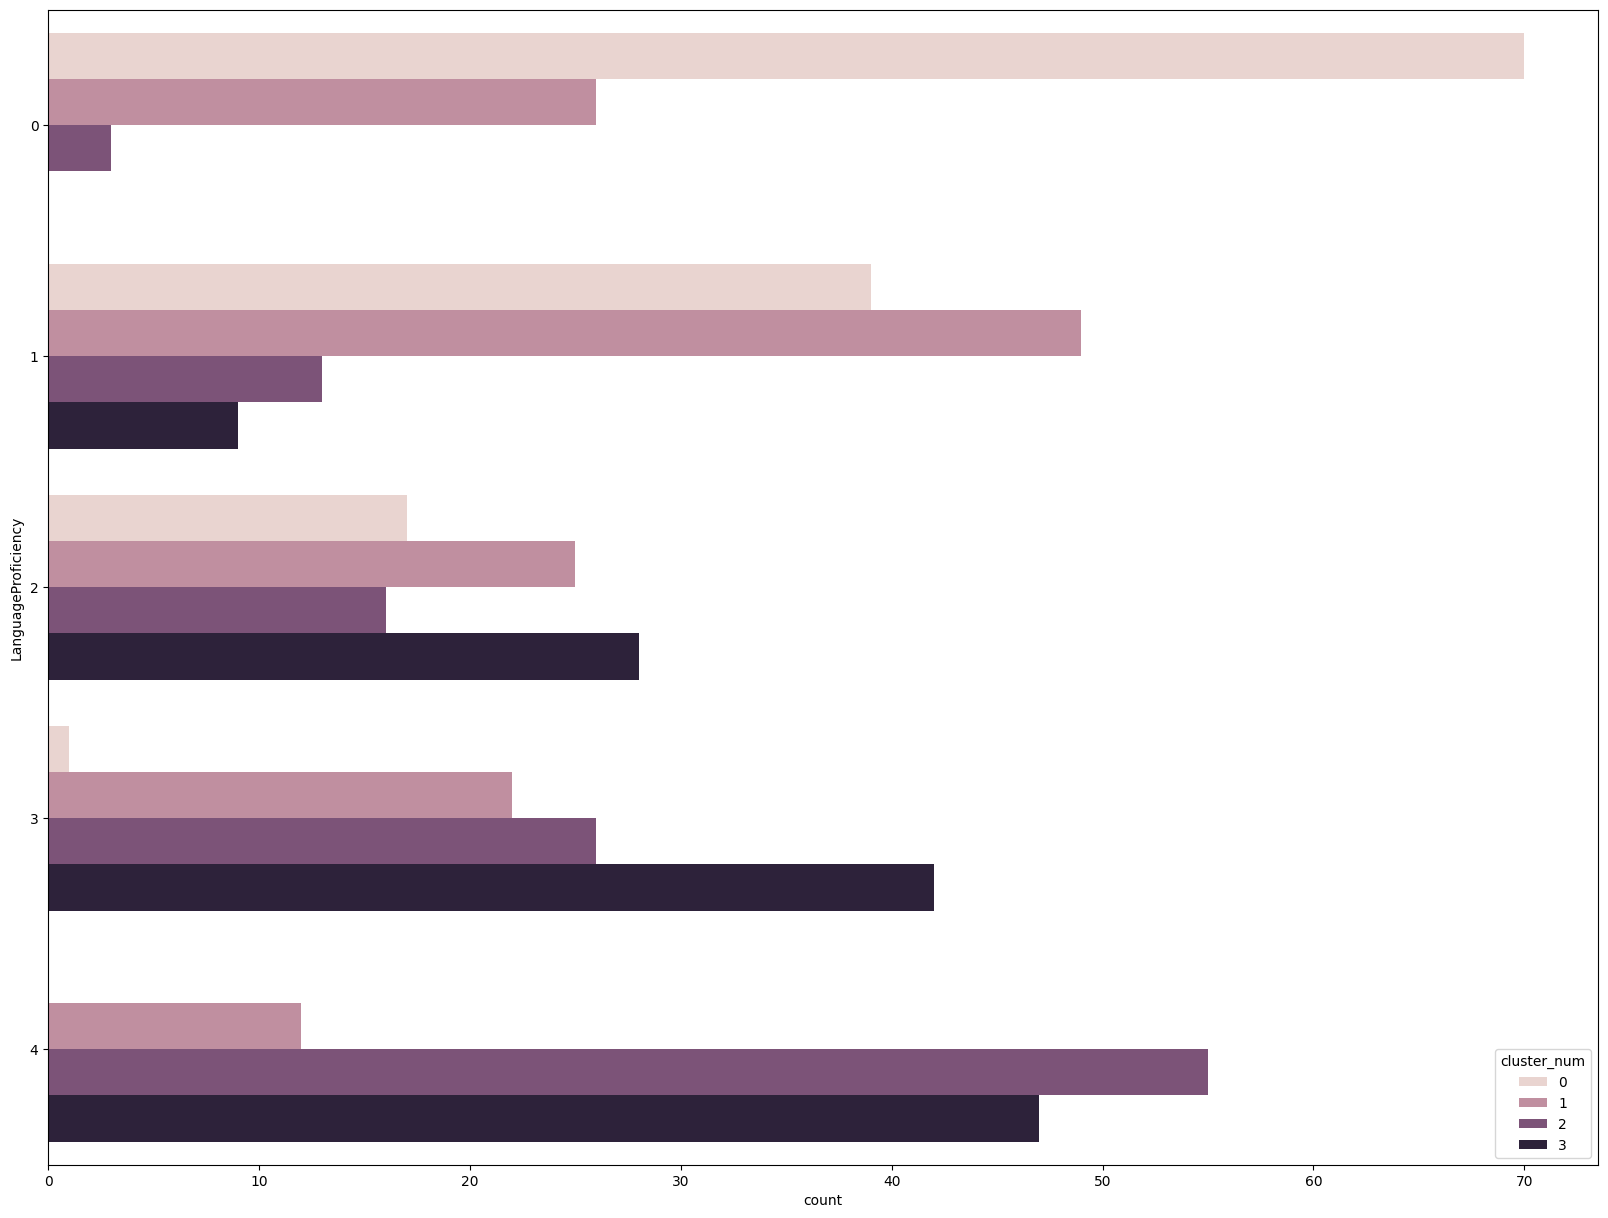

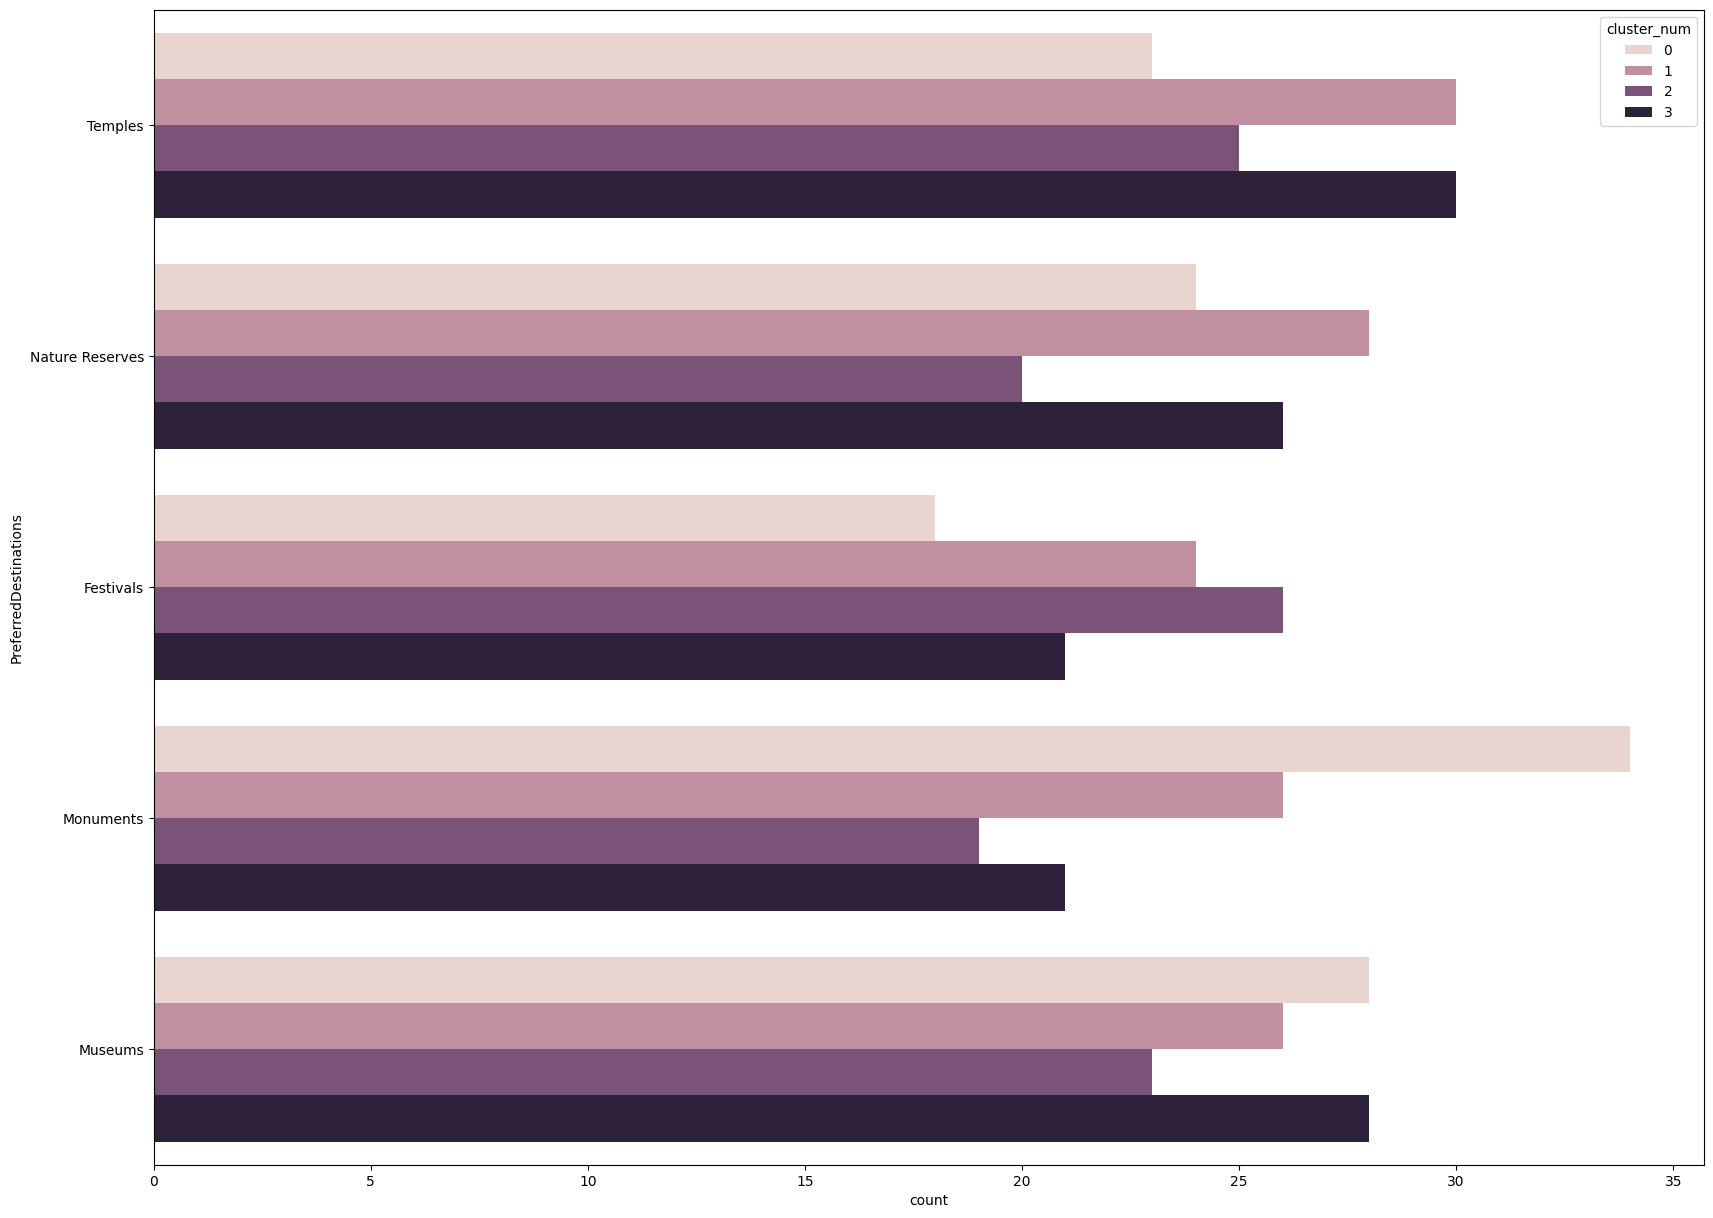

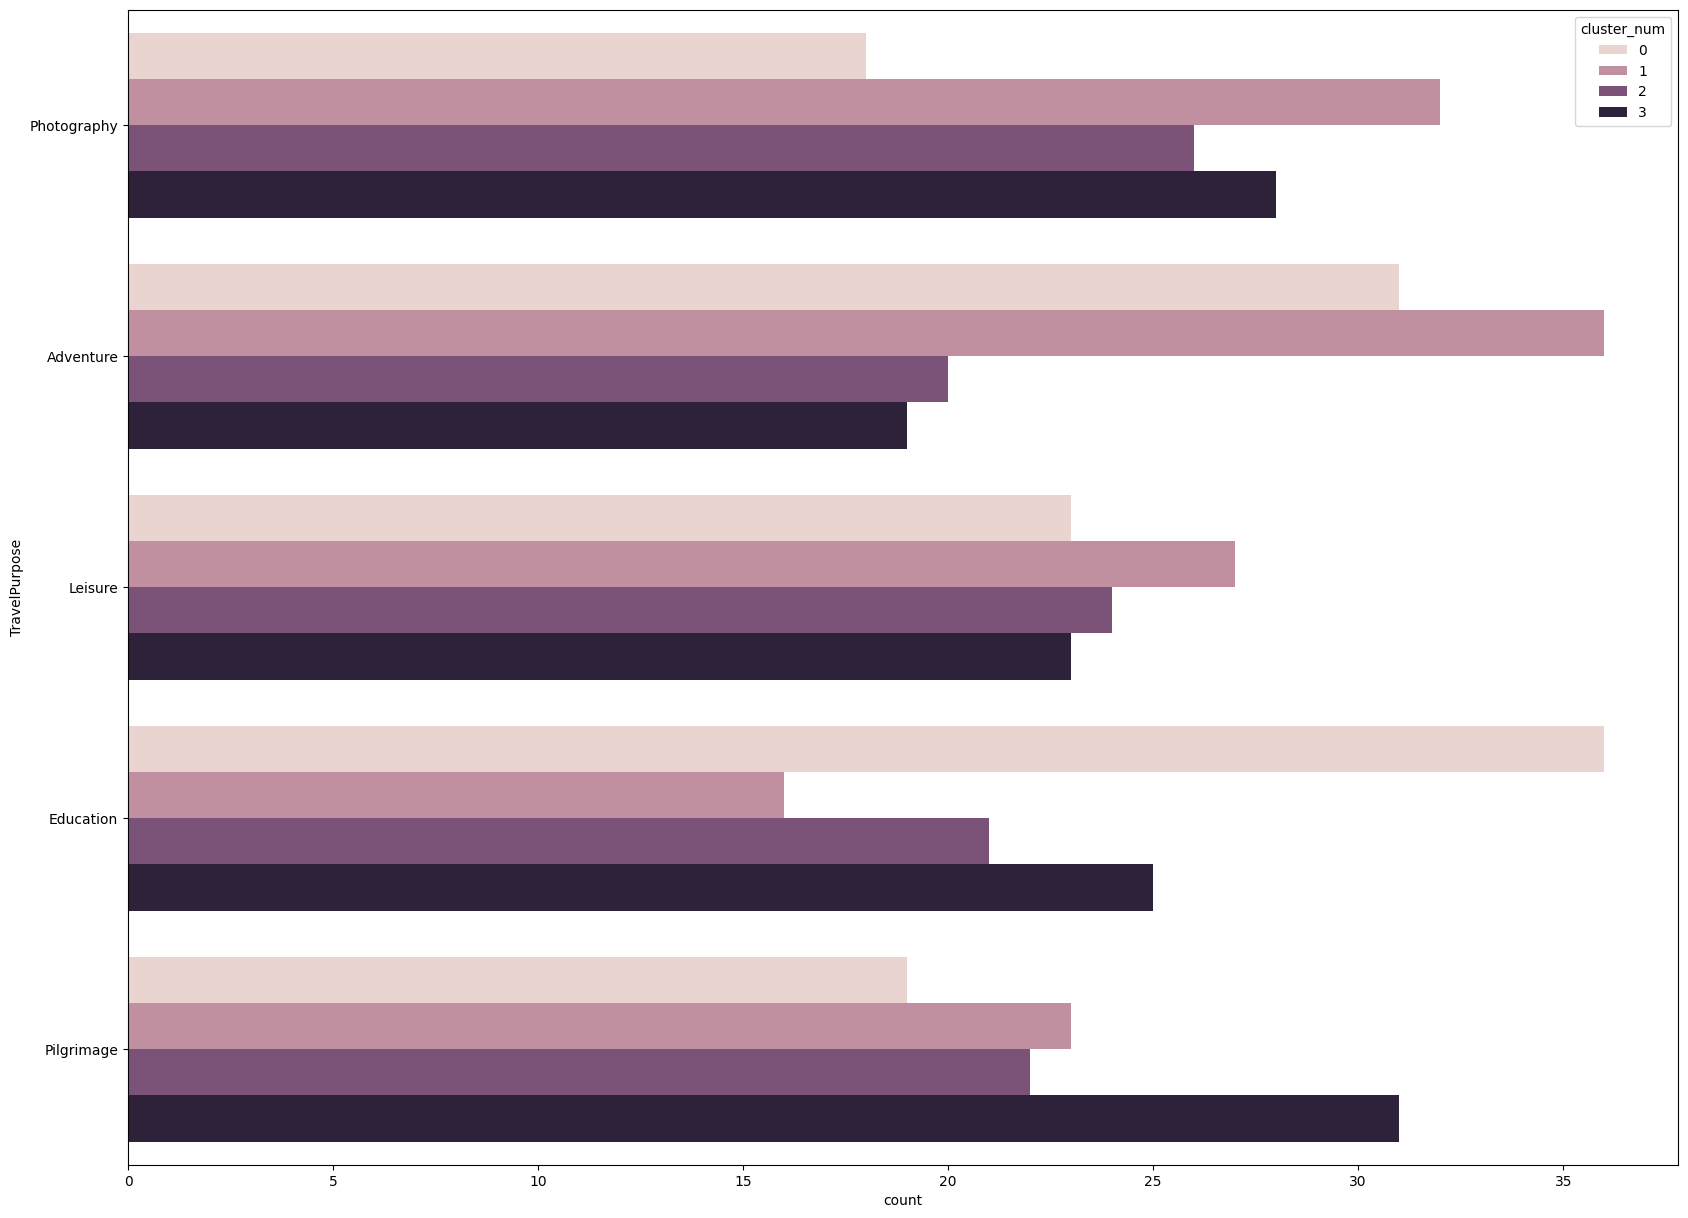

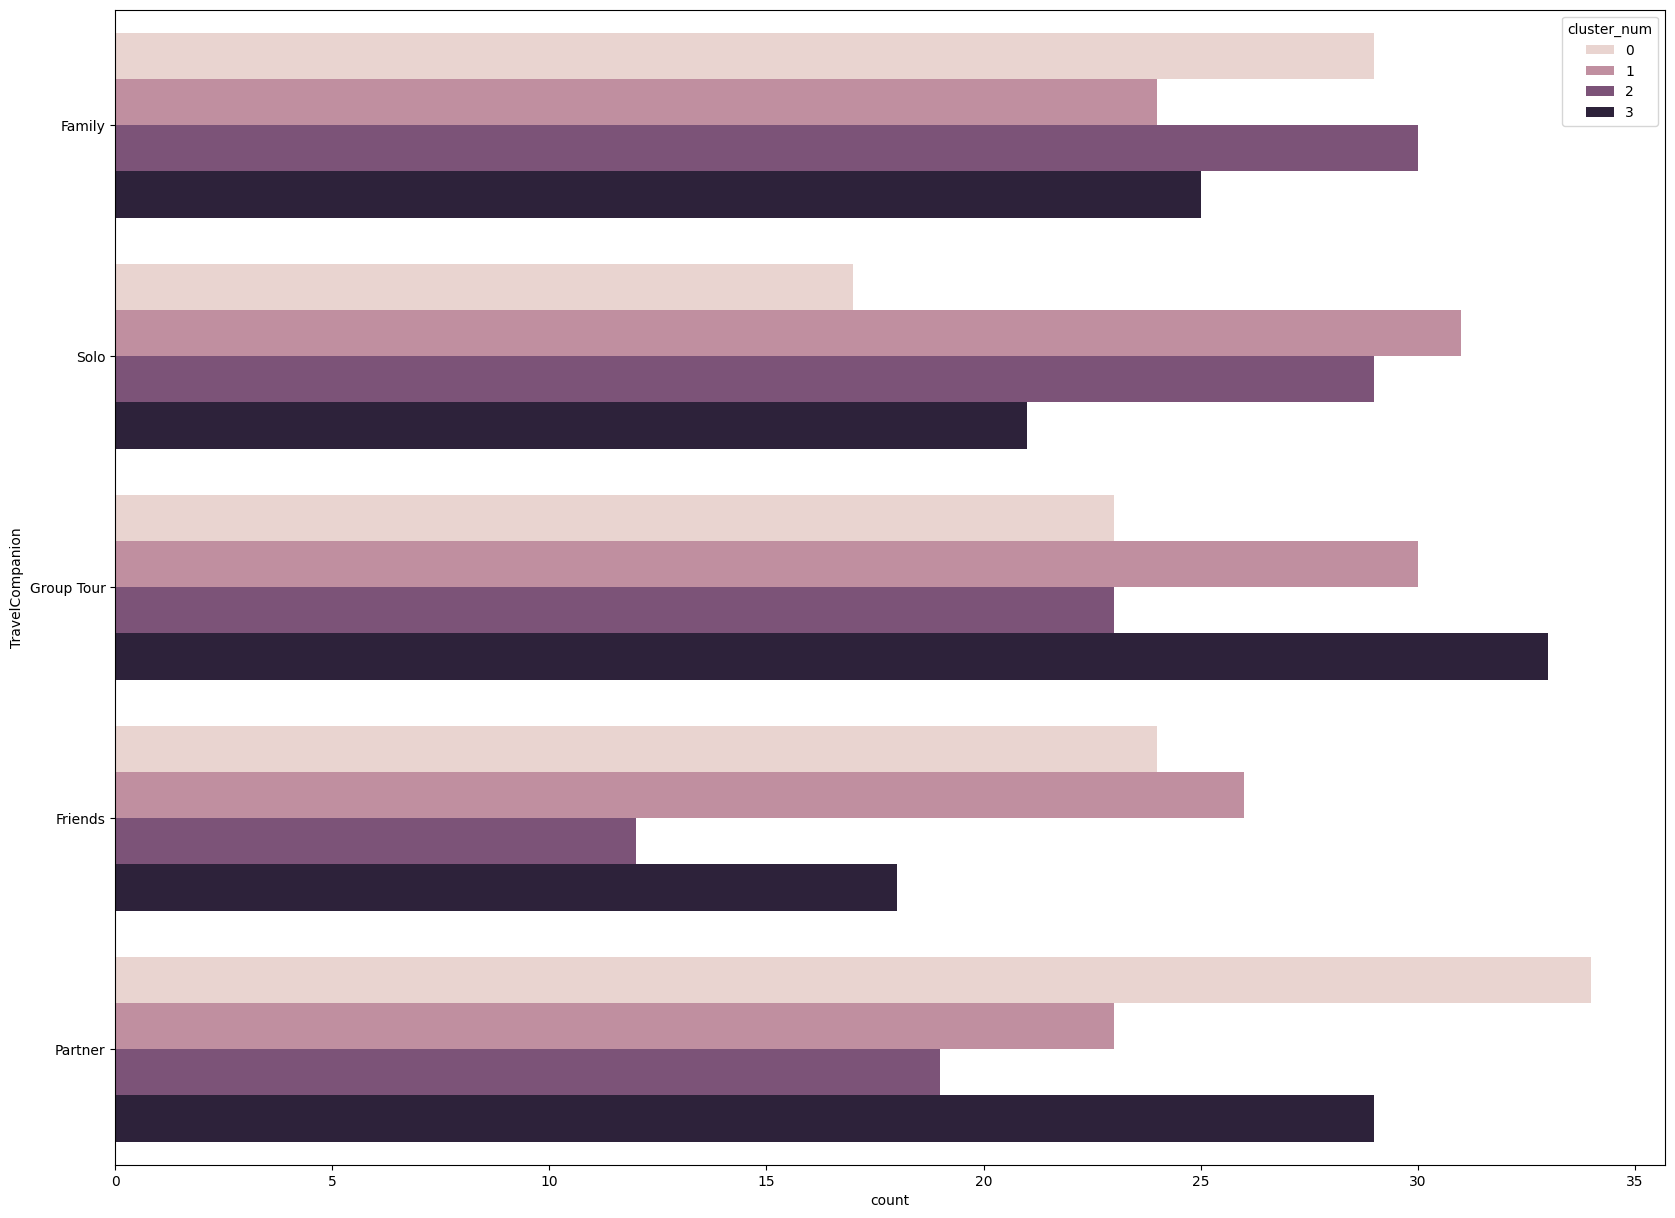

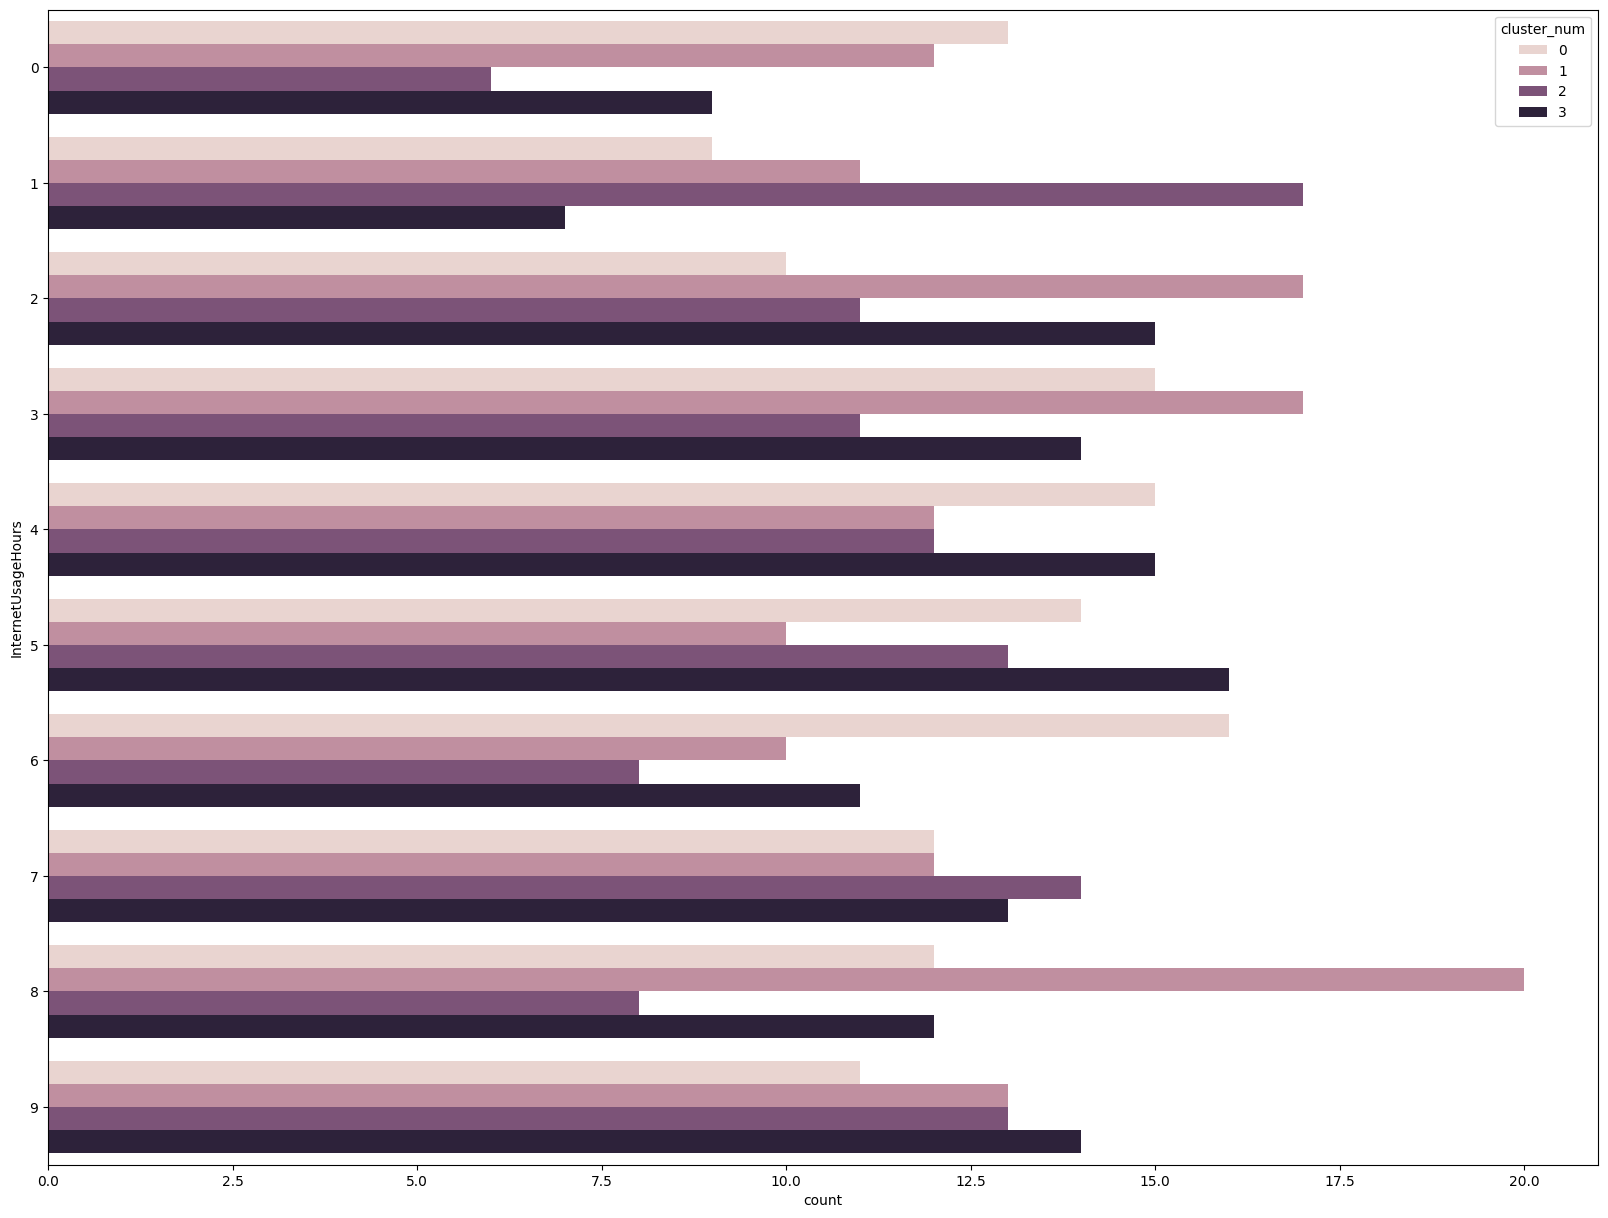

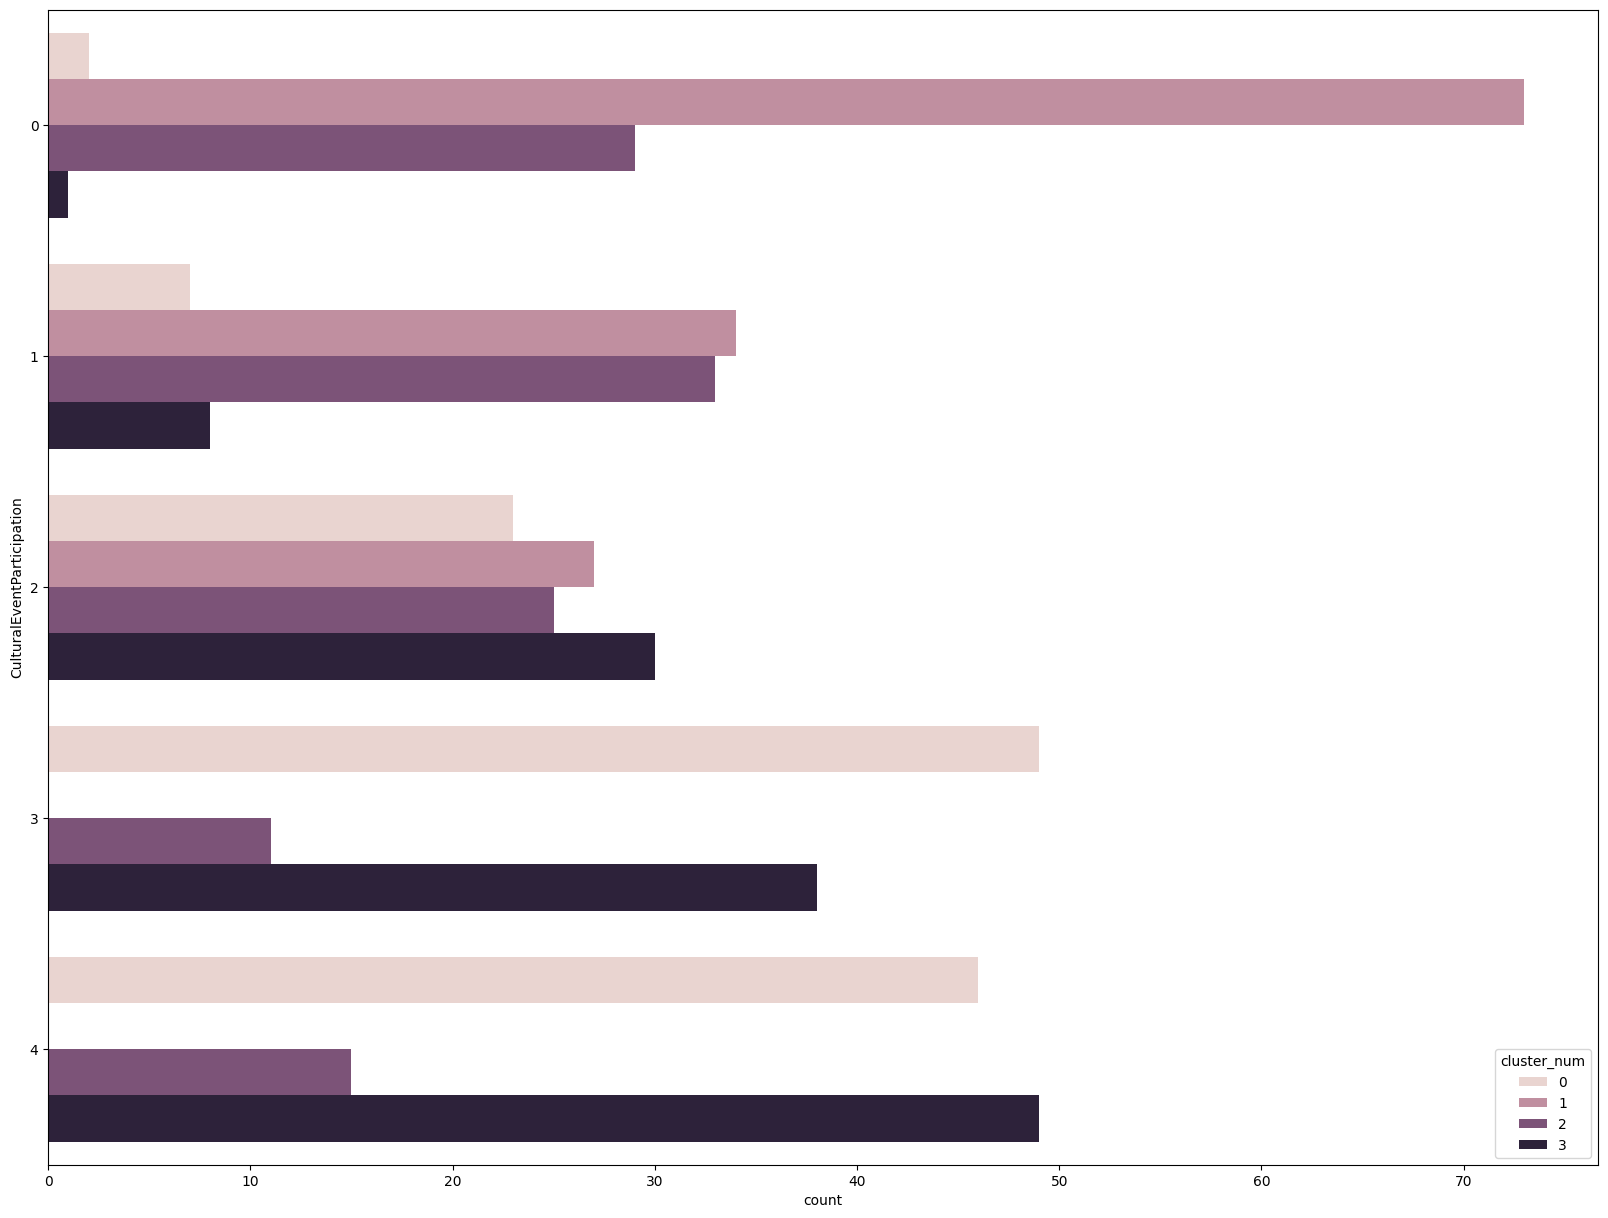

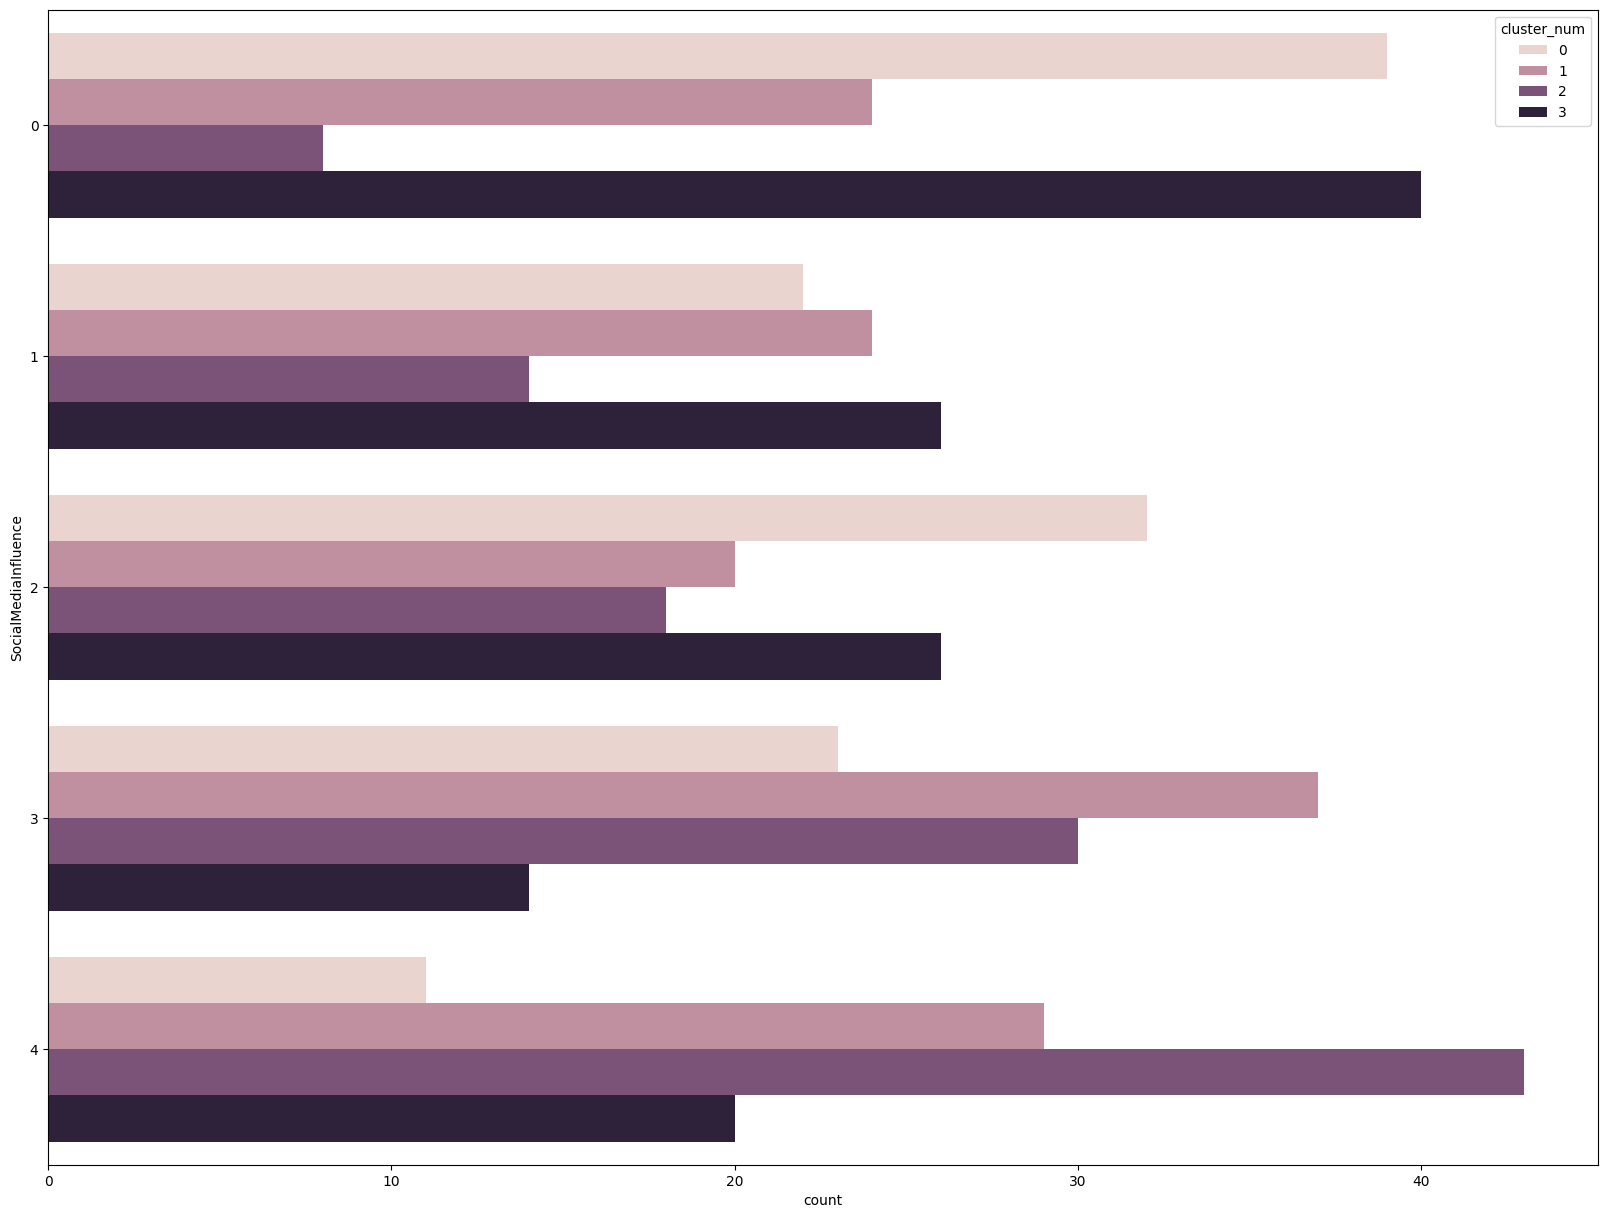

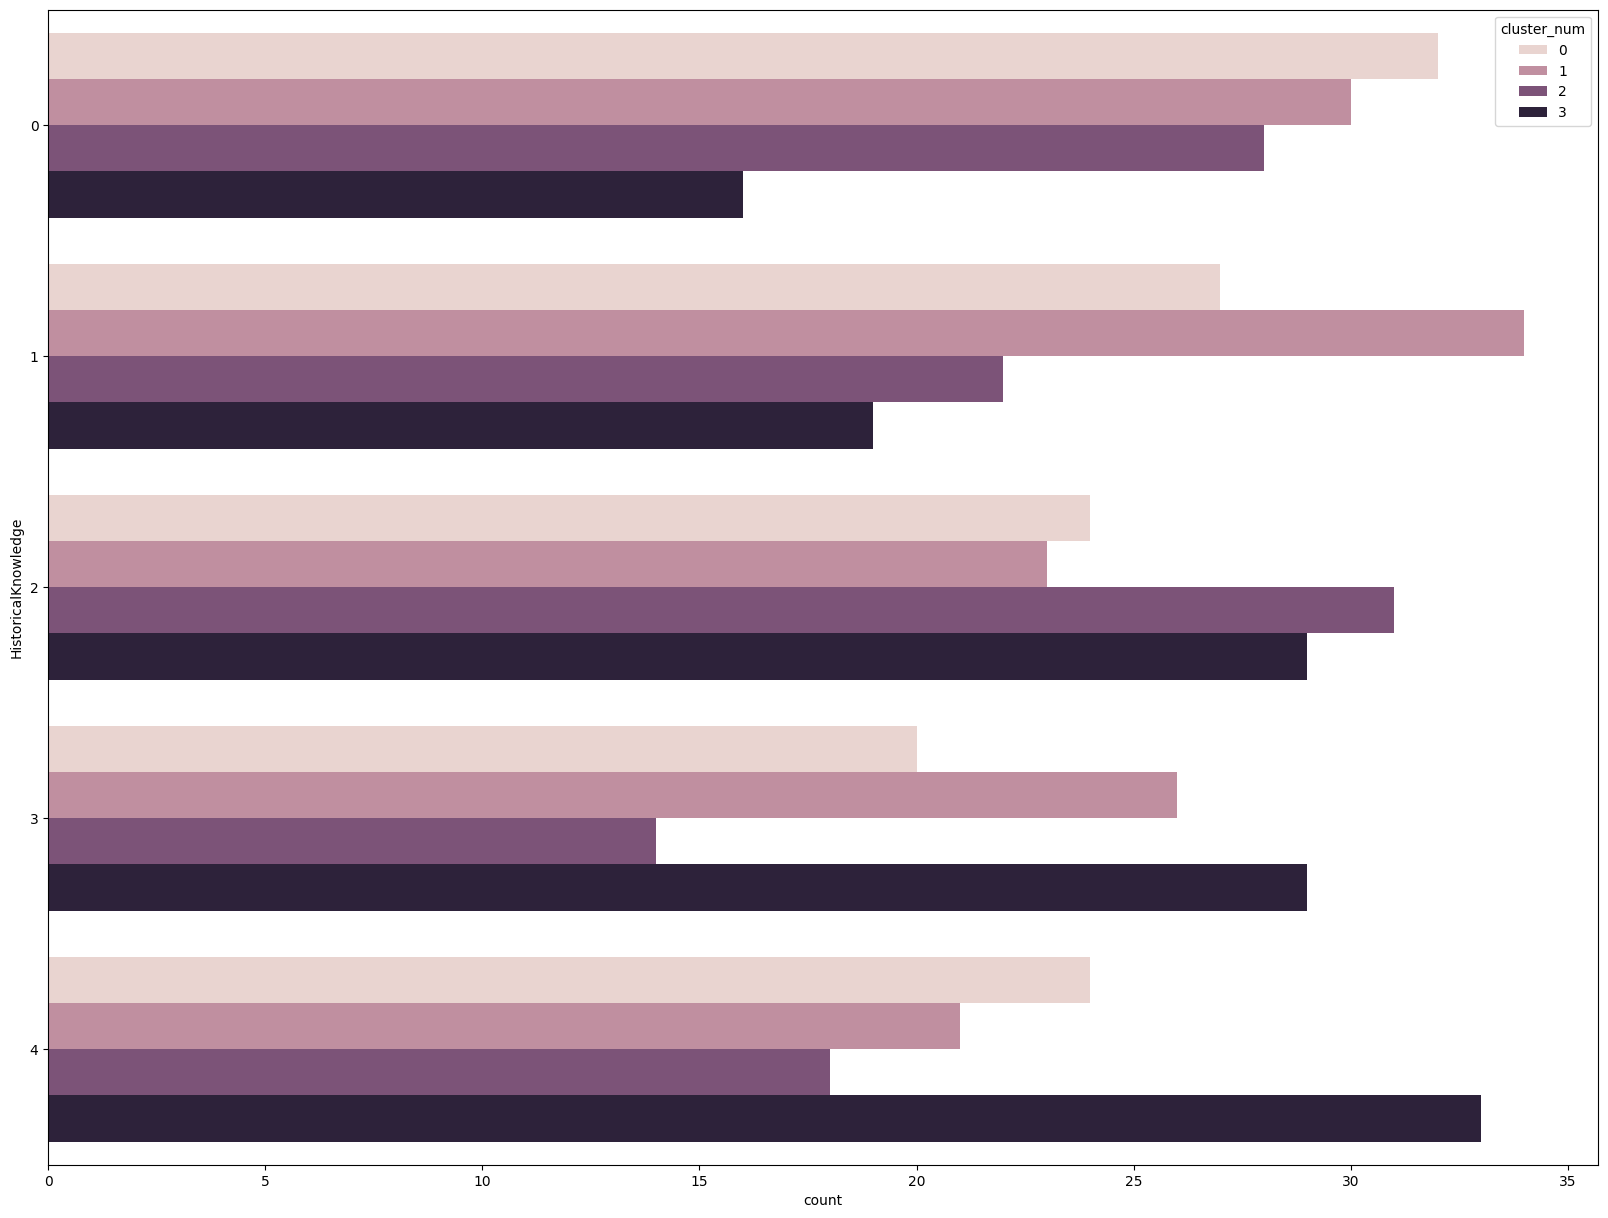

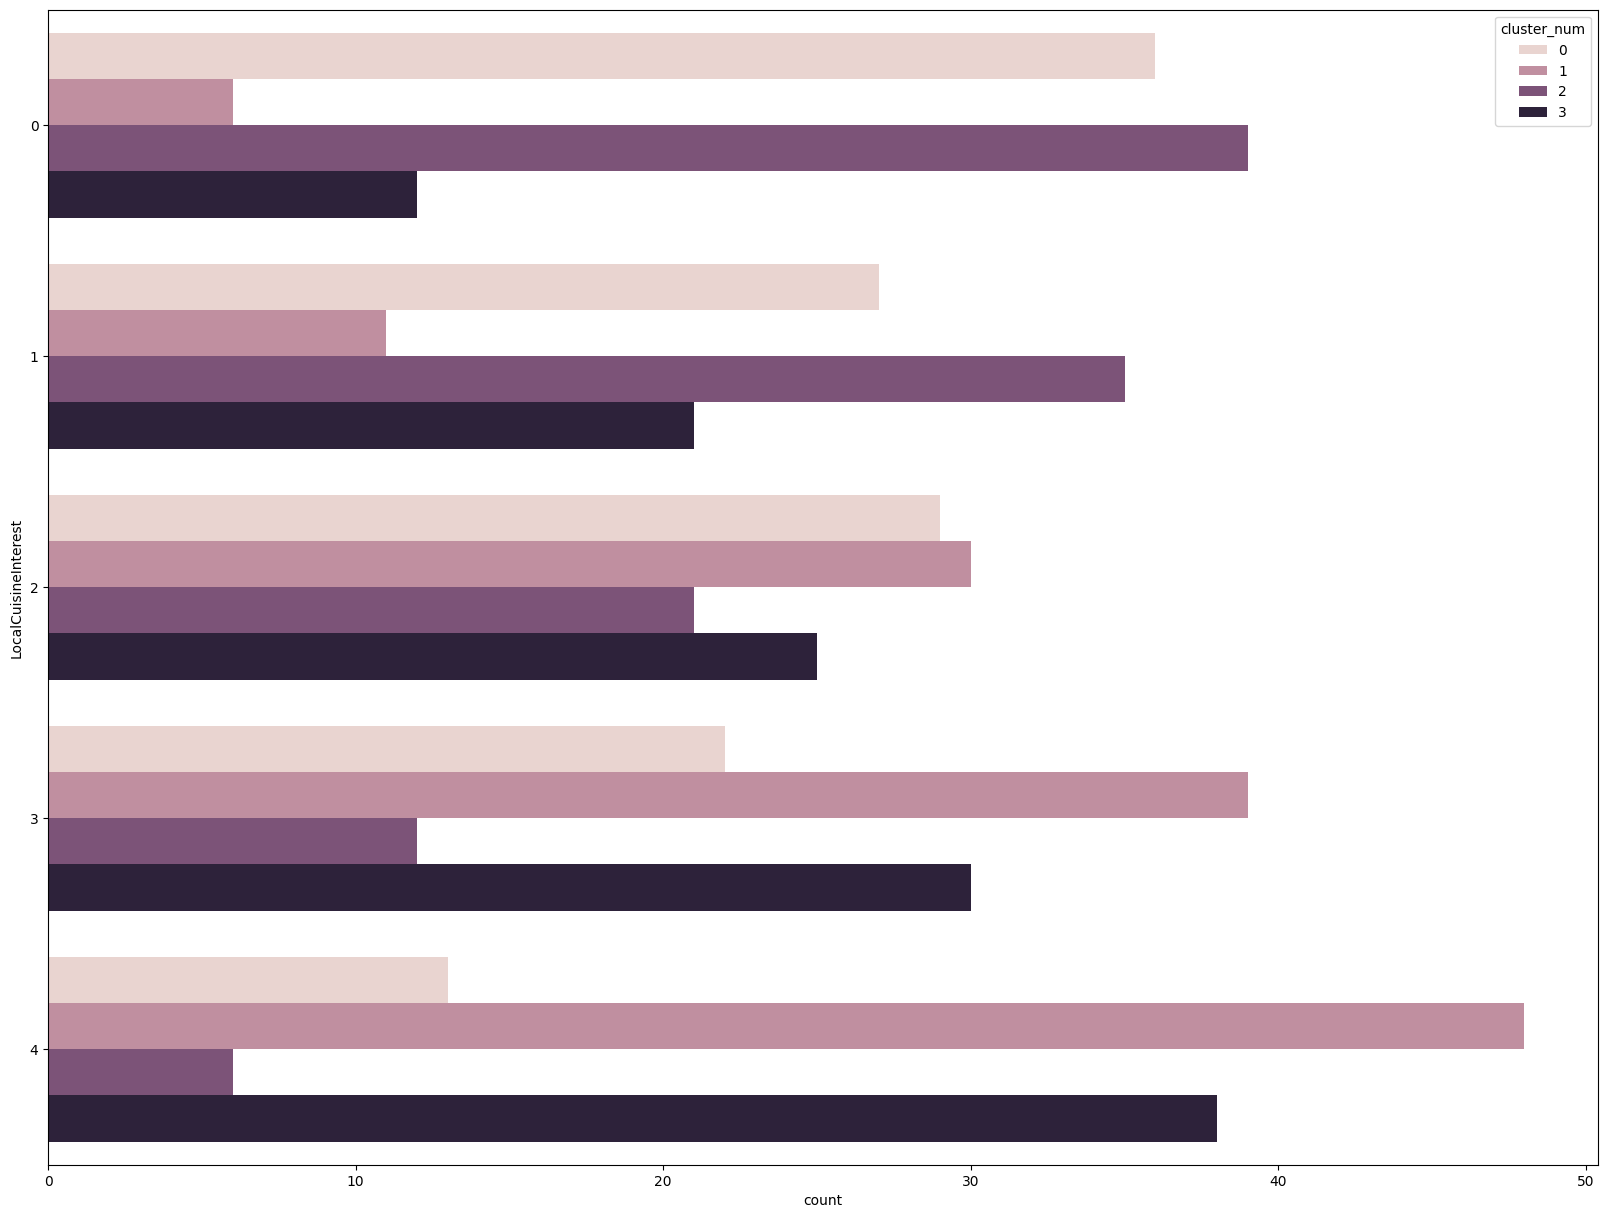

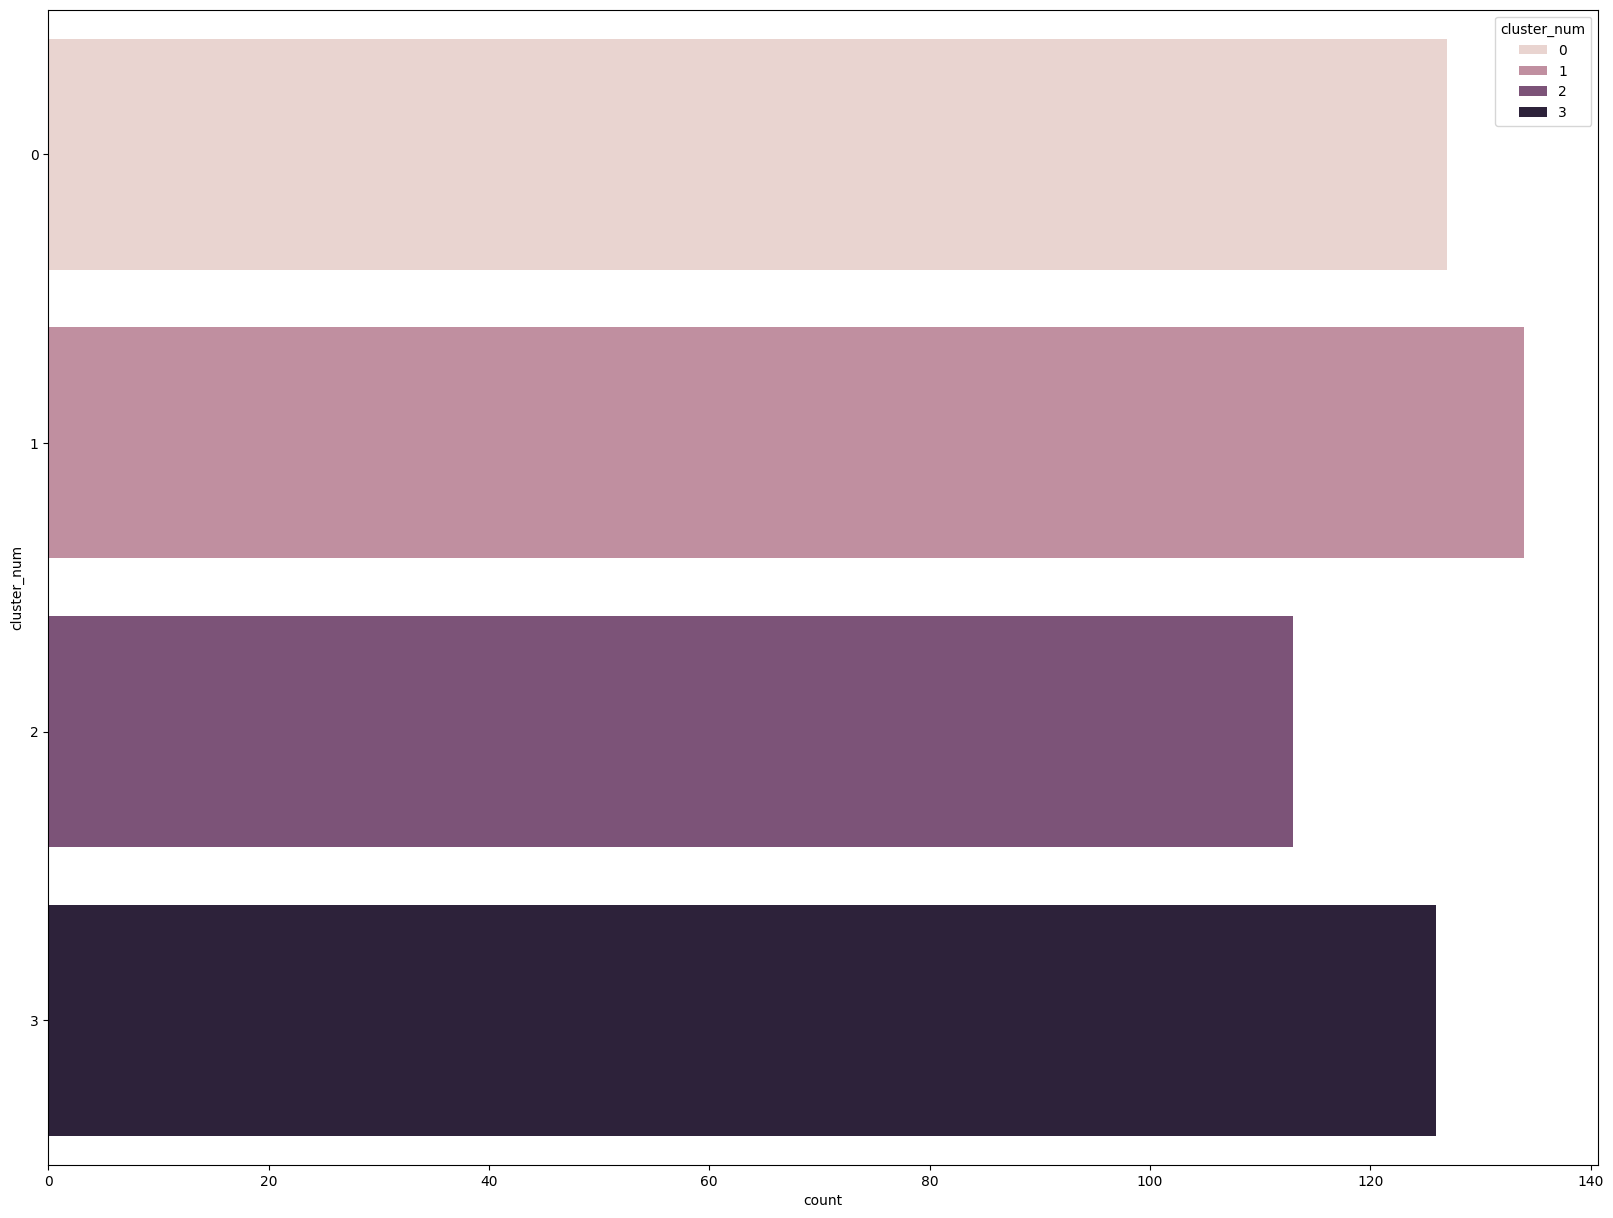

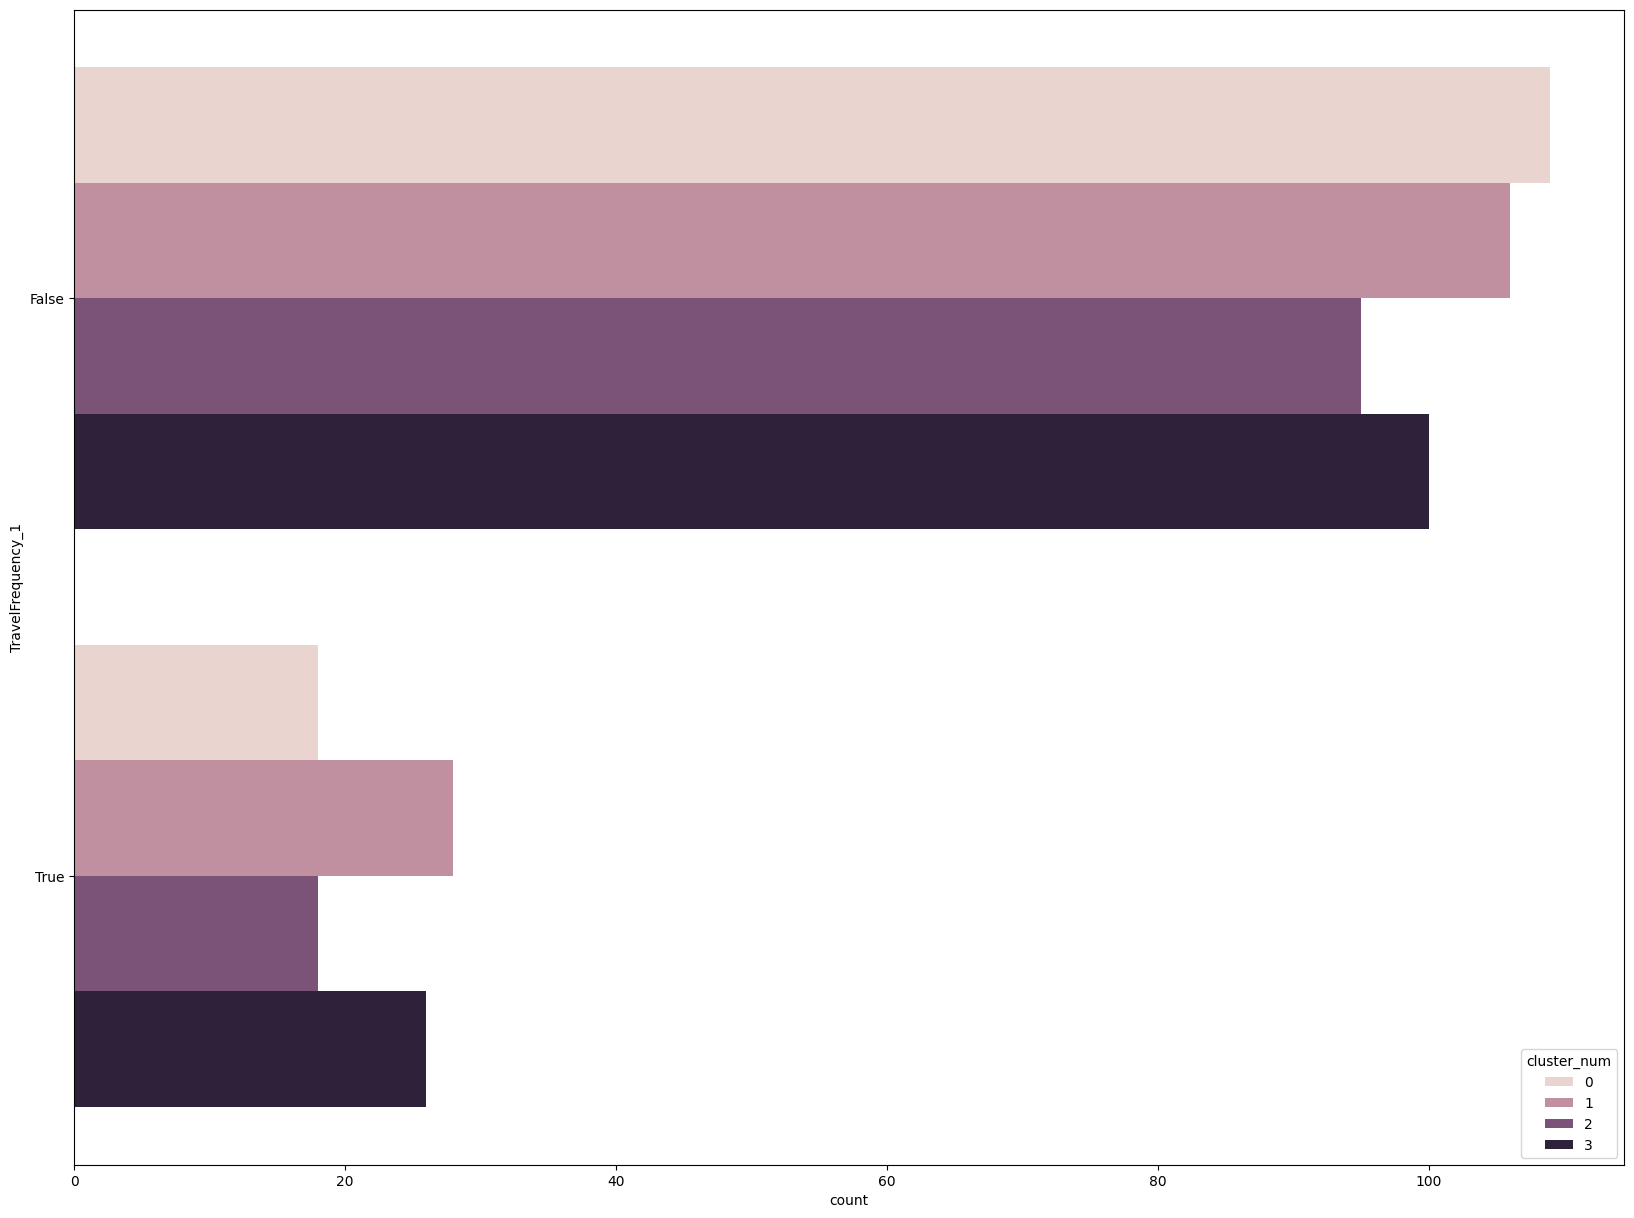

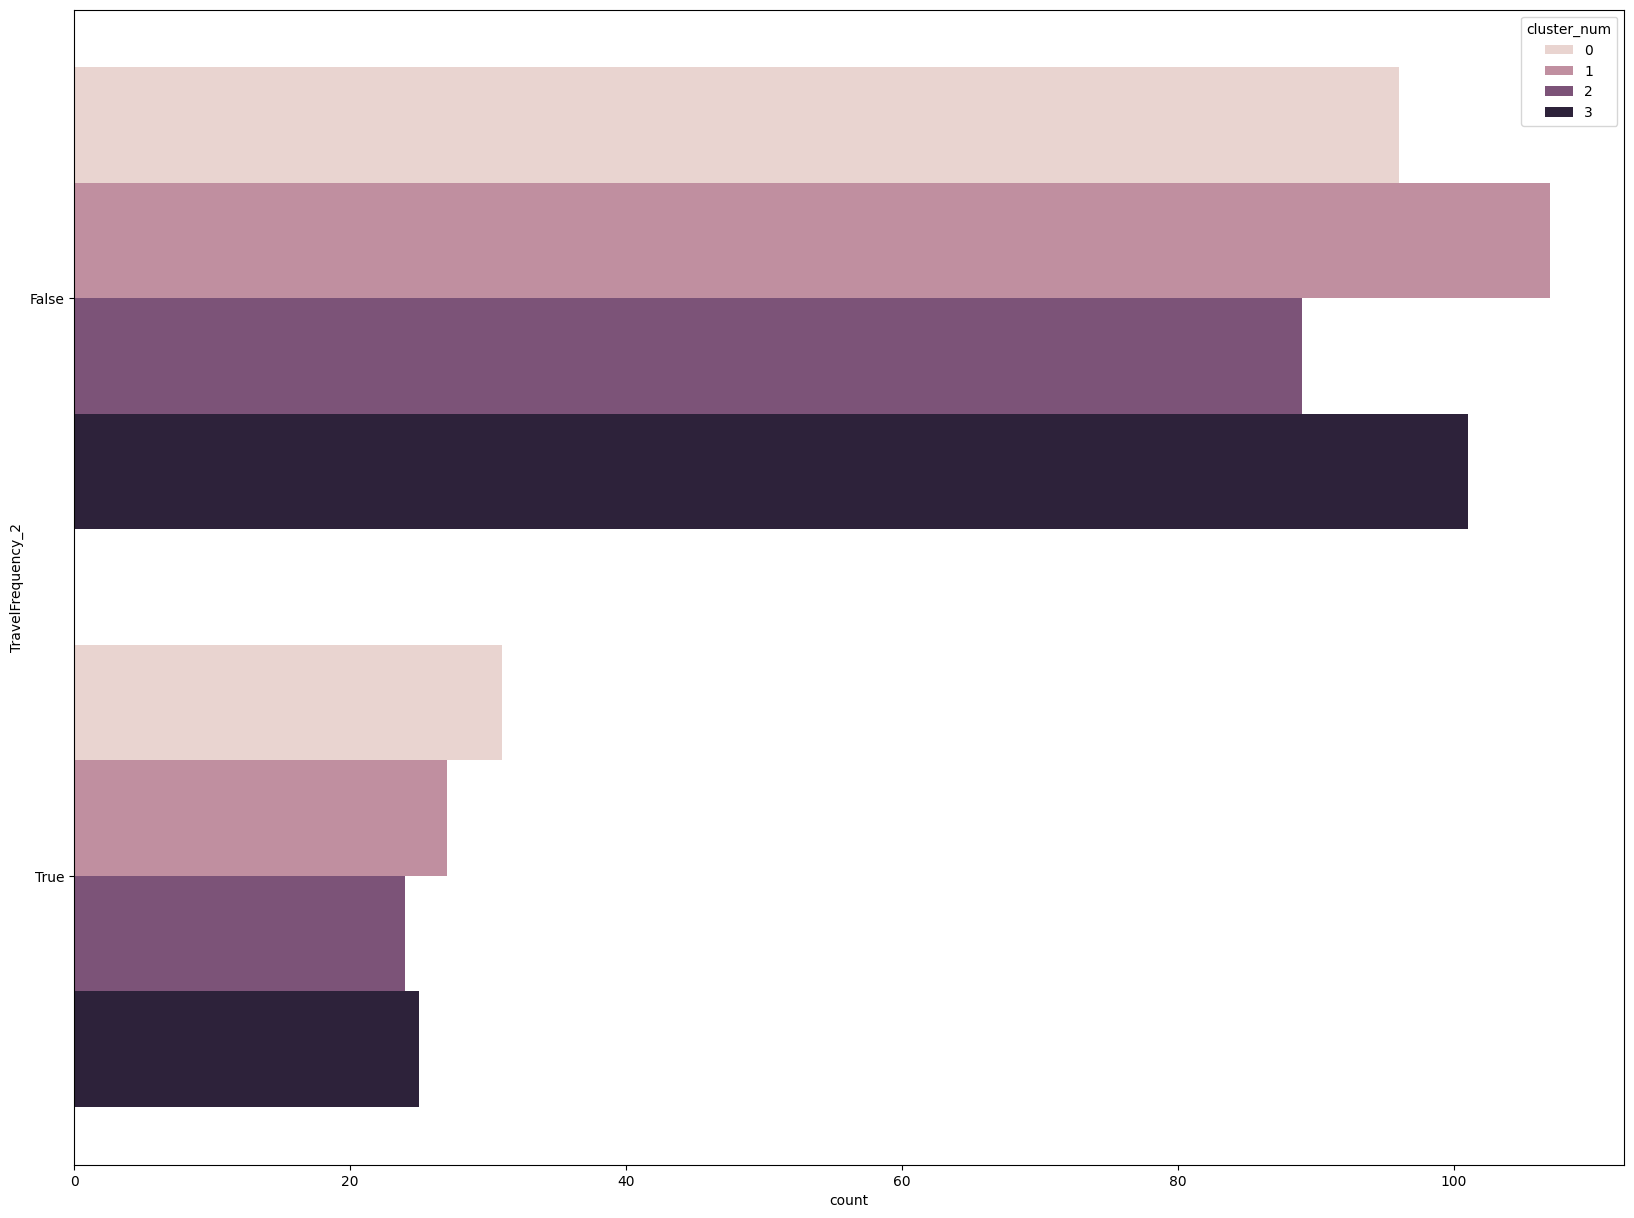

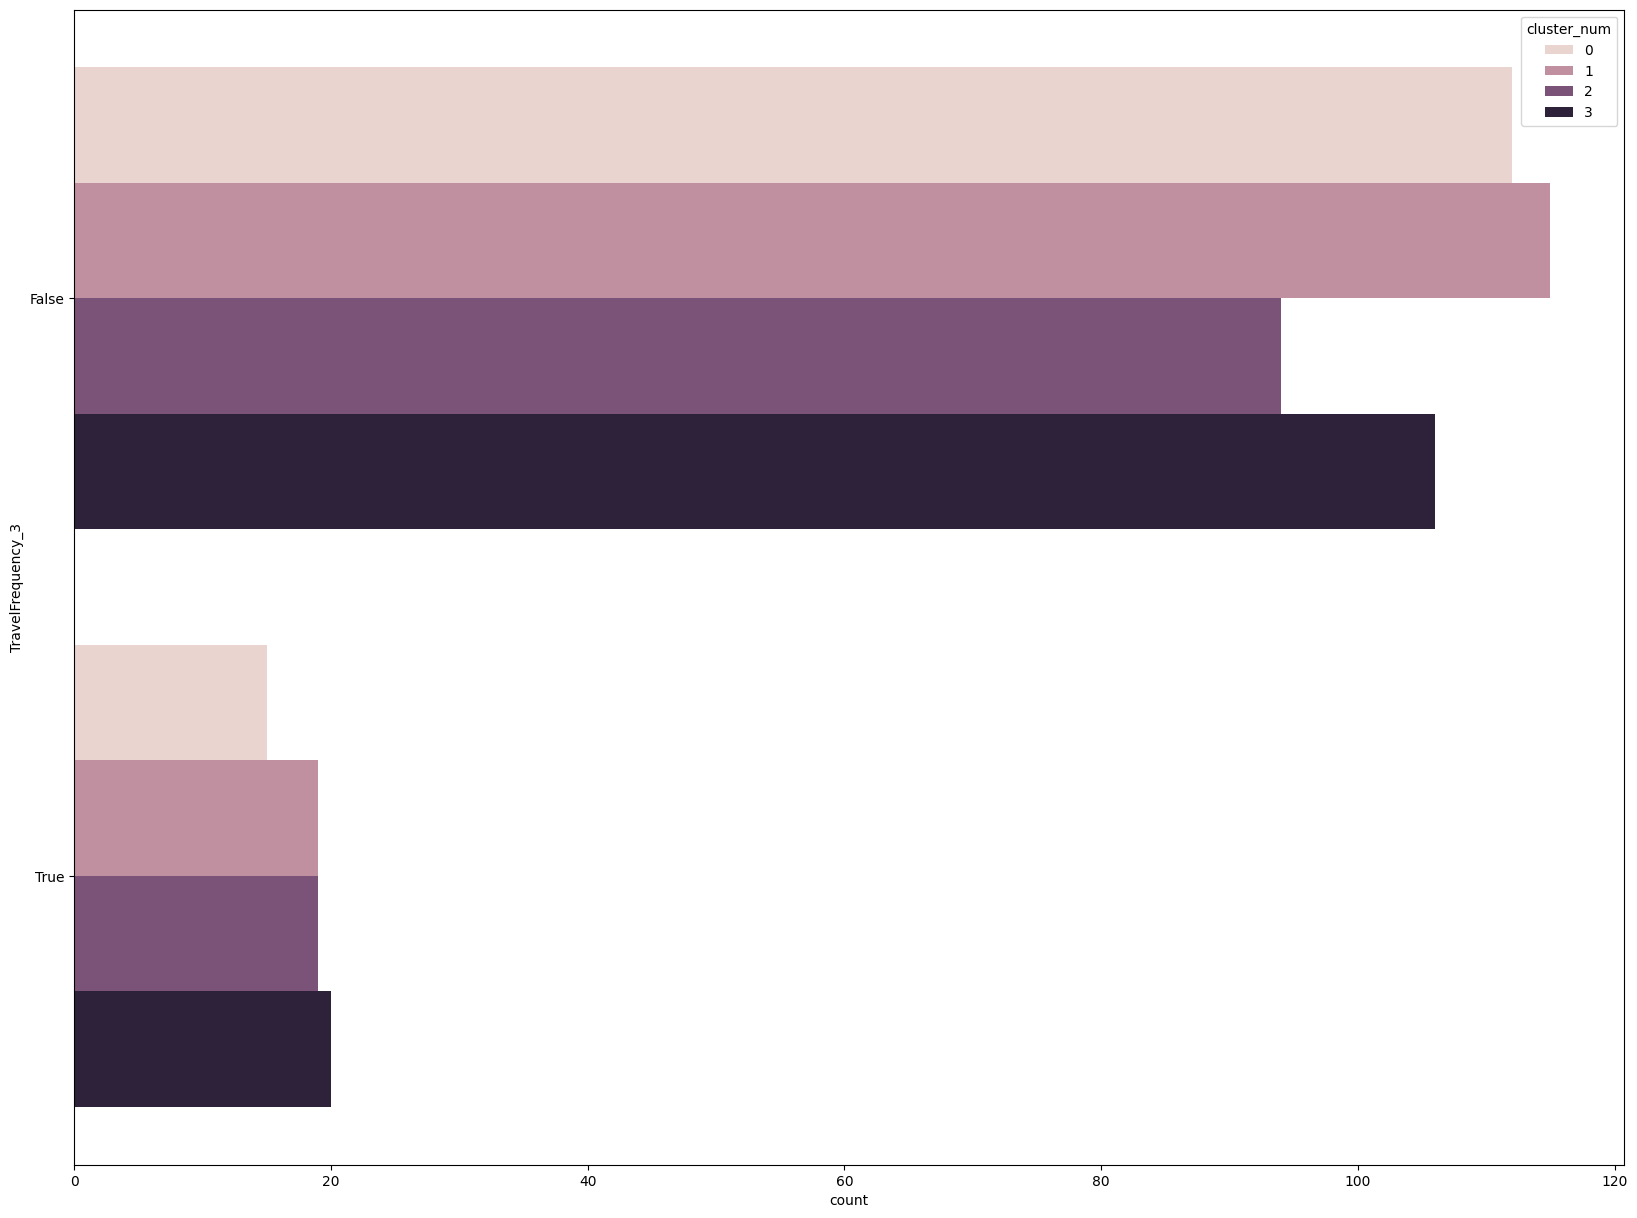

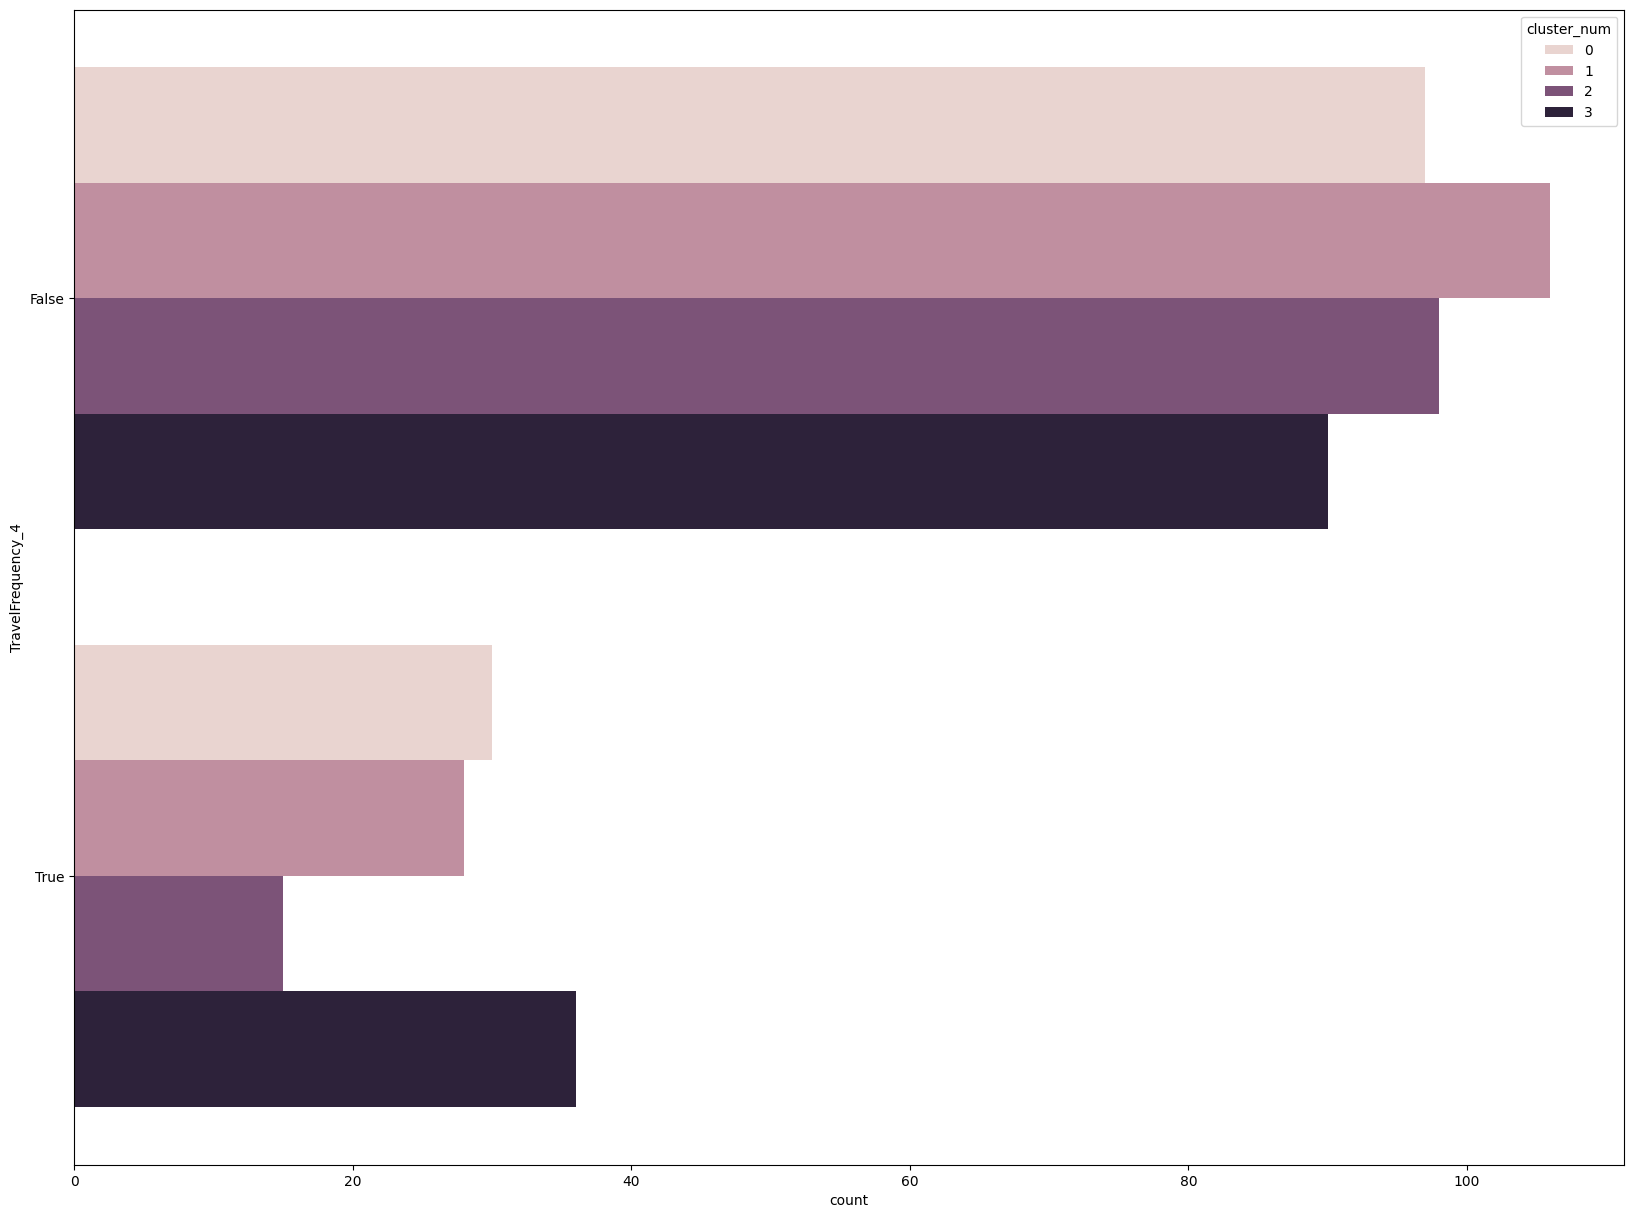

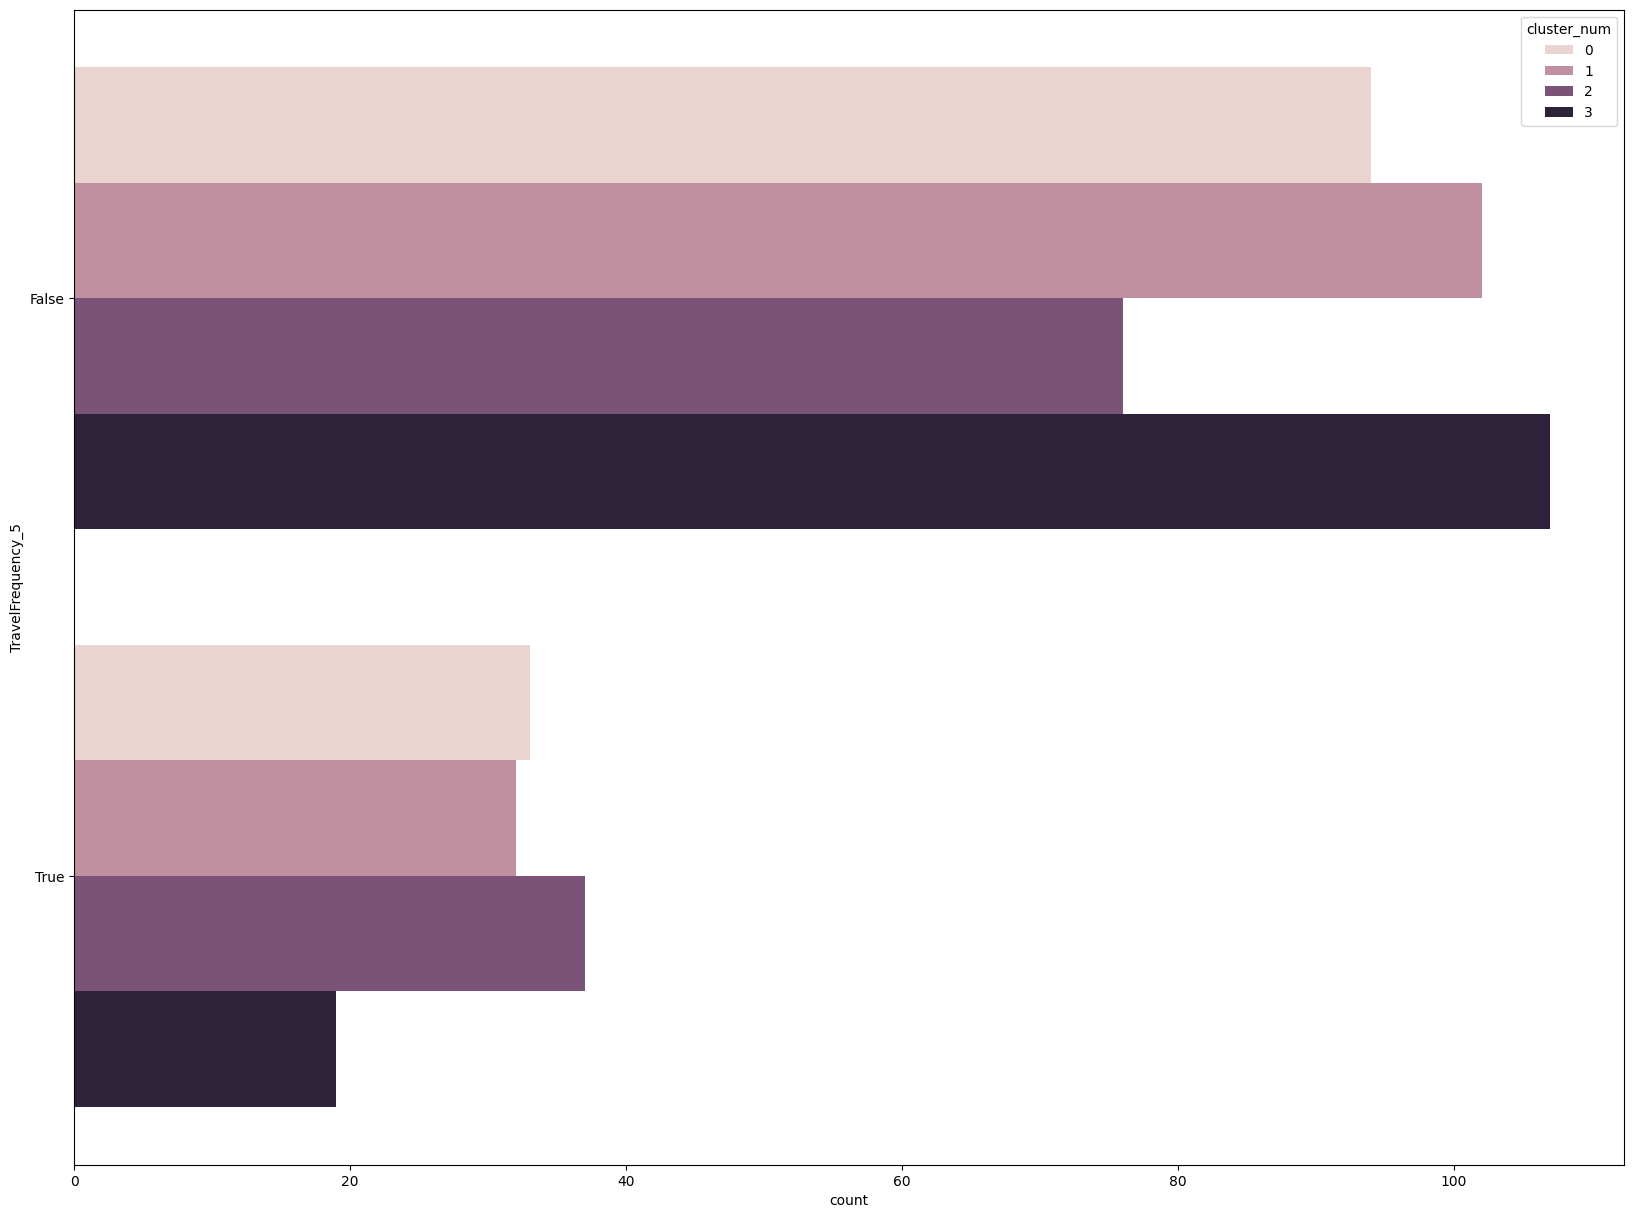

In [62]:
plt.figure(figsize = (9,4))

for i in data1.columns:
    sns.countplot(y = data1[i], hue = data1['cluster_num'], data = data1)
    plt.show()

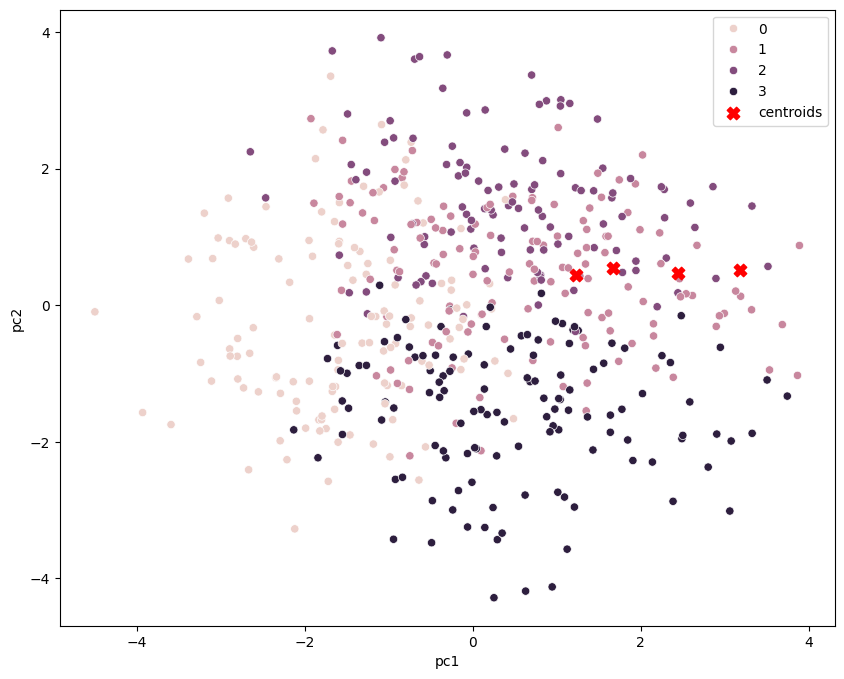

In [63]:
plt.figure(figsize=(10,8))

sns.scatterplot(data = pf, x = "pc1", y = "pc2", hue = kmeans.labels_)

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            marker = "X", c = "r", s = 80, label = "centroids")

plt.legend()
plt.show()

In [72]:
#Describing Segments
crosstab = pd.crosstab(data['cluster_num'], data['CulturalInterest'])


In [74]:
# Reordering cols
# Ensure the column names exist in the DataFrame
crosstab = crosstab[[0, 1, 2, 3, 4]]  # Adjusted to match existing columns
crosstab


CulturalInterest,0,1,2,3,4
cluster_num,,,,,
0,17,20,20,30,40
1,37,28,26,28,15
2,2,9,14,30,58
3,49,30,25,13,9


<Figure size 500x500 with 0 Axes>

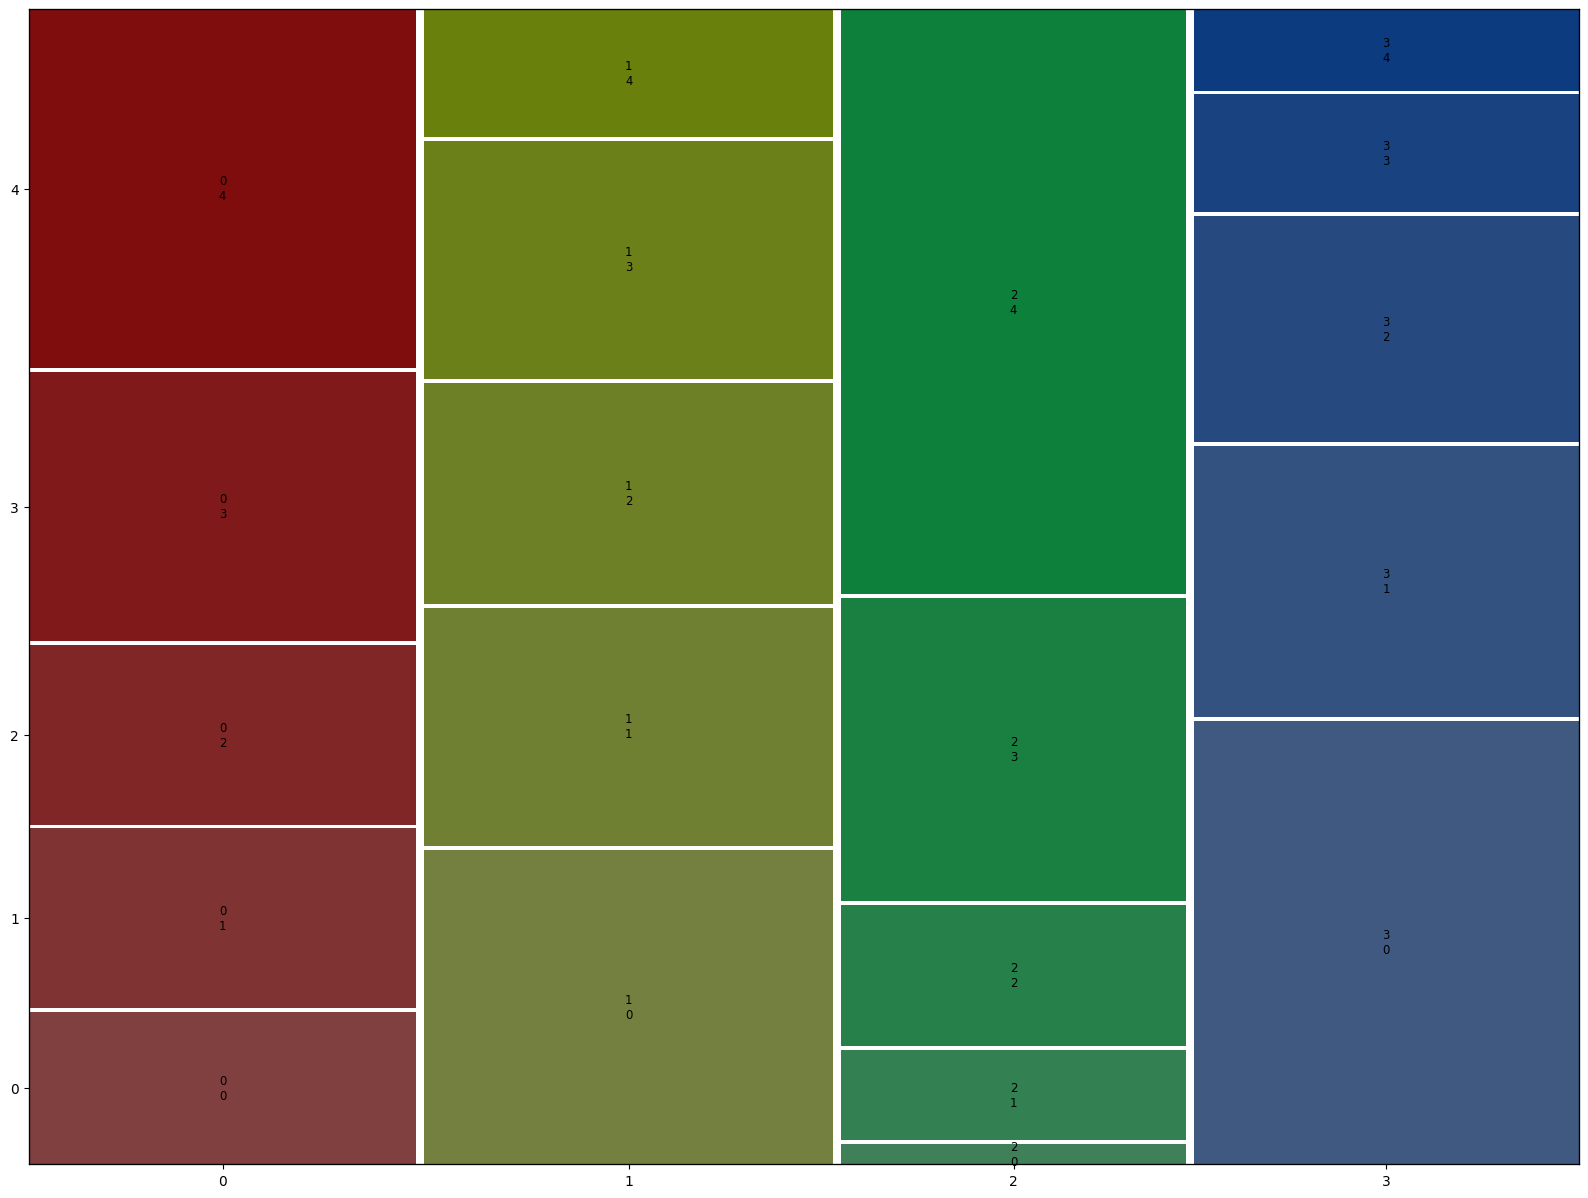

In [75]:
plt.figure(figsize=(5,5))
mosaic(crosstab.stack())
plt.show()

In [76]:
crosstab = pd.crosstab(data['cluster_num'], data['GroupType'])
crosstab


GroupType,1,2,3,4
cluster_num,,,,
0,23,37,28,39
1,35,48,33,18
2,32,17,34,30
3,31,36,33,26


<Figure size 500x500 with 0 Axes>

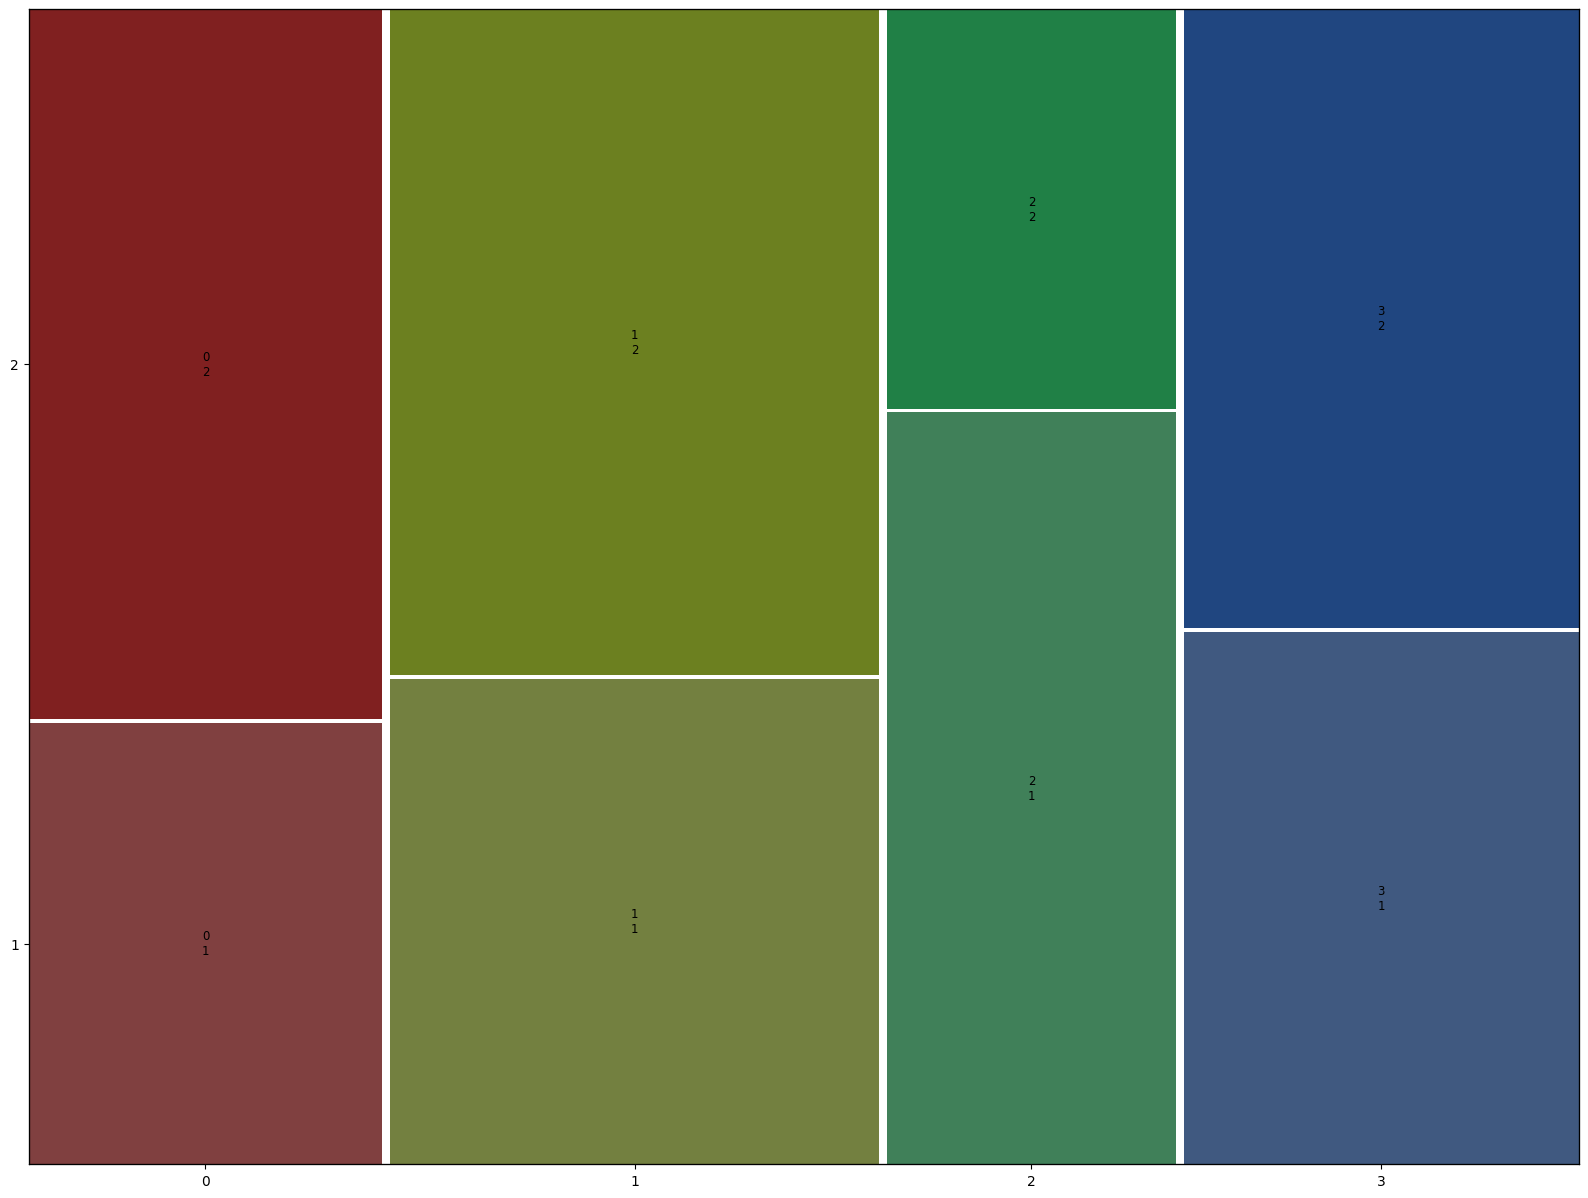

In [80]:
#Reordering cols

plt.figure(figsize=(5, 5))
crosstab = crosstab[[1, 2]]  
mosaic(crosstab.stack())
plt.show()

<Axes: xlabel='cluster_num', ylabel='Age'>

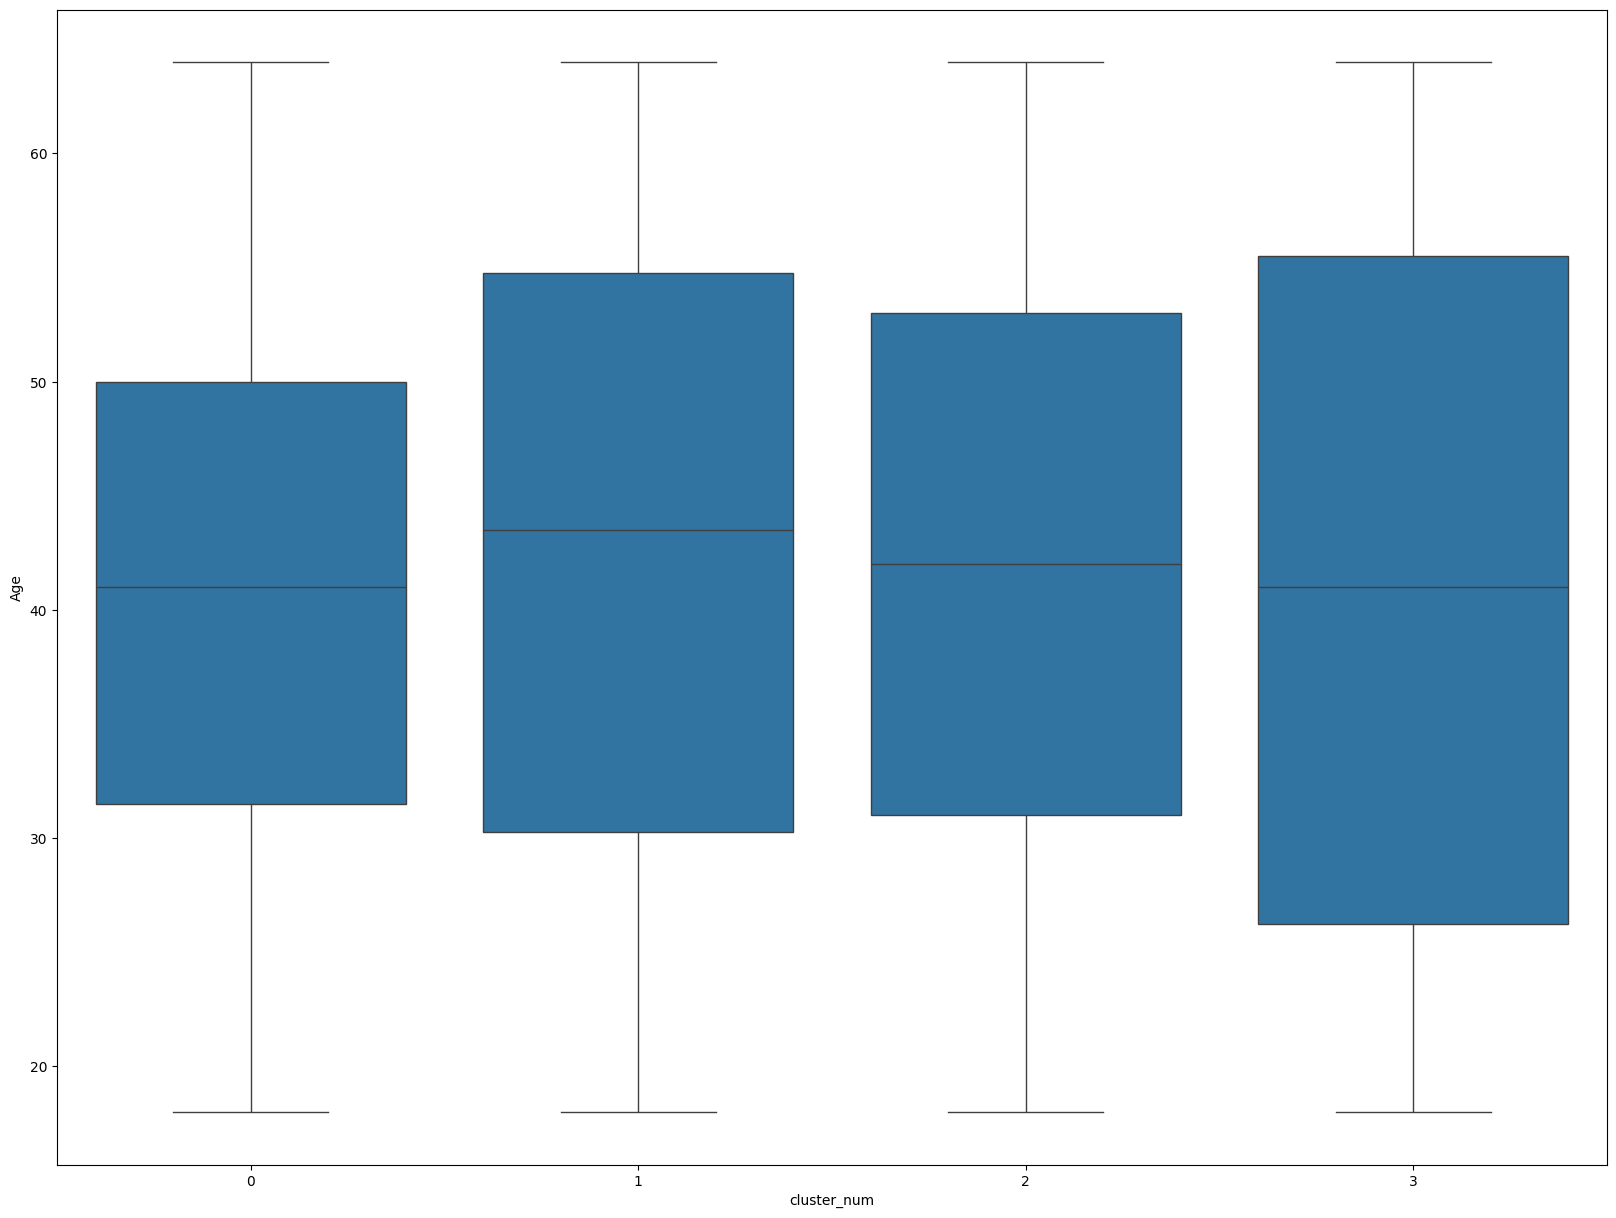

In [81]:
sns.boxplot(x = 'cluster_num', y = 'Age', data = data1)

In [82]:
data

,Age,Budget,TravelFrequency,CulturalInterest,PrefersLocal,TechSavvy,GroupType,SeeksSpirituality,EcoFriendly,Region,...,LanguageProficiency,PreferredDestinations,TravelPurpose,TravelCompanion,InternetUsageHours,CulturalEventParticipation,SocialMediaInfluence,HistoricalKnowledge,LocalCuisineInterest,cluster_num
0,56,49417,4,4,0,0,1,1,1,North-East,...,4,Temples,Photography,Family,3,4,1,2,4,3
1,46,28938,2,4,1,1,1,1,0,East India,...,4,Nature Reserves,Adventure,Solo,3,0,0,4,4,1
2,32,28664,3,4,0,4,2,1,0,North-East,...,0,Festivals,Leisure,Family,8,2,4,2,4,1
3,60,6636,4,2,0,2,4,1,1,South India,...,2,Monuments,Adventure,Group Tour,8,3,3,2,2,3
4,25,25080,5,4,0,3,4,1,0,North India,...,1,Temples,Education,Solo,8,0,0,3,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,7869,1,0,0,4,1,0,1,South India,...,4,Nature Reserves,Photography,Solo,2,1,0,3,1,3
496,26,33643,2,1,0,4,4,0,1,West India,...,1,Museums,Adventure,Family,9,4,2,3,3,0
497,41,29736,3,1,1,4,2,0,0,South India,...,1,Monuments,Education,Family,2,1,4,0,0,2
498,18,43467,4,1,1,3,2,0,0,North-East,...,2,Festivals,Pilgrimage,Friends,8,1,0,3,3,1


In [86]:
#Selecting the Target Segment
# calculating the mean of 'VisitFrequency'
data['TravelFrequency'] = LabelEncoder().fit_transform(data['TravelFrequency'])
visit = data.groupby('cluster_num')['TravelFrequency'].mean()
visit = visit.to_frame().reset_index()
visit

,cluster_num,TravelFrequency
0,0,2.228346
1,1,2.067164
2,2,2.256637
3,3,1.976190


In [87]:
# Calculating the mean of 'CulturalInterest'
CulturalInterest = data.groupby('cluster_num')['CulturalInterest'].mean()
CulturalInterest = CulturalInterest.to_frame().reset_index()
CulturalInterest


,cluster_num,CulturalInterest
0,0,2.440945
1,1,1.671642
2,2,3.176991
3,3,1.230159


In [90]:
# calculating the mean of 'Gender'

data['Region'] = LabelEncoder().fit_transform(data['Region'])
Region = data.groupby('cluster_num')['Region'].mean()
Region = Region.to_frame().reset_index()
Region

,cluster_num,Region
0,0,1.944882
1,1,2.104478
2,2,2.017699
3,3,2.253968


In [92]:
segment = Gender.merge(CulturalInterest, on='cluster_num', how='left').merge(visit, on='cluster_num', how='left')
segment

,cluster_num,LocalCuisineInterest,CulturalInterest,TravelFrequency
0,0,1.598425,2.440945,2.228346
1,1,2.835821,1.671642,2.067164
2,2,1.212389,3.176991,2.256637
3,3,2.484127,1.230159,1.976190


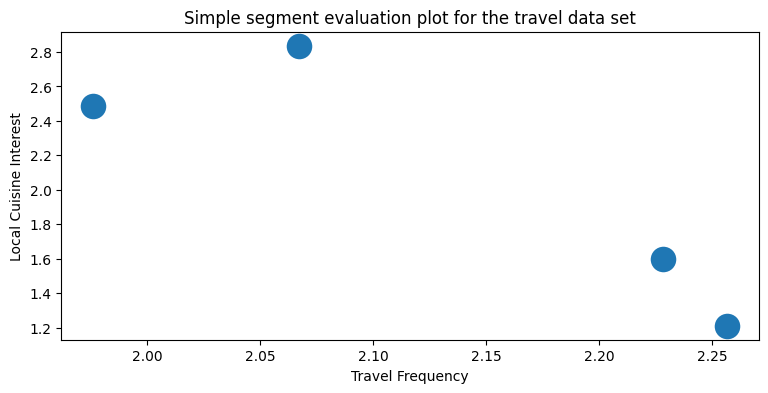

In [94]:
# targeting segments

plt.figure(figsize = (9,4))
sns.scatterplot(x = "TravelFrequency", y = "LocalCuisineInterest", data = segment, s=400)
plt.title("Simple segment evaluation plot for the travel data set") 
plt.xlabel("Travel Frequency") 
plt.ylabel("Local Cuisine Interest") 
plt.show()
